## Rearrangement Paper - Plotting

In [105]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, NullFormatter
import pytweezer.data_manager as DataManager
import pytweezer.analysis as an
import pytweezer.phasemask as pm
from scipy.optimize import curve_fit
import time

In [247]:
# ==============================================================================
# 1. GLOBAL PUBLICATION STYLE SETTINGS (rcParams) - SERIF VERSION
# ==============================================================================
plt.rcParams.update({
    "text.usetex": False,              # Set to True if you have a full LaTeX distribution installed
    "font.family": "serif",            # Changed to serif
    "font.serif": ["Times New Roman", "DejaVu Serif"], # Primary and fallback serif fonts
    "mathtext.fontset": "cm",          # Renders math symbols in LaTeX's Computer Modern font
    "font.size": 9,                    
    "axes.linewidth": 1.0,             
    "axes.labelsize": 10,
    "xtick.direction": "in",           
    "ytick.direction": "in",
    "xtick.major.size": 2,             
    "ytick.major.size": 2,
    "xtick.minor.size": 1,             
    "ytick.minor.size": 1,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.top": False,                 
    "ytick.right": False,
    "legend.frameon": False,           
    "legend.fontsize": 9,
    "figure.figsize": (3.37*1.5, 2.8*1.5),     # Standard APS single column
    "figure.dpi": 300,
    "savefig.bbox": "tight"            
})

---
## Phase Flicker

In [248]:
date = "13Aug26"
DataManager.list_datasets(date);
dataset = DataManager.load_dataset(date, "rearrangement_phase_flicker")

Datasets found in C:\Users\tweez\Box\Working folder\caftweezers\Data\2026\Aug\13Aug26:
  - rearrangement_phase_flicker/
Loading dataset: rearrangement_phase_flicker

--- Experimental Info ---

Dataset Title: rearrangement_phase_flicker
Date: 2026-08-13 16:32:42

    Phase flicker analysis during rearrangement from 20x20 to 14x14 array.
    Maximum step size (d0) = 0.5, profile = linear.
    Standard deviation of phase residuals (LPI): 0.0413 rad

----------------------------------------
Contents:
  Files:
    - experiment_info.txt
    - phase_flicker_data.pkl
----------------------------------------


In [249]:
data = dataset.pickles.get("phase_flicker_data.pkl")
data.keys()

dict_keys(['x_on_array', 'y_on_array', 'I_foc_array_lpi', 'phi_foc_array_lpi', 'residuals_array', 'phase_std_derivatives_array'])

Text(0, 0.5, 'Probability')

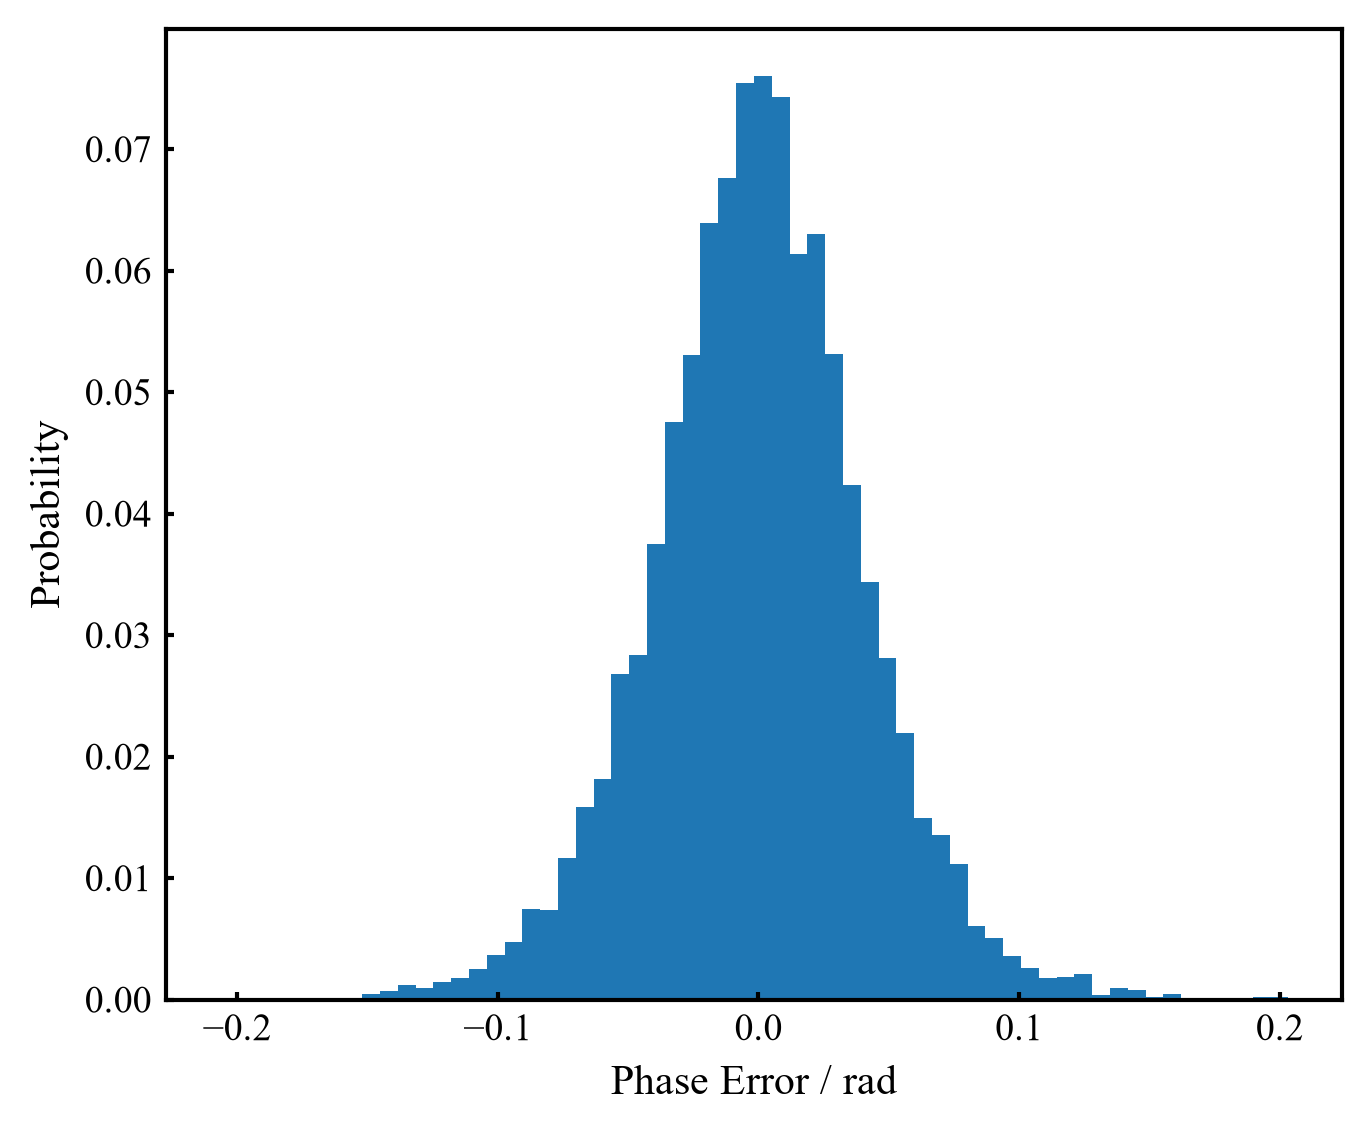

In [250]:
residuals_saved = data['residuals_array']
phi_array = data['phi_foc_array_lpi']

weights = np.ones_like(residuals_saved) / len(residuals_saved)
plt.hist(residuals_saved, density=False, bins=60, weights=weights)
plt.xlabel("Phase Error / rad")
plt.ylabel("Probability")


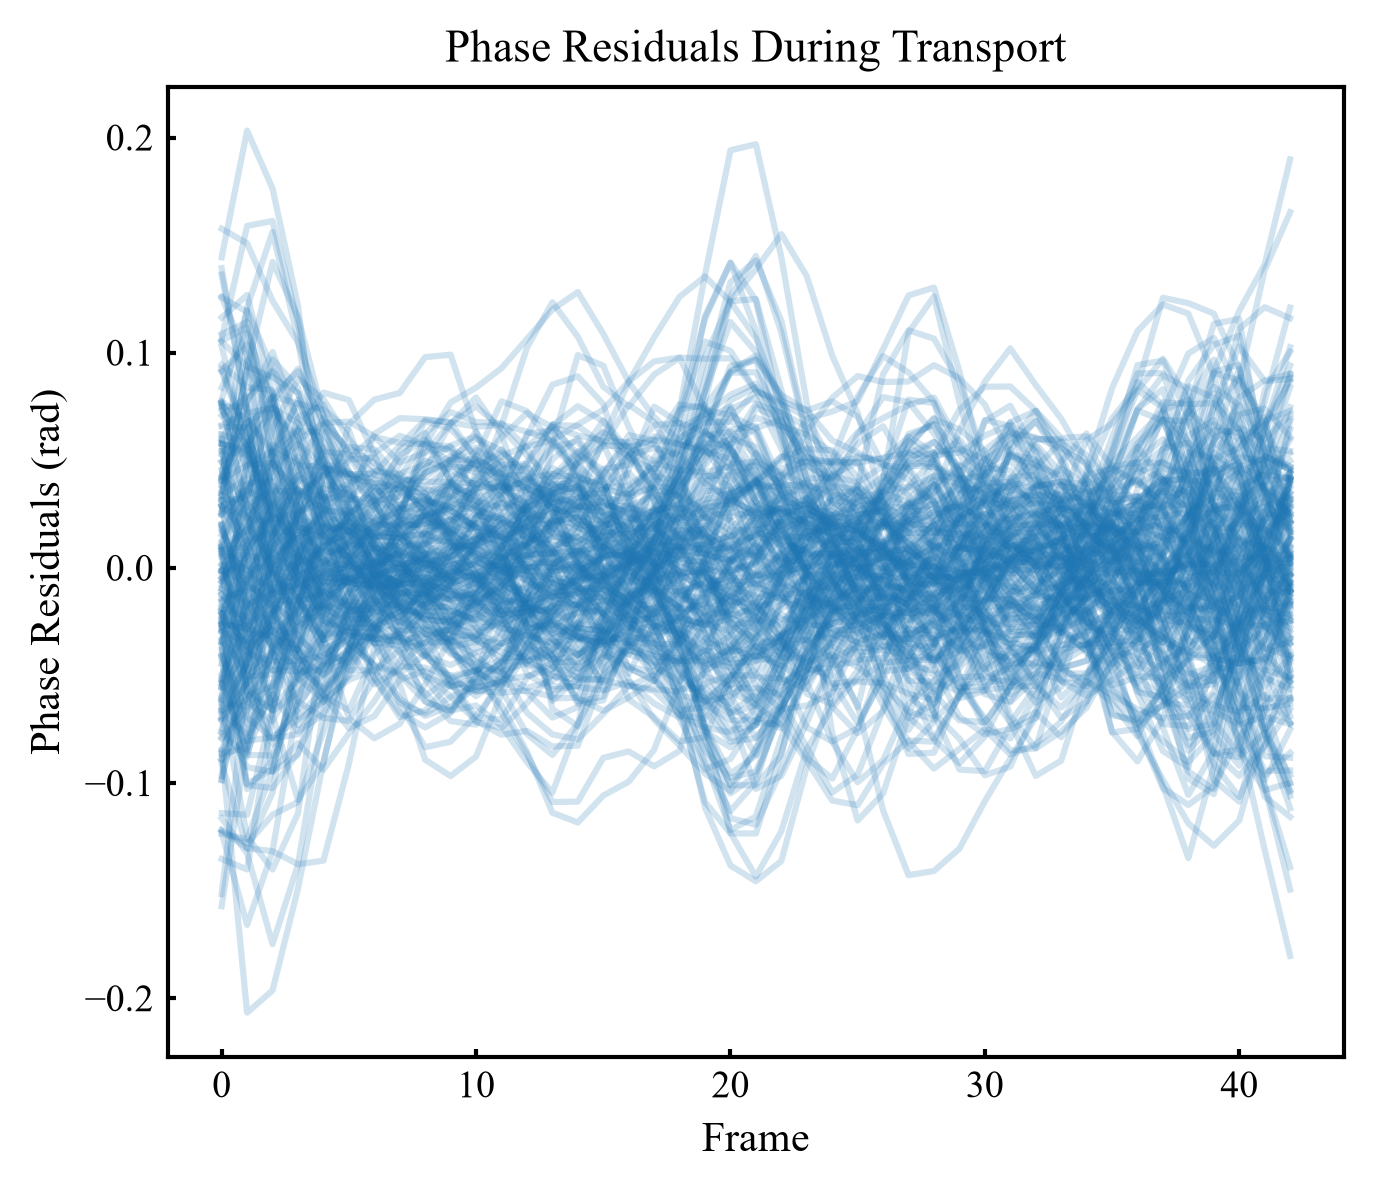

In [251]:
x_values = []
y_values = []

lin_fit = lambda x, m, b: m * x + b
for n in range(phi_array.shape[1]):
    x = np.arange(phi_array.shape[0]-1)
    y = np.unwrap(phi_array[1:, n])
    popt, pcov = curve_fit(lin_fit, x, y)
    y_fit = lin_fit(x, *popt)
    residuals = y - y_fit
    #plt.plot(x, y, alpha=0.5, color='C0')
    #plt.plot(x, y_fit, alpha=0.8, color='C1')
    plt.plot(x, residuals, alpha=0.2, color='C0')
    x_values.append(x)
    y_values.append(residuals)

#plt.ylim(-np.pi/5, np.pi/5)
plt.xlabel("Frame")
plt.ylabel("Phase Residuals (rad)")
plt.title(f"Phase Residuals During Transport")

x_values = np.array(x_values).flatten()
y_values = np.array(y_values).flatten()

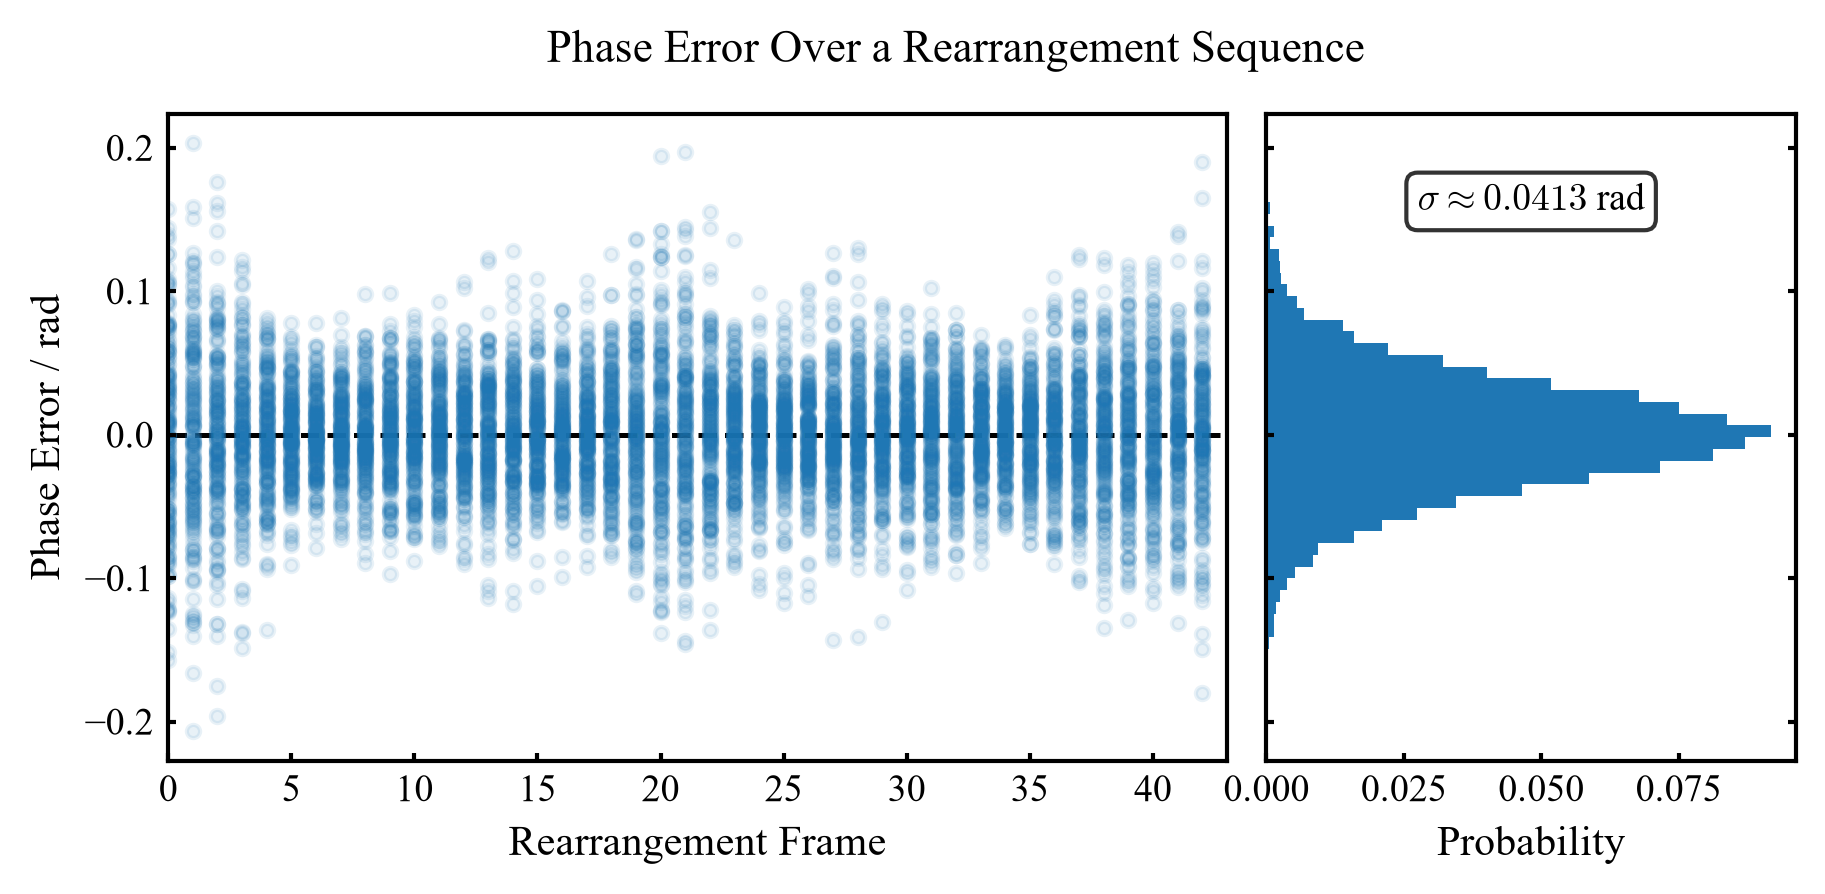

In [252]:

fig_width = 7.0 
fig_height = 2.8

# sharey=True links the y-axes. gridspec_kw sets the width ratios (scatter is wider)
# wspace controls the gap between the two plots. 0.05 pulls them close together.
fig, (ax_scatter, ax_hist) = plt.subplots(
    1, 2, 
    figsize=(fig_width, fig_height), 
    sharey=True, 
    gridspec_kw={'width_ratios': [2, 1], 'wspace': 0.05}
)

# ==============================================================================
# 4. PLOT LEFT PANEL: SCATTER PLOT
# ==============================================================================
# Using hollow circles (facecolor='none') prevents dense clusters from turning into a blob
ax_scatter.scatter(
    x_values, y_values, facecolor='C0', linewidth=1.0, s=10, label='Individual Traps', alpha=0.1
)

# Add a dashed line representing the ideal target intensity
ax_scatter.axhline(0.0, color='black', linestyle='--', linewidth=1.2, zorder=-1)

ax_scatter.set_xlabel("Rearrangement Frame")
ax_scatter.set_ylabel(r"Phase Error / rad")
ax_scatter.set_xlim(0, phi_array.shape[0]-1)

# ==============================================================================
# 5. PLOT RIGHT PANEL: HORIZONTAL HISTOGRAM
# ==============================================================================
# orientation='horizontal' makes the histogram bins align perfectly with the Y-axis
ax_hist.hist(
    residuals_saved, 
    bins=50, 
    orientation='horizontal', 
    color='C0', 
    alpha=1.0,
    linewidth=1.0,
    weights=weights
)

ax_hist.set_xlabel("Probability")

# Optional: Add a text box to the histogram to show the standard deviation mathematically
stats_text = r"$\sigma \approx {:.4f}$ rad".format(np.std(residuals_saved))
ax_hist.text(
    0.5, 0.85, stats_text, 
    transform=ax_hist.transAxes, 
    fontsize=9,
    ha='center',
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3', alpha=0.8)
)

# ==============================================================================
# 6. FINAL FORMATTING & EXPORT
# ==============================================================================
# Ensure the histogram's right side also has inward ticks (sharey=True removes the left ones)
ax_hist.tick_params(axis='y', which='both', labelleft=False, right=True)
plt.suptitle("Phase Error Over a Rearrangement Sequence")
plt.savefig("Images\\phase_flicker.png", bbox_inches='tight')


---
## Rearrangement 10x10 -> 7x7

In [253]:
date = "12Aug26"
DataManager.list_datasets(date);
dataset = DataManager.load_dataset(date, "rearrangement_10x10_7x7")

Datasets found in C:\Users\tweez\Box\Working folder\caftweezers\Data\2026\Aug\12Aug26:
  - imaging_survival_40ms/
  - imaging_survival_50ms/
  - rearrangement_10x10_7x7/
  - rearrangement_step_size_scans/
Loading dataset: rearrangement_10x10_7x7

--- Experimental Info ---

Dataset Title: rearrangement_10x10_7x7
Date: 2026-08-12 12:34:52

    50 ms time slot given for rearrangement with a baseline survival probability of 0.969698.
    Rearrangement parameters: d0 = 0.5, threshold = 5456.5652 photons, profile = linear, window_size = 5, feature_size = 10.
    Occupancy extraction using the PSF method.

----------------------------------------
Contents:
  Subdirectories:
    - final_images/
    - initial_images/
  Files:
    - experiment_info.txt
    - timing_and_images.pkl
----------------------------------------


In [254]:
data_pkl = dataset.pickles.get('timing_and_images.pkl')
data_pkl.keys()
imgs0 = data_pkl['imgs0']
imgs1 = data_pkl['imgs1']

Looking for trap sites...
100 Atoms Detected.


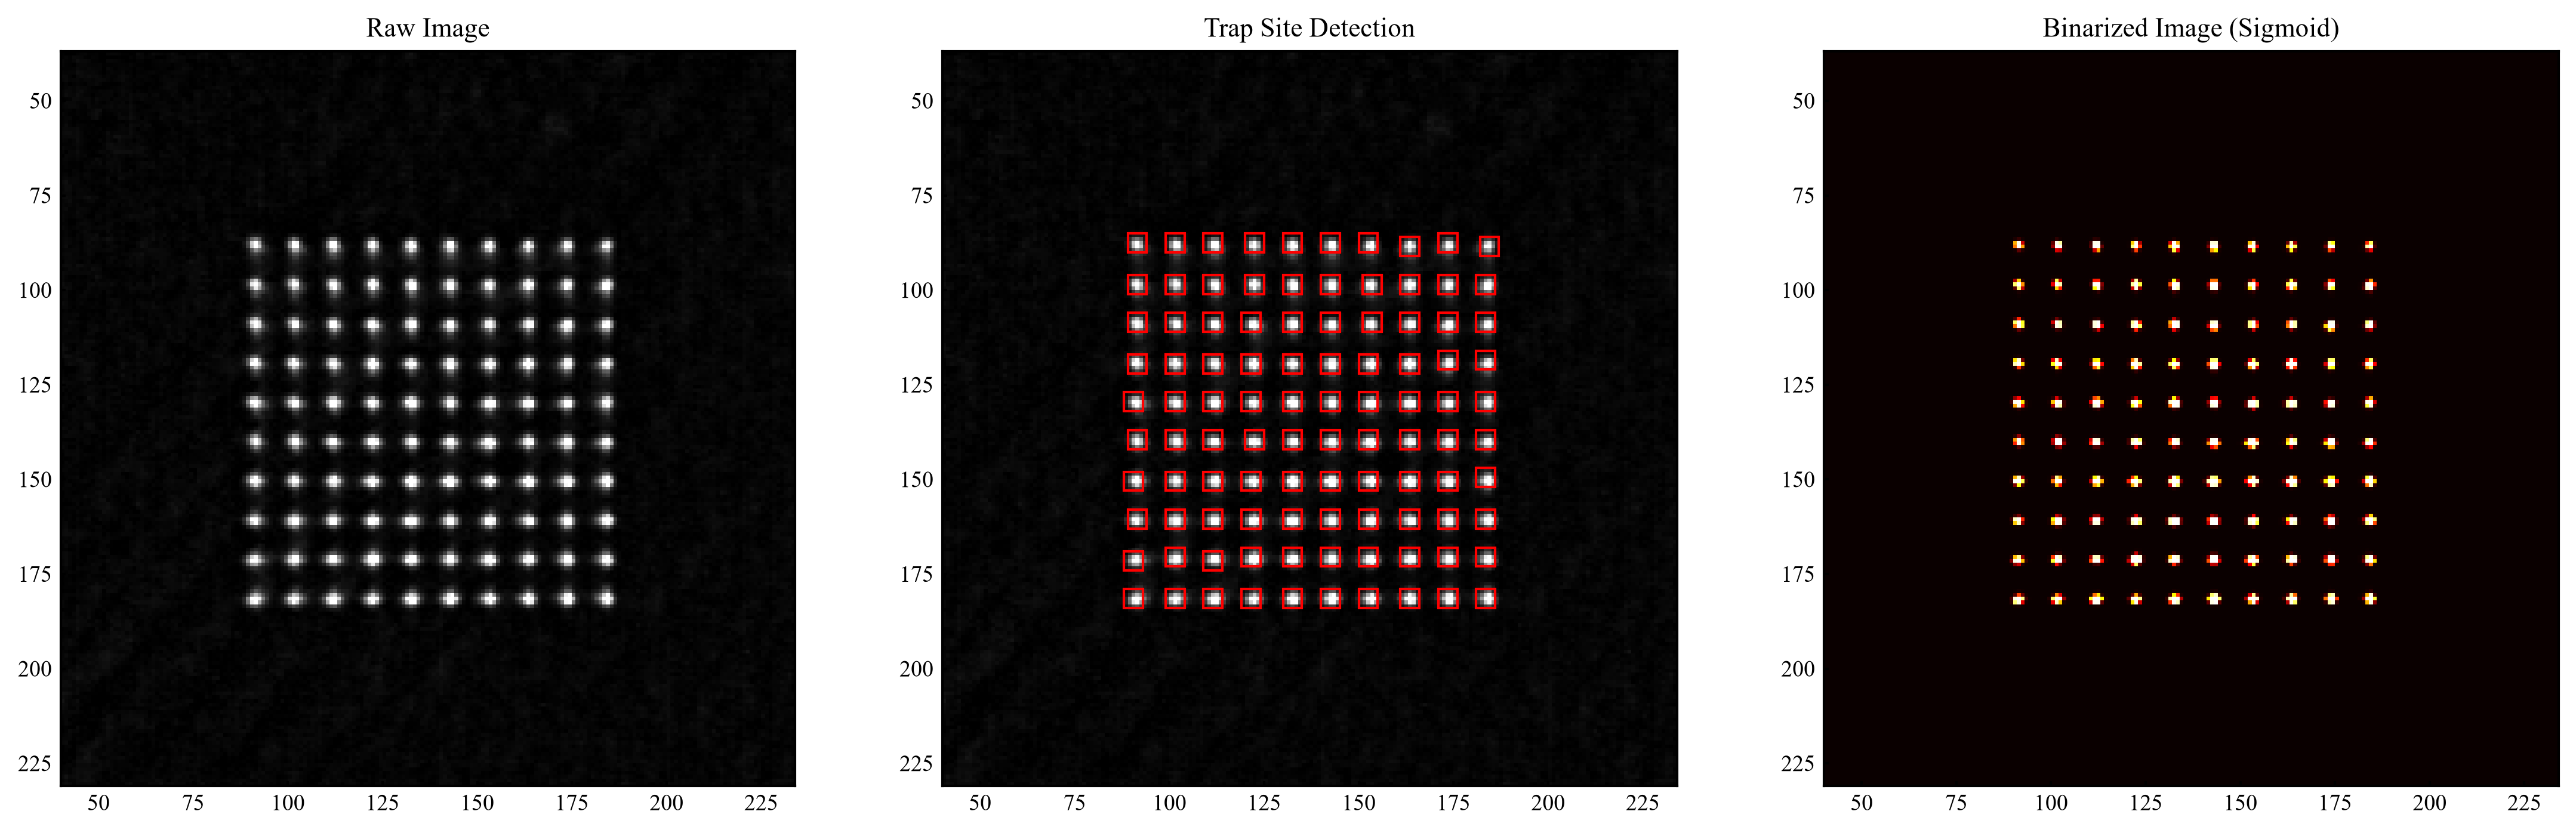

Trap (0) Loading Probability : 55.50 %
Trap (1) Loading Probability : 54.10 %
Trap (2) Loading Probability : 57.10 %
Trap (3) Loading Probability : 55.90 %
Trap (4) Loading Probability : 53.90 %
Trap (5) Loading Probability : 55.50 %
Trap (6) Loading Probability : 52.80 %
Trap (7) Loading Probability : 54.10 %
Trap (8) Loading Probability : 49.00 %
Trap (9) Loading Probability : 53.00 %
Trap (10) Loading Probability : 56.00 %
Trap (11) Loading Probability : 53.60 %
Trap (12) Loading Probability : 55.60 %
Trap (13) Loading Probability : 53.60 %
Trap (14) Loading Probability : 55.30 %
Trap (15) Loading Probability : 54.90 %
Trap (16) Loading Probability : 55.10 %
Trap (17) Loading Probability : 53.90 %
Trap (18) Loading Probability : 57.10 %
Trap (19) Loading Probability : 56.00 %
Trap (20) Loading Probability : 55.40 %
Trap (21) Loading Probability : 55.40 %
Trap (22) Loading Probability : 54.90 %
Trap (23) Loading Probability : 53.10 %
Trap (24) Loading Probability : 53.30 %
Trap (25) 

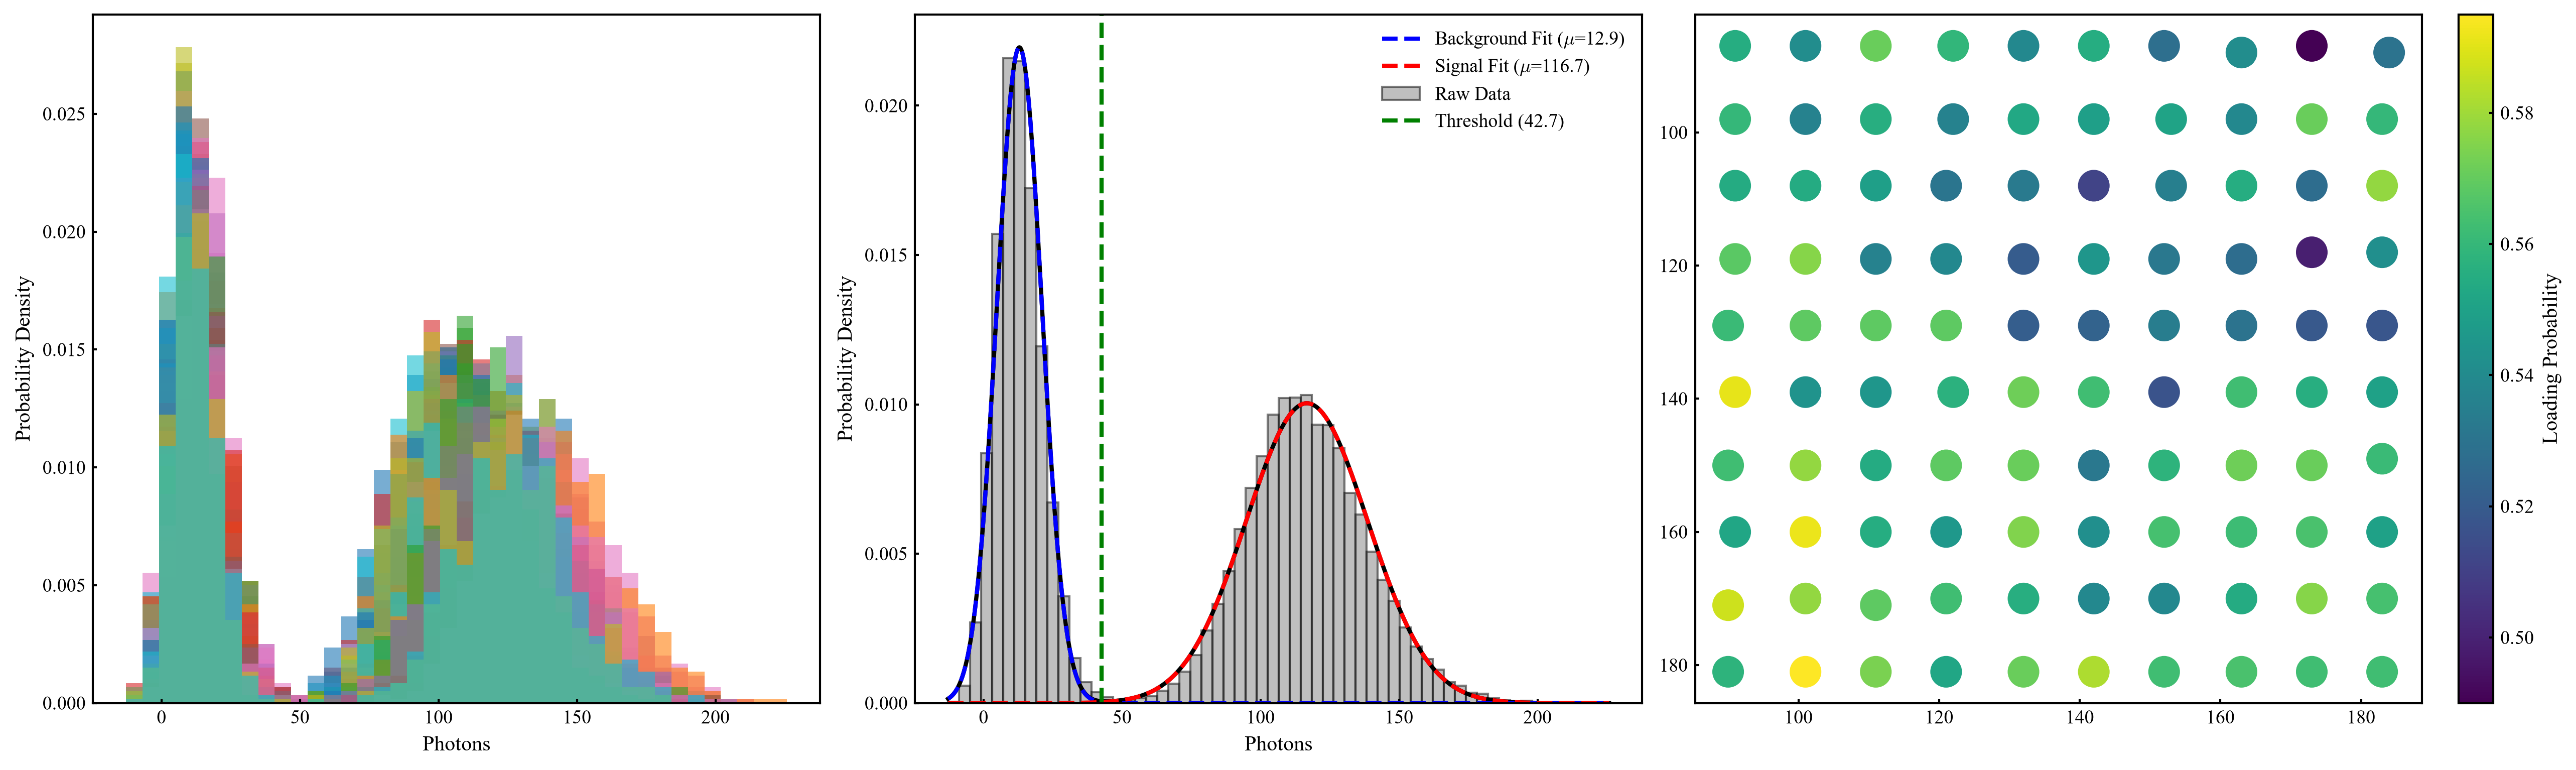

In [255]:
window, feature_size = 5, 10
imgs_n_mean = imgs0.mean(axis=0)
imgs_n_mean_filtered = an.morphological_tophat_high_pass(imgs_n_mean, feature_size=feature_size)
grid_positions_1, detection_threshold = an.detect_trap_sites(imgs_n_mean_filtered, 100, detection_step=50)
an.visualize_results(imgs_n_mean_filtered, grid_positions_1, margin=50, window_size=window, threshold=detection_threshold, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.7)
imgs_filtered = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs0]
photon_rates_1, loading_probabilities, threshold_2, fidelity = an.get_array_loading_statistics(imgs_filtered, grid_positions_1, threshold_detection=True, threshold=30, window_size=window, binning=60)

Trap (0) Loading Probability : 55.70 %
Trap (1) Loading Probability : 54.20 %
Trap (2) Loading Probability : 57.00 %
Trap (3) Loading Probability : 56.00 %
Trap (4) Loading Probability : 54.00 %
Trap (5) Loading Probability : 55.70 %
Trap (6) Loading Probability : 52.70 %
Trap (7) Loading Probability : 54.20 %
Trap (8) Loading Probability : 49.00 %
Trap (9) Loading Probability : 53.00 %
Trap (10) Loading Probability : 56.10 %
Trap (11) Loading Probability : 53.60 %
Trap (12) Loading Probability : 55.80 %
Trap (13) Loading Probability : 53.90 %
Trap (14) Loading Probability : 55.40 %
Trap (15) Loading Probability : 54.90 %
Trap (16) Loading Probability : 55.40 %
Trap (17) Loading Probability : 54.00 %
Trap (18) Loading Probability : 57.20 %
Trap (19) Loading Probability : 56.20 %
Trap (20) Loading Probability : 55.50 %
Trap (21) Loading Probability : 55.50 %
Trap (22) Loading Probability : 54.90 %
Trap (23) Loading Probability : 52.90 %
Trap (24) Loading Probability : 53.20 %
Trap (25) 

Trap (43) Loading Probability : 56.90 %
Trap (44) Loading Probability : 51.90 %
Trap (45) Loading Probability : 52.20 %
Trap (46) Loading Probability : 53.30 %
Trap (47) Loading Probability : 52.90 %
Trap (48) Loading Probability : 51.90 %
Trap (49) Loading Probability : 51.70 %
Trap (50) Loading Probability : 59.20 %
Trap (51) Loading Probability : 54.30 %
Trap (52) Loading Probability : 54.50 %
Trap (53) Loading Probability : 55.70 %
Trap (54) Loading Probability : 57.20 %
Trap (55) Loading Probability : 56.20 %
Trap (56) Loading Probability : 51.70 %
Trap (57) Loading Probability : 56.30 %
Trap (58) Loading Probability : 55.60 %
Trap (59) Loading Probability : 55.00 %
Trap (60) Loading Probability : 57.00 %
Trap (61) Loading Probability : 56.10 %
Trap (62) Loading Probability : 56.40 %
Trap (63) Loading Probability : 57.80 %
Trap (64) Loading Probability : 55.20 %
Trap (65) Loading Probability : 56.80 %
Trap (66) Loading Probability : 53.00 %
Trap (67) Loading Probability : 55.70 %


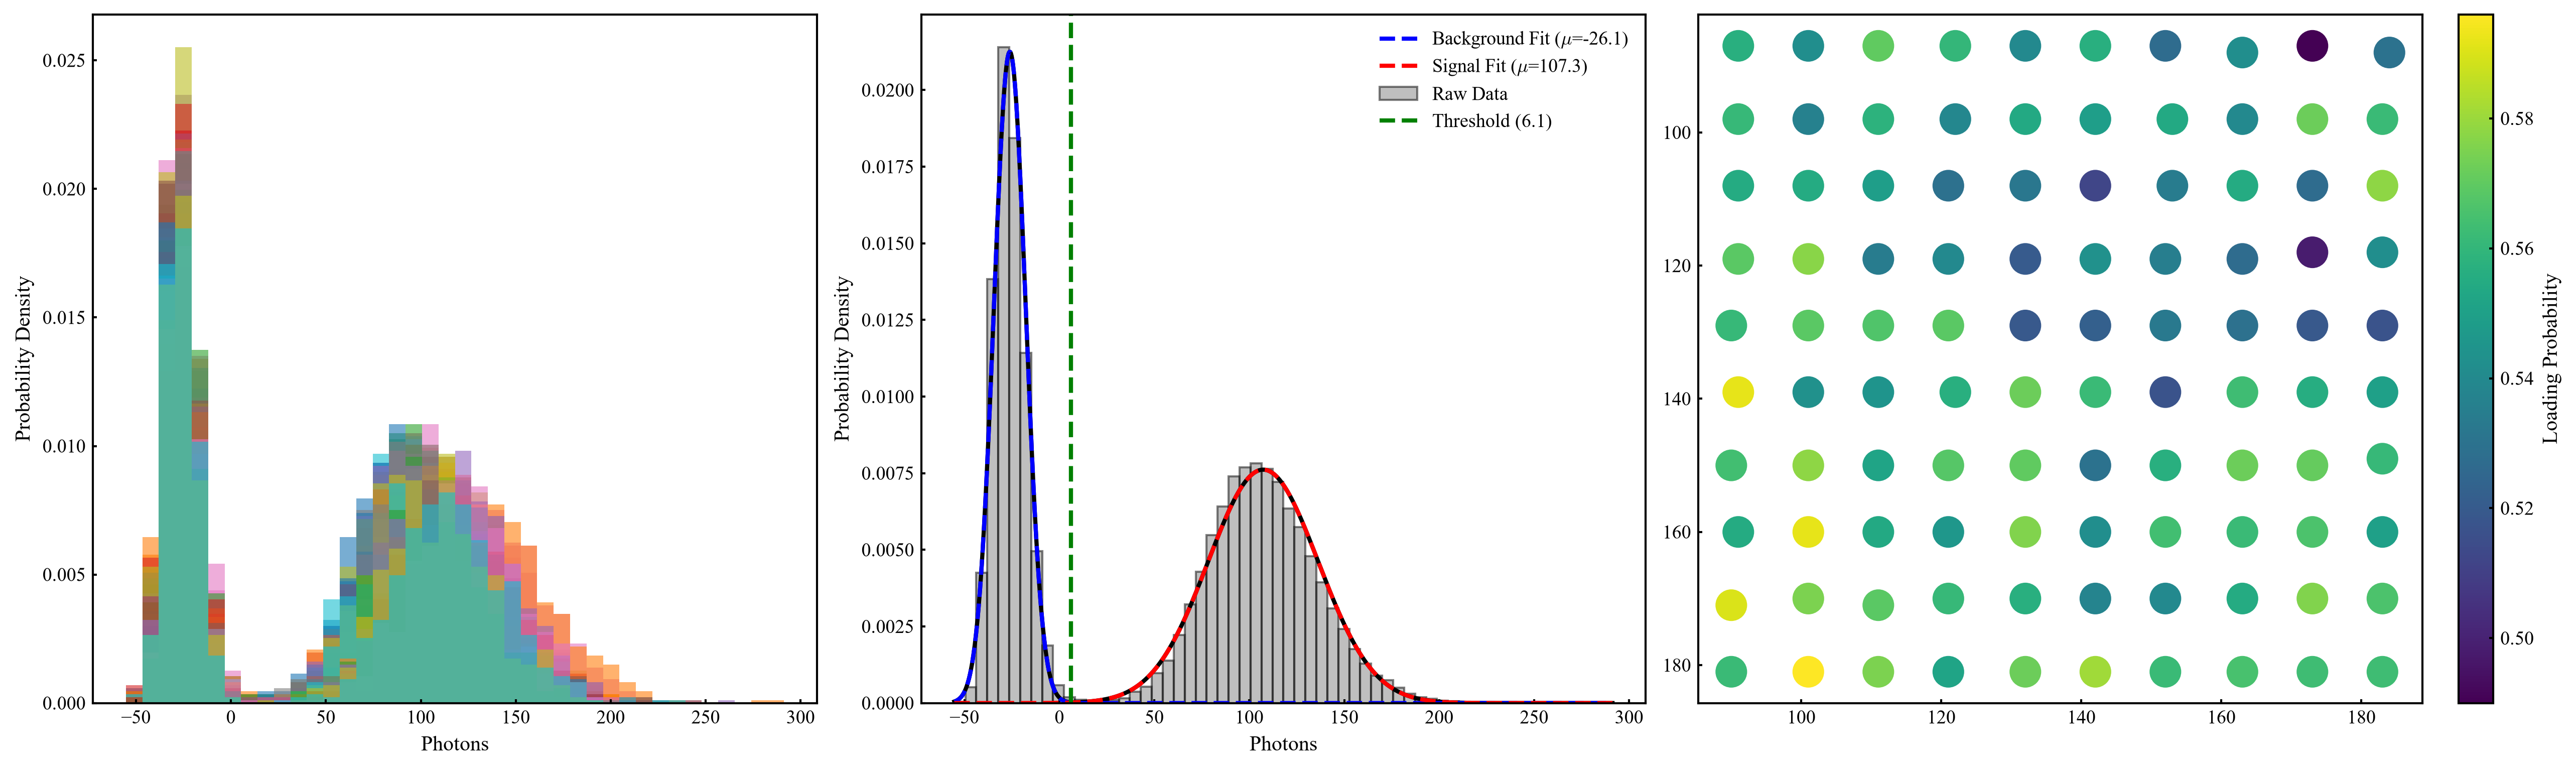

In [256]:
psf_window = 9

scorer = an.SiteScorer.from_images(imgs0, grid_positions_1, window_size=psf_window)
photons, loading_probabilities, threshold_1, fidelity = an.get_array_loading_statistics(imgs0, grid_positions_1, scorer=scorer, threshold_detection=True, binning=60)
scorer.threshold = threshold_1 * 1.0
print(f"PSF threshold {scorer.threshold:.2f} photons, detection fidelity {fidelity*100:.3f} %")

Looking for trap sites...
49 Atoms Detected.


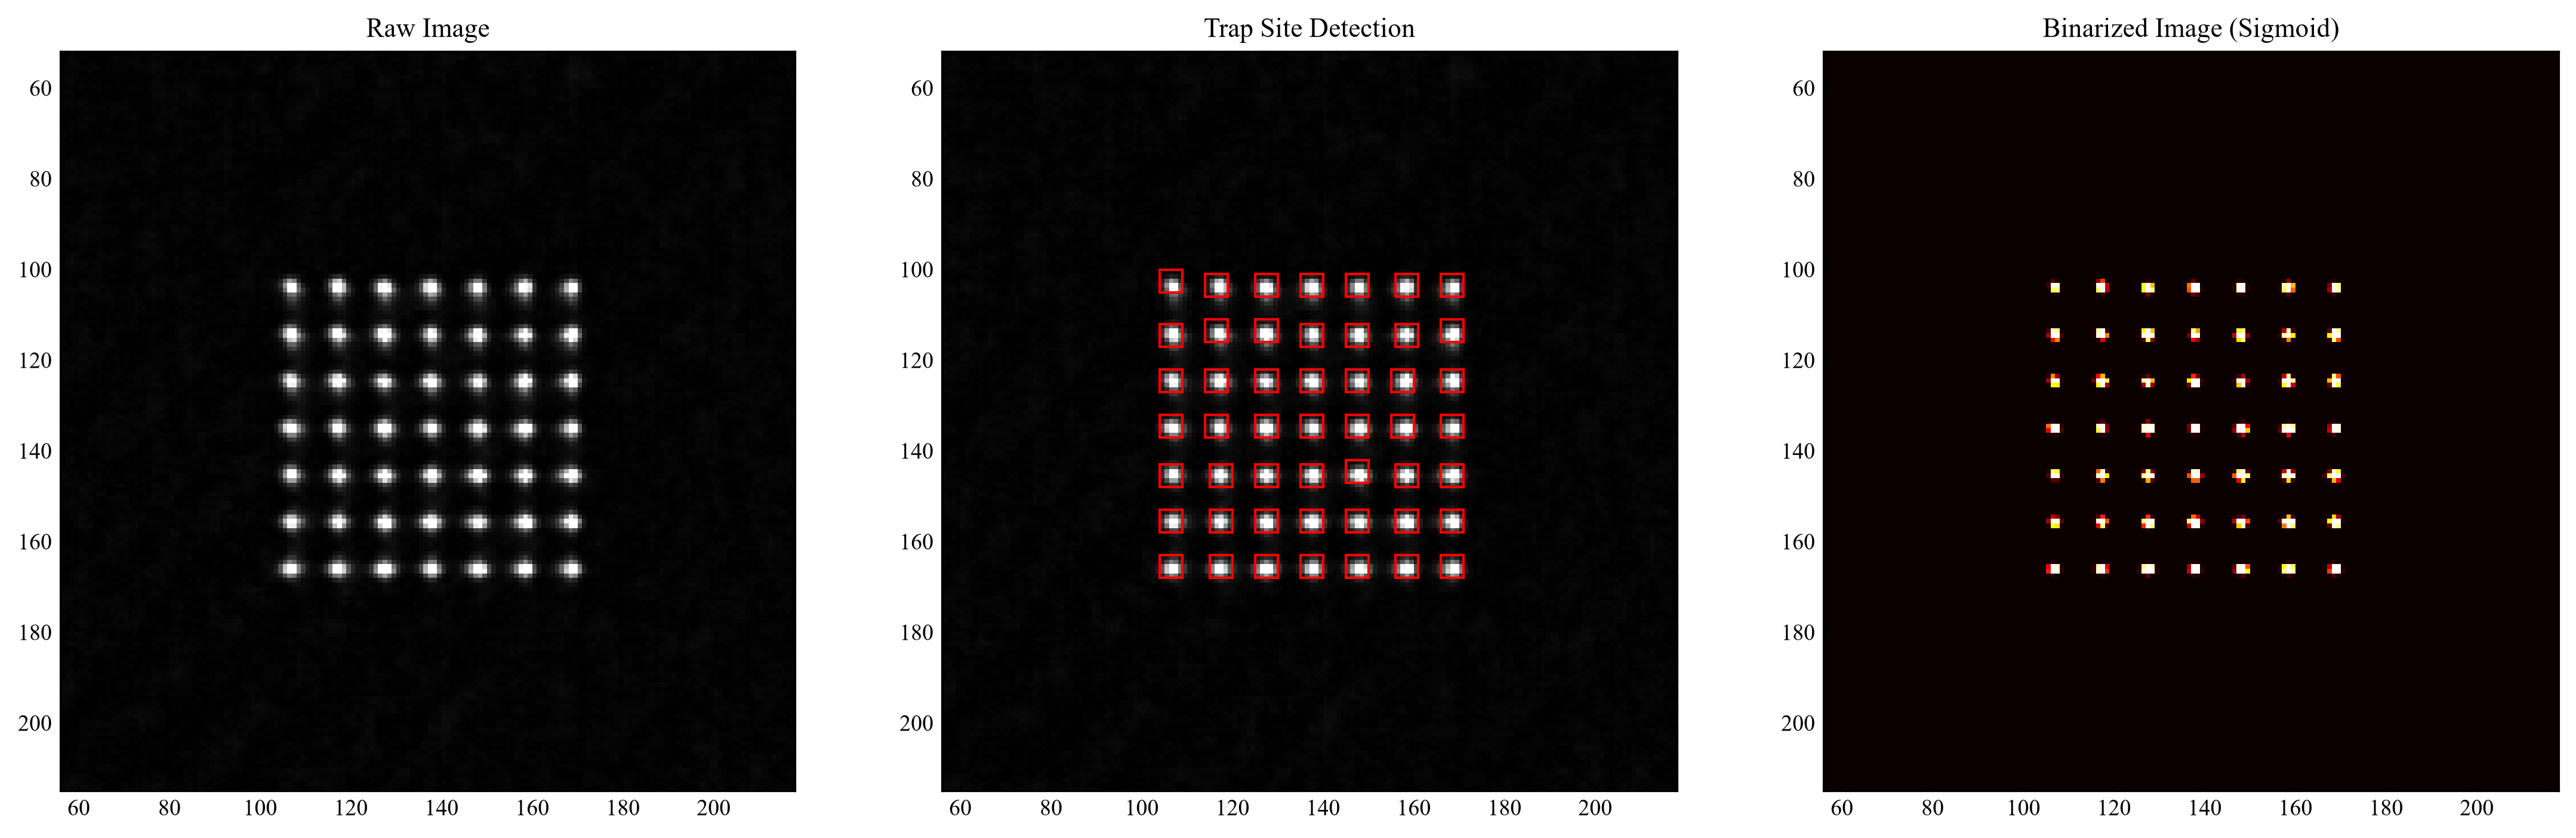

Trap (0) Loading Probability : 96.10 %
Trap (1) Loading Probability : 96.70 %
Trap (2) Loading Probability : 96.80 %
Trap (3) Loading Probability : 96.30 %
Trap (4) Loading Probability : 96.80 %
Trap (5) Loading Probability : 96.20 %
Trap (6) Loading Probability : 96.50 %
Trap (7) Loading Probability : 96.50 %
Trap (8) Loading Probability : 96.10 %
Trap (9) Loading Probability : 97.30 %
Trap (10) Loading Probability : 97.50 %
Trap (11) Loading Probability : 94.80 %
Trap (12) Loading Probability : 94.50 %
Trap (13) Loading Probability : 95.70 %
Trap (14) Loading Probability : 96.60 %
Trap (15) Loading Probability : 97.20 %
Trap (16) Loading Probability : 95.20 %
Trap (17) Loading Probability : 93.80 %
Trap (18) Loading Probability : 94.50 %
Trap (19) Loading Probability : 96.70 %
Trap (20) Loading Probability : 95.80 %
Trap (21) Loading Probability : 96.00 %
Trap (22) Loading Probability : 96.30 %
Trap (23) Loading Probability : 95.50 %
Trap (24) Loading Probability : 93.50 %
Trap (25) 

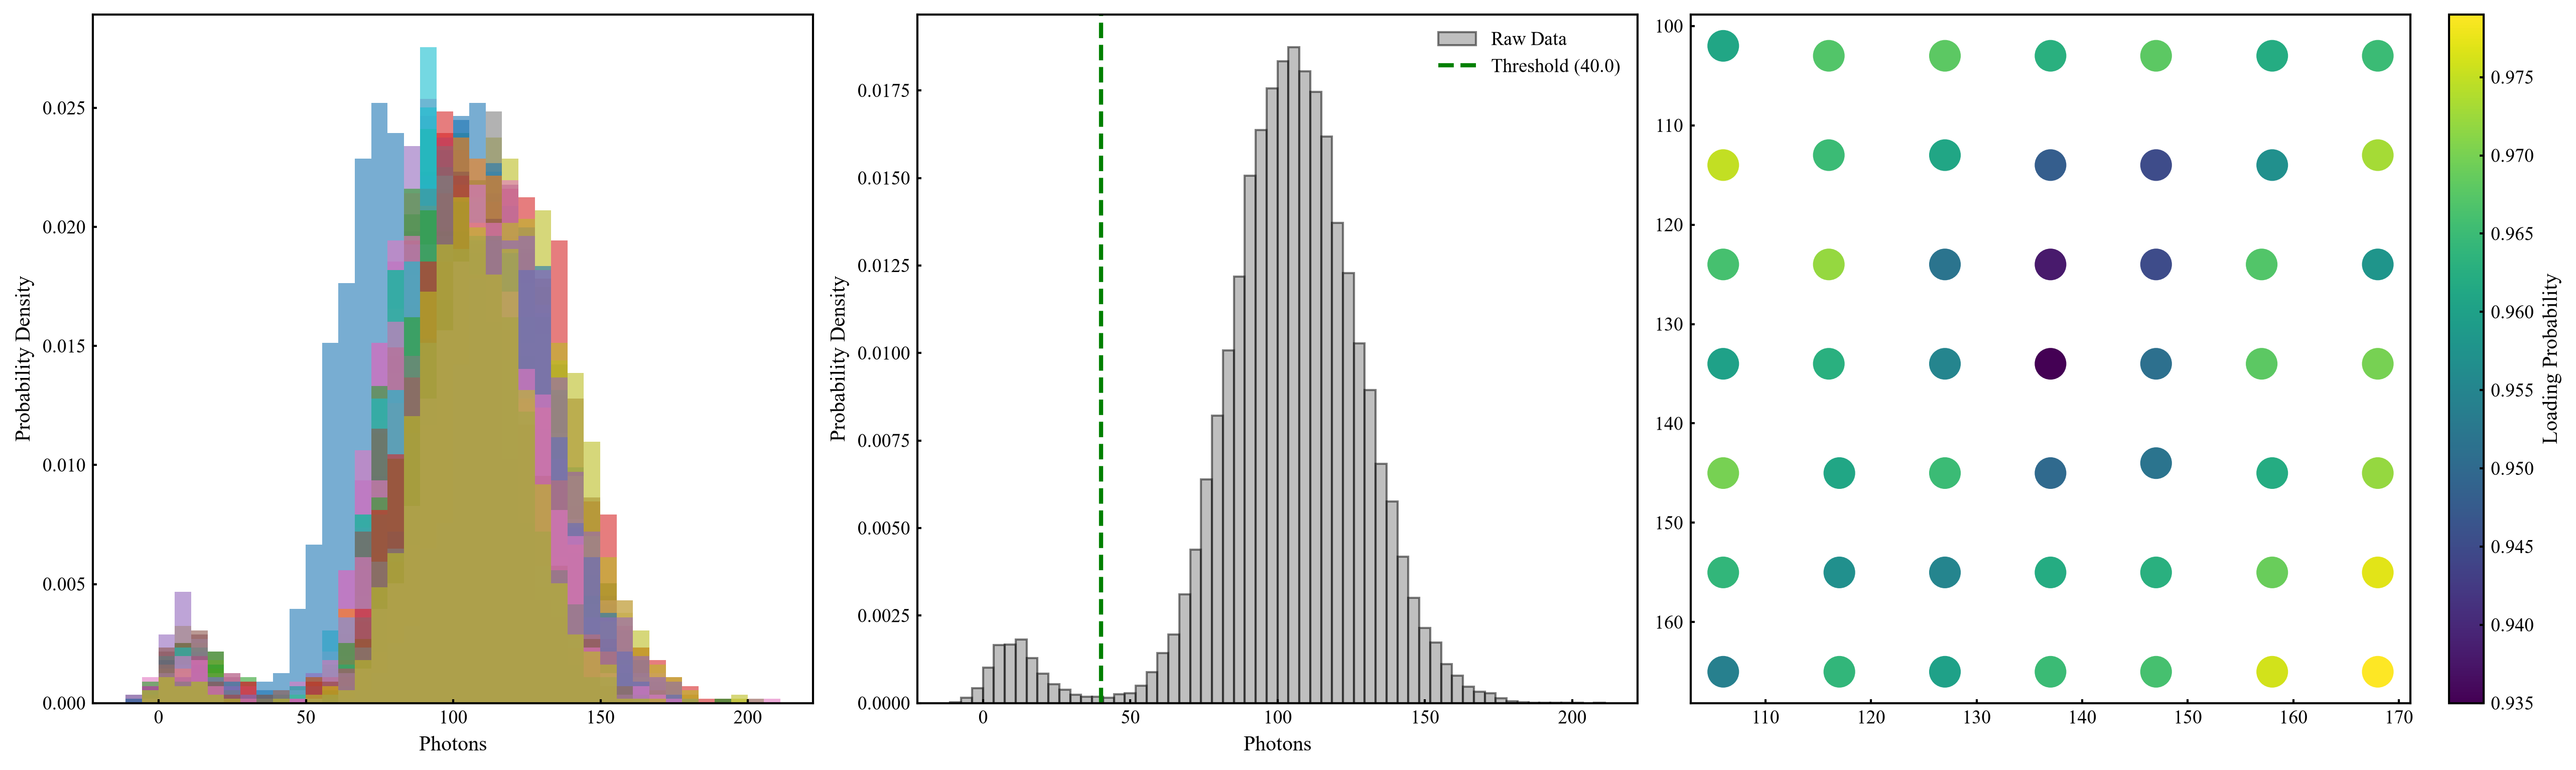

In [257]:
window, feature_size = 5, 10
imgs_n_mean = imgs1.mean(axis=0)
imgs_n_mean_filtered = an.morphological_tophat_high_pass(imgs_n_mean, feature_size=feature_size)
grid_positions_2, detection_threshold = an.detect_trap_sites(imgs_n_mean_filtered, 49, detection_step=50)
an.visualize_results(imgs_n_mean_filtered, grid_positions_2, margin=50, window_size=window, threshold=detection_threshold, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.7)
imgs_filtered = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
photon_rates_2, loading_probabilities, threshold_2, fidelity = an.get_array_loading_statistics(imgs_filtered, grid_positions_2, threshold_detection=False, threshold=40, window_size=window, binning=60)

Threshold detection failed: list index out of range. Trying default threshold of 1.00 kHz.
Trap (0) Loading Probability : 97.00 %
Trap (1) Loading Probability : 97.10 %
Trap (2) Loading Probability : 96.80 %
Trap (3) Loading Probability : 96.50 %
Trap (4) Loading Probability : 96.90 %
Trap (5) Loading Probability : 96.70 %
Trap (6) Loading Probability : 96.70 %
Trap (7) Loading Probability : 96.90 %
Trap (8) Loading Probability : 96.00 %
Trap (9) Loading Probability : 97.50 %
Trap (10) Loading Probability : 97.70 %
Trap (11) Loading Probability : 94.90 %
Trap (12) Loading Probability : 94.60 %
Trap (13) Loading Probability : 96.00 %
Trap (14) Loading Probability : 96.60 %
Trap (15) Loading Probability : 97.20 %
Trap (16) Loading Probability : 95.50 %
Trap (17) Loading Probability : 94.00 %
Trap (18) Loading Probability : 94.50 %
Trap (19) Loading Probability : 96.80 %
Trap (20) Loading Probability : 95.90 %
Trap (21) Loading Probability : 96.10 %
Trap (22) Loading Probability : 96.40 %

Trap (23) Loading Probability : 95.70 %
Trap (24) Loading Probability : 93.60 %
Trap (25) Loading Probability : 95.10 %
Trap (26) Loading Probability : 96.80 %
Trap (27) Loading Probability : 97.20 %
Trap (28) Loading Probability : 95.20 %
Trap (29) Loading Probability : 97.10 %
Trap (30) Loading Probability : 96.20 %
Trap (31) Loading Probability : 96.60 %
Trap (32) Loading Probability : 95.10 %
Trap (33) Loading Probability : 96.60 %
Trap (34) Loading Probability : 97.30 %
Trap (35) Loading Probability : 97.00 %
Trap (36) Loading Probability : 95.90 %
Trap (37) Loading Probability : 95.50 %
Trap (38) Loading Probability : 96.20 %
Trap (39) Loading Probability : 96.70 %
Trap (40) Loading Probability : 97.30 %
Trap (41) Loading Probability : 97.80 %
Trap (42) Loading Probability : 95.50 %
Trap (43) Loading Probability : 96.50 %
Trap (44) Loading Probability : 96.00 %
Trap (45) Loading Probability : 96.90 %
Trap (46) Loading Probability : 96.60 %
Trap (47) Loading Probability : 97.60 %


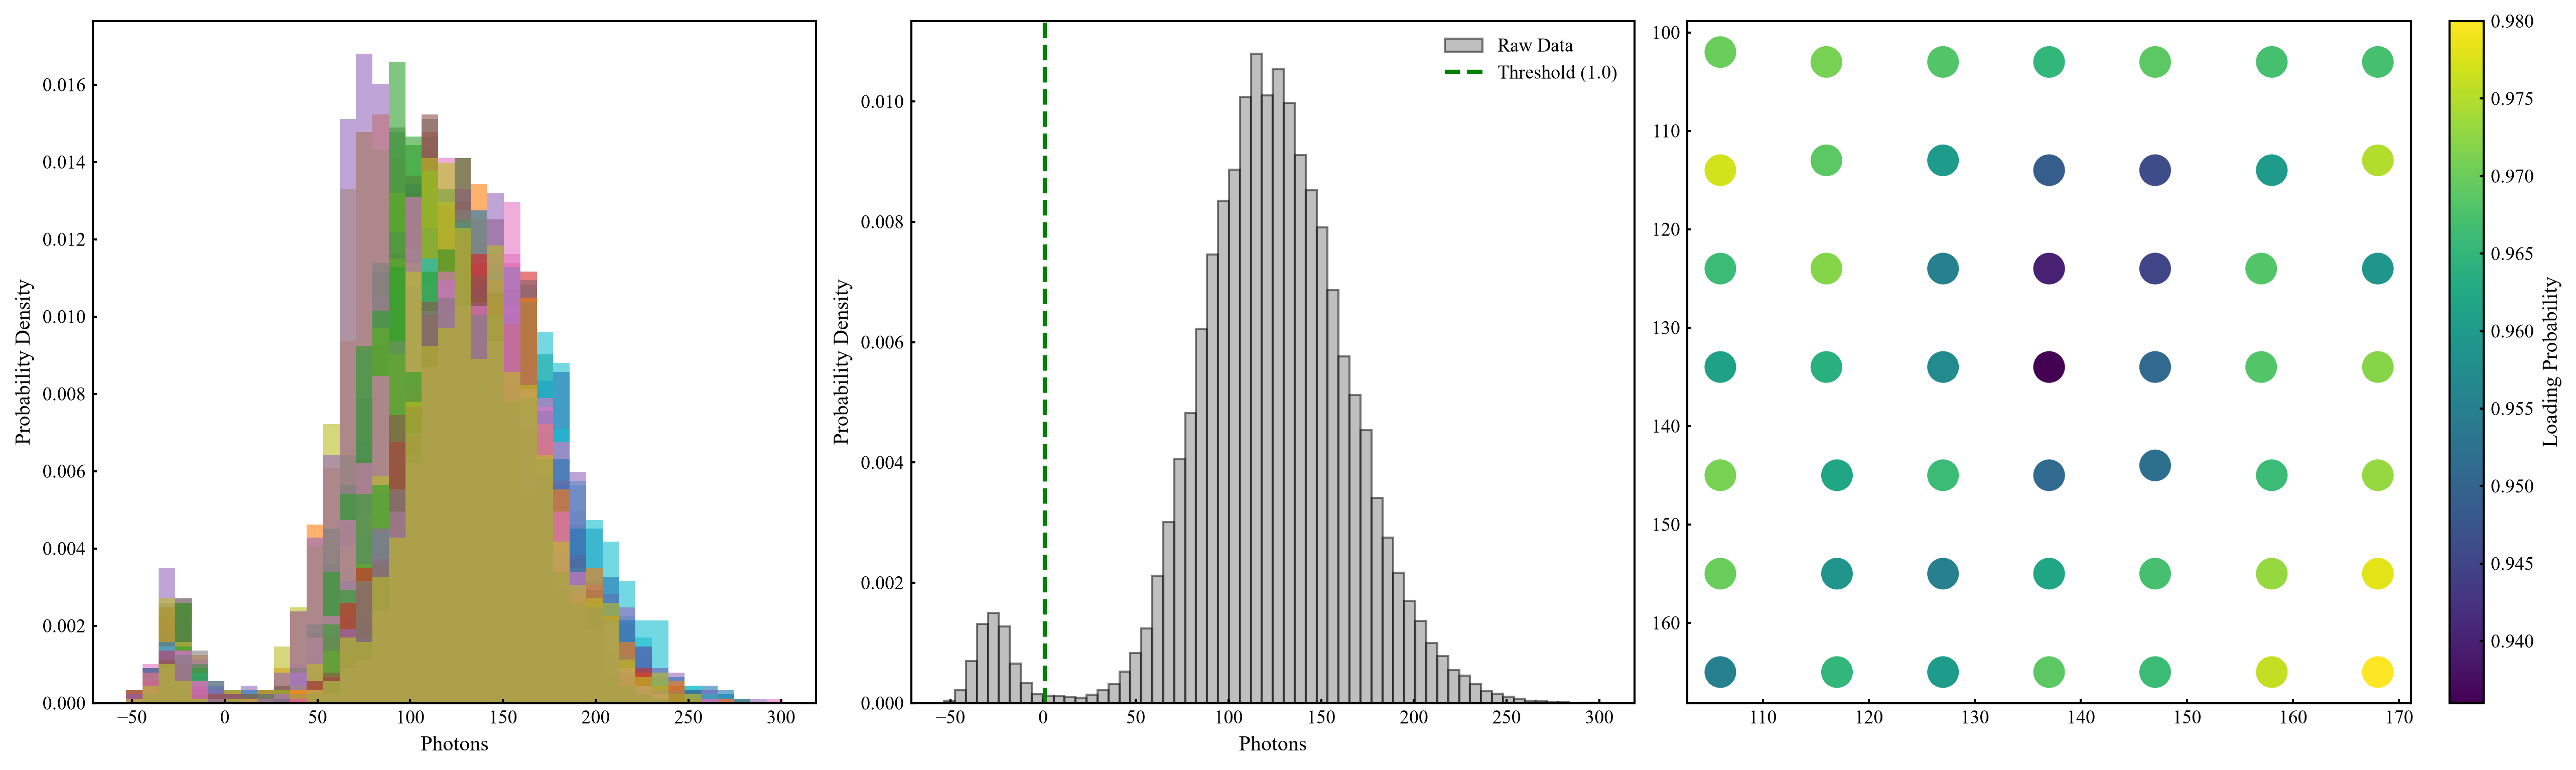

In [258]:
psf_window = 9

scorer = an.SiteScorer.from_images(imgs1, grid_positions_2, window_size=psf_window)
photons, loading_probabilities, threshold_1, fidelity = an.get_array_loading_statistics(imgs1, grid_positions_2, scorer=scorer, threshold_detection=True, binning=60)
scorer.threshold = threshold_1 * 1.0
print(f"PSF threshold {scorer.threshold:.2f} photons, detection fidelity {fidelity*100:.3f} %")

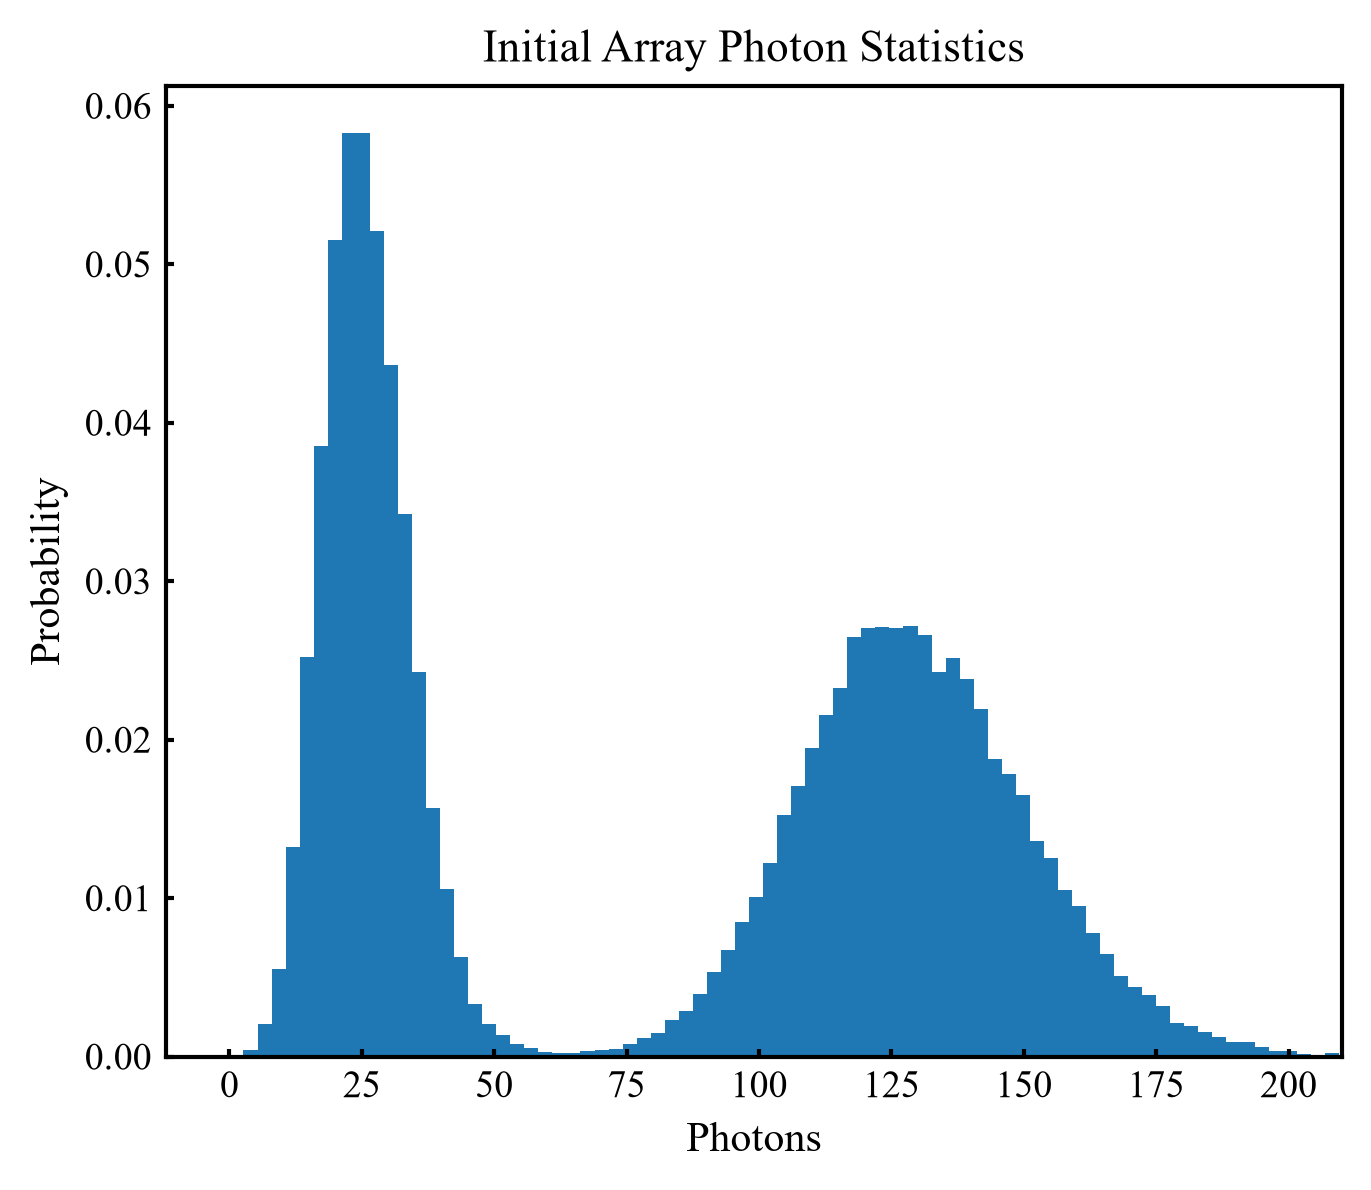

In [259]:
photons1 = photon_rates_1.flatten()

weights = np.ones_like(photons1) / len(photons1)
plt.hist(photons1 - photons1.min(), bins=90, weights=weights)
plt.xlabel('Photons')
plt.ylabel('Probability')
plt.title('Initial Array Photon Statistics')
plt.xlim(None, 210)
plt.savefig("Images\\init_histogram.png", bbox_inches='tight')

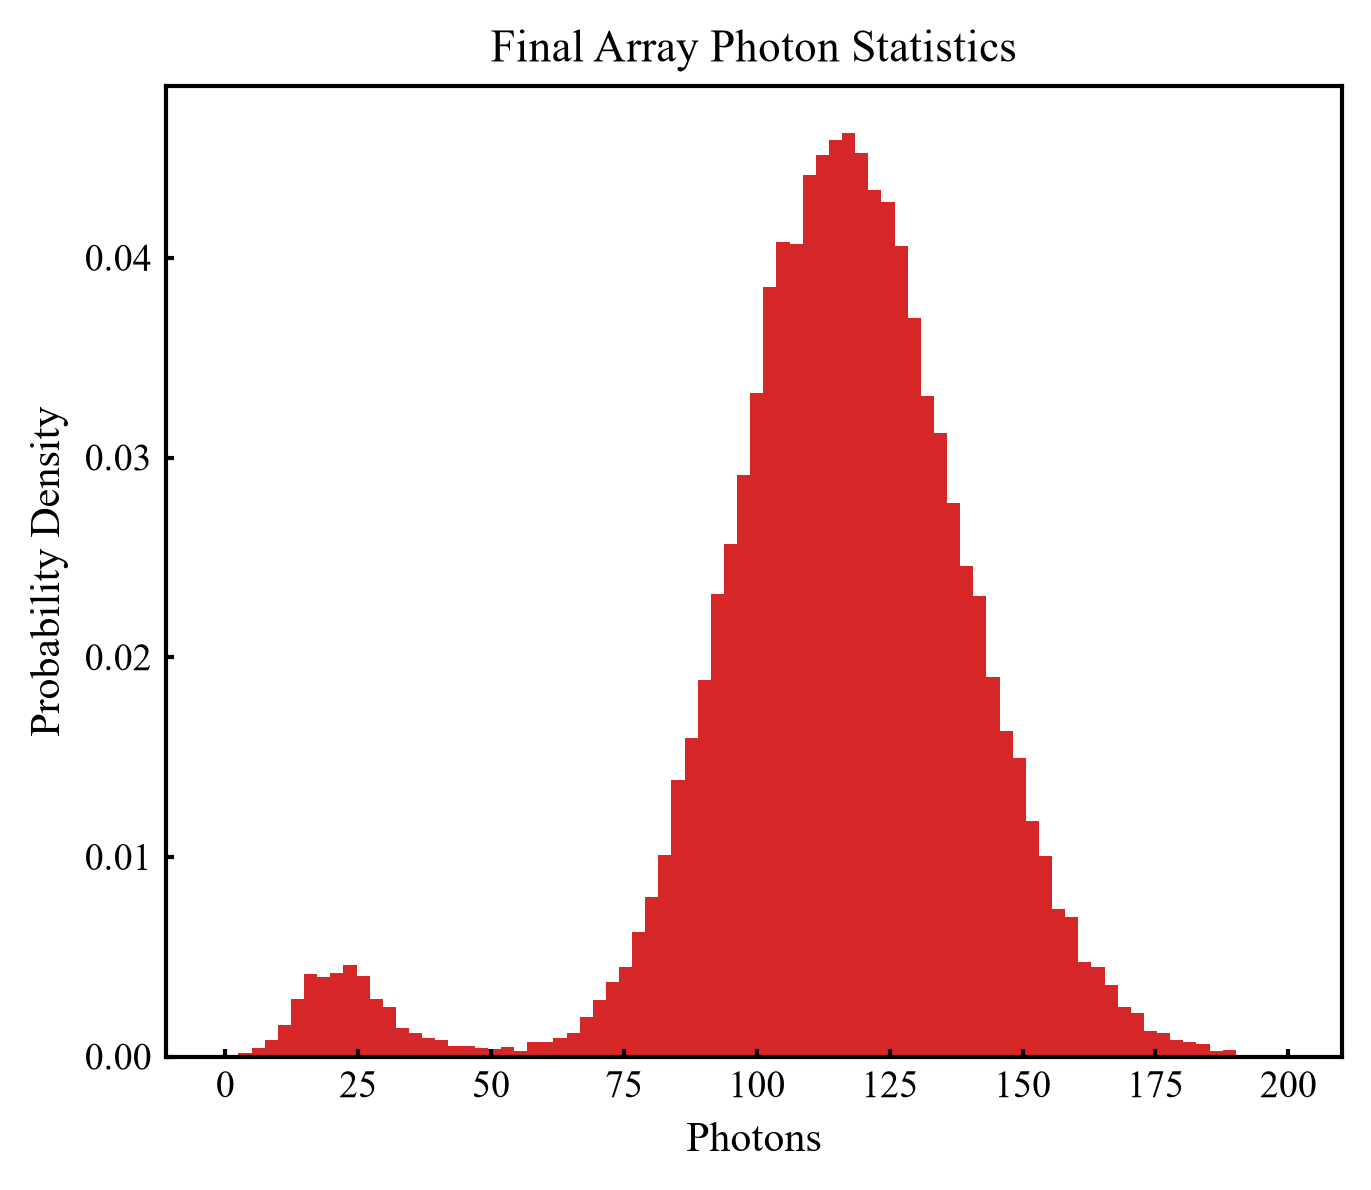

In [260]:
photons2 = photon_rates_2.flatten()

weights = np.ones_like(photons2) / len(photons2)
plt.hist(photons2 - photons2.min(), bins=90, color='C3', weights=weights)
plt.xlabel('Photons')
plt.ylabel('Probability Density')
plt.title('Final Array Photon Statistics')
plt.xlim(None, 210)
plt.savefig("Images\\final_histogram.png", bbox_inches='tight')

---
## Rearrangement 15x15 -> 10x10

In [88]:
date = "21Aug26"
DataManager.list_datasets(date);
dataset = DataManager.load_dataset(date, "rearrangement_15x15_10x10")

Datasets found in C:\Users\tweez\Box\Working folder\caftweezers\Data\2026\Aug\21Aug26:
  - rearrangement_12x12square_72kagome/
  - rearrangement_15x15_10x10/
Loading dataset: rearrangement_15x15_10x10

--- Experimental Info ---

Dataset Title: rearrangement_15x15_10x10
Date: 2026-08-21 16:46:48

    50 ms time slot given for rearrangement with a baseline survival probability of 0.953086.
    Rearrangement parameters: d0 = 0.5, threshold = 2110.5708 photons, profile = linear, window_size = 5, feature_size = 10.
    Occupancy extraction using the PSF method.

----------------------------------------
Contents:
  Subdirectories:
    - 0_images/
    - 1_images/
    - 2_images/
  Files:
    - experiment_info.txt
    - timing_and_images.pkl
----------------------------------------


In [90]:
data_pkl = dataset.pickles.get('timing_and_images.pkl')
data_pkl.keys()
imgs0 = data_pkl['imgs0']
imgs1 = data_pkl['imgs1']

Looking for trap sites...
225 Atoms Detected.


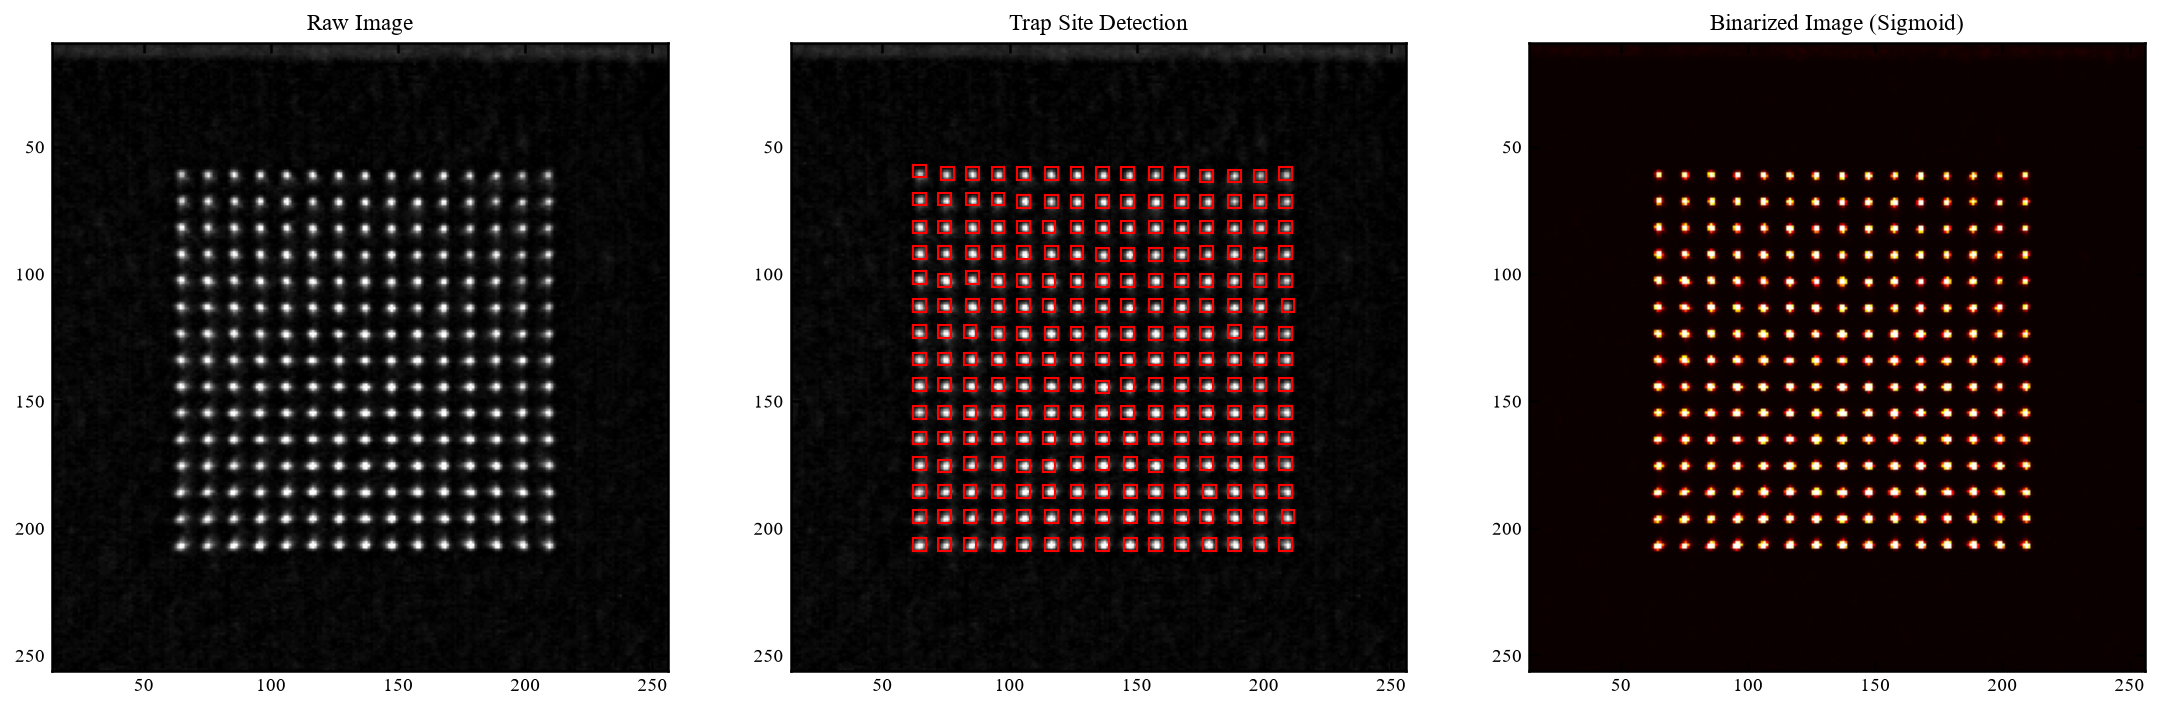

Trap (0) Loading Probability : 51.53 %
Trap (1) Loading Probability : 52.14 %
Trap (2) Loading Probability : 52.55 %
Trap (3) Loading Probability : 50.51 %
Trap (4) Loading Probability : 50.92 %
Trap (5) Loading Probability : 50.10 %
Trap (6) Loading Probability : 47.66 %
Trap (7) Loading Probability : 48.68 %
Trap (8) Loading Probability : 49.49 %
Trap (9) Loading Probability : 44.81 %
Trap (10) Loading Probability : 53.16 %
Trap (11) Loading Probability : 52.14 %
Trap (12) Loading Probability : 53.56 %
Trap (13) Loading Probability : 49.90 %
Trap (14) Loading Probability : 49.90 %
Trap (15) Loading Probability : 54.18 %
Trap (16) Loading Probability : 52.95 %
Trap (17) Loading Probability : 50.51 %
Trap (18) Loading Probability : 49.08 %
Trap (19) Loading Probability : 54.18 %
Trap (20) Loading Probability : 46.84 %
Trap (21) Loading Probability : 48.07 %
Trap (22) Loading Probability : 48.68 %
Trap (23) Loading Probability : 50.71 %
Trap (24) Loading Probability : 53.16 %
Trap (25) 

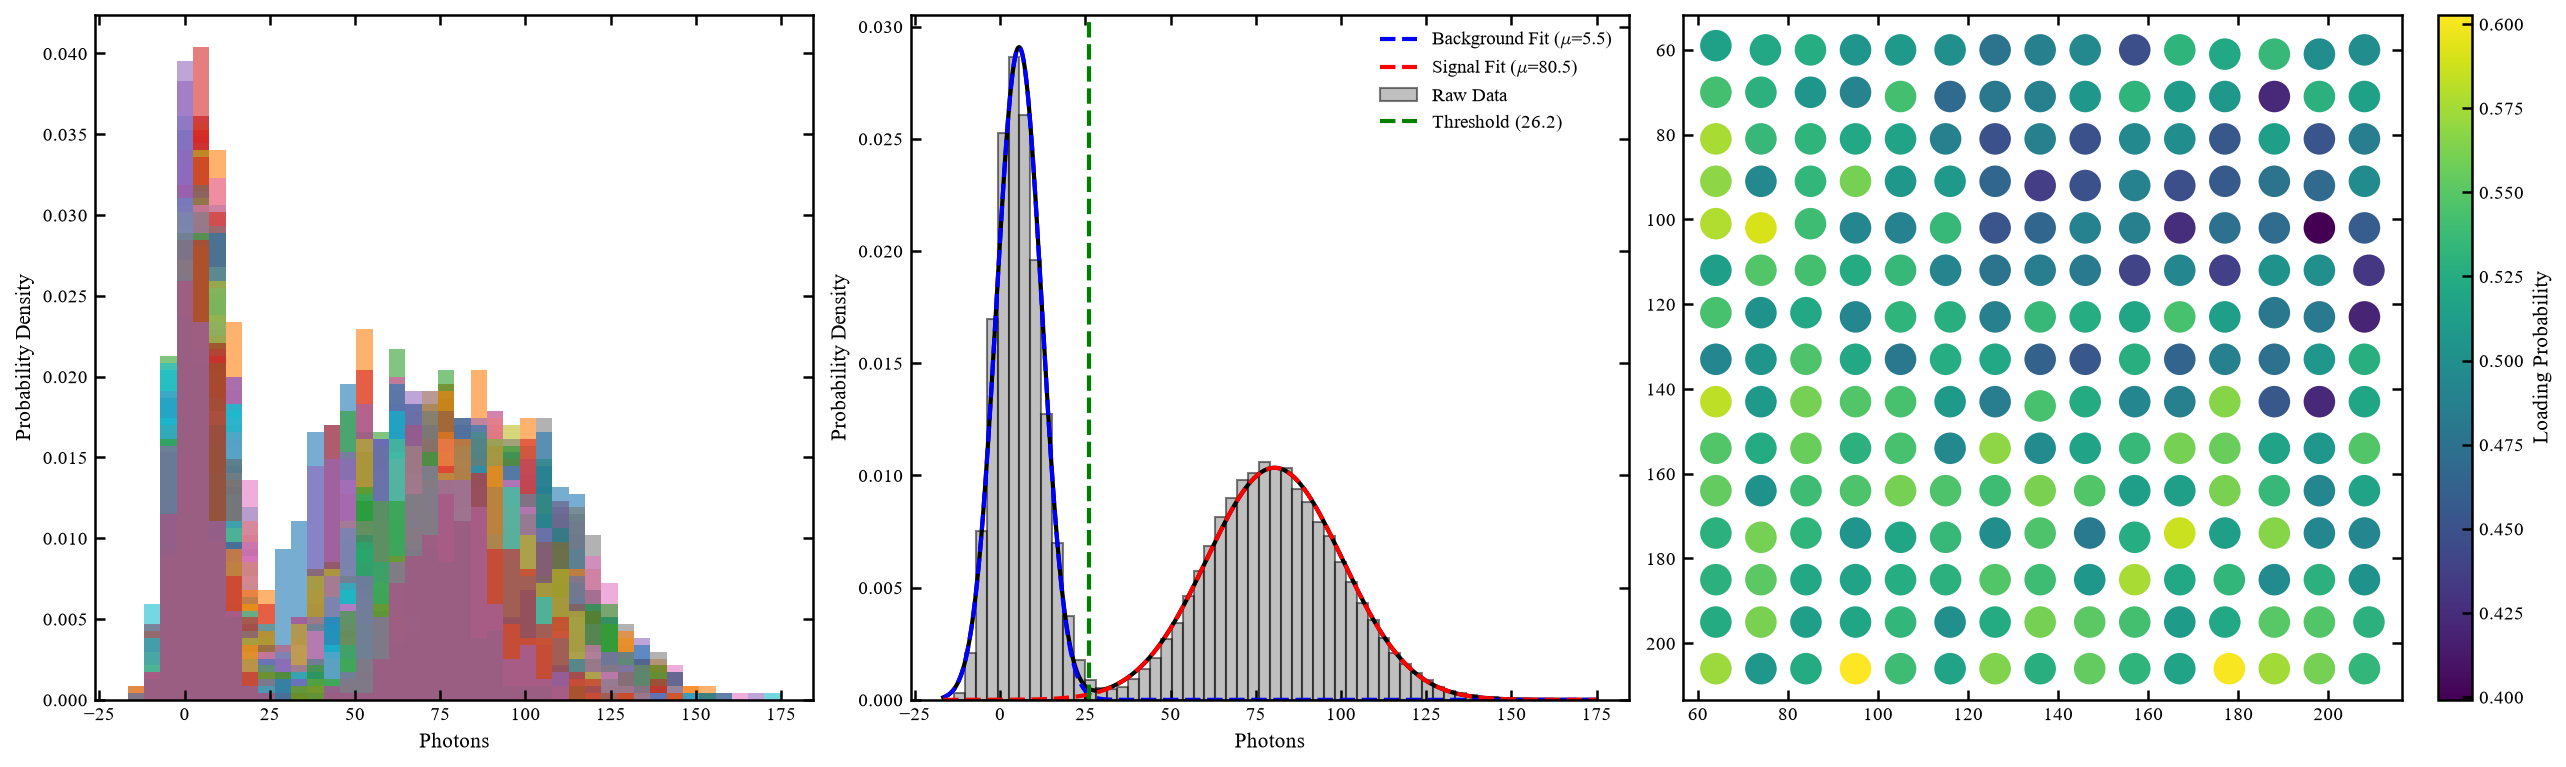

In [91]:
window, feature_size = 5, 10
n_atoms = 15*15
imgs_n_mean = imgs0.mean(axis=0)
imgs_n_mean_filtered = an.morphological_tophat_high_pass(imgs_n_mean, feature_size=feature_size)
grid_positions_1, detection_threshold = an.detect_trap_sites(imgs_n_mean_filtered, n_atoms, detection_step=50)
an.visualize_results(imgs_n_mean_filtered, grid_positions_1, margin=50, window_size=window, threshold=detection_threshold, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.7)
imgs_filtered = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs0]
photon_rates_1, loading_probabilities, threshold_2, fidelity = an.get_array_loading_statistics(imgs_filtered, grid_positions_1, threshold_detection=True, threshold=30, window_size=window, binning=60)

Trap (0) Loading Probability : 53.16 %
Trap (1) Loading Probability : 52.14 %
Trap (2) Loading Probability : 52.55 %
Trap (3) Loading Probability : 50.51 %
Trap (4) Loading Probability : 51.12 %
Trap (5) Loading Probability : 50.31 %
Trap (6) Loading Probability : 47.66 %
Trap (7) Loading Probability : 48.88 %
Trap (8) Loading Probability : 49.90 %
Trap (9) Loading Probability : 45.01 %
Trap (10) Loading Probability : 52.75 %
Trap (11) Loading Probability : 52.55 %
Trap (12) Loading Probability : 53.77 %
Trap (13) Loading Probability : 50.71 %
Trap (14) Loading Probability : 51.73 %
Trap (15) Loading Probability : 54.79 %
Trap (16) Loading Probability : 52.75 %
Trap (17) Loading Probability : 51.32 %
Trap (18) Loading Probability : 49.49 %
Trap (19) Loading Probability : 53.77 %
Trap (20) Loading Probability : 47.45 %
Trap (21) Loading Probability : 48.07 %
Trap (22) Loading Probability : 48.68 %
Trap (23) Loading Probability : 50.31 %
Trap (24) Loading Probability : 52.95 %
Trap (25) 

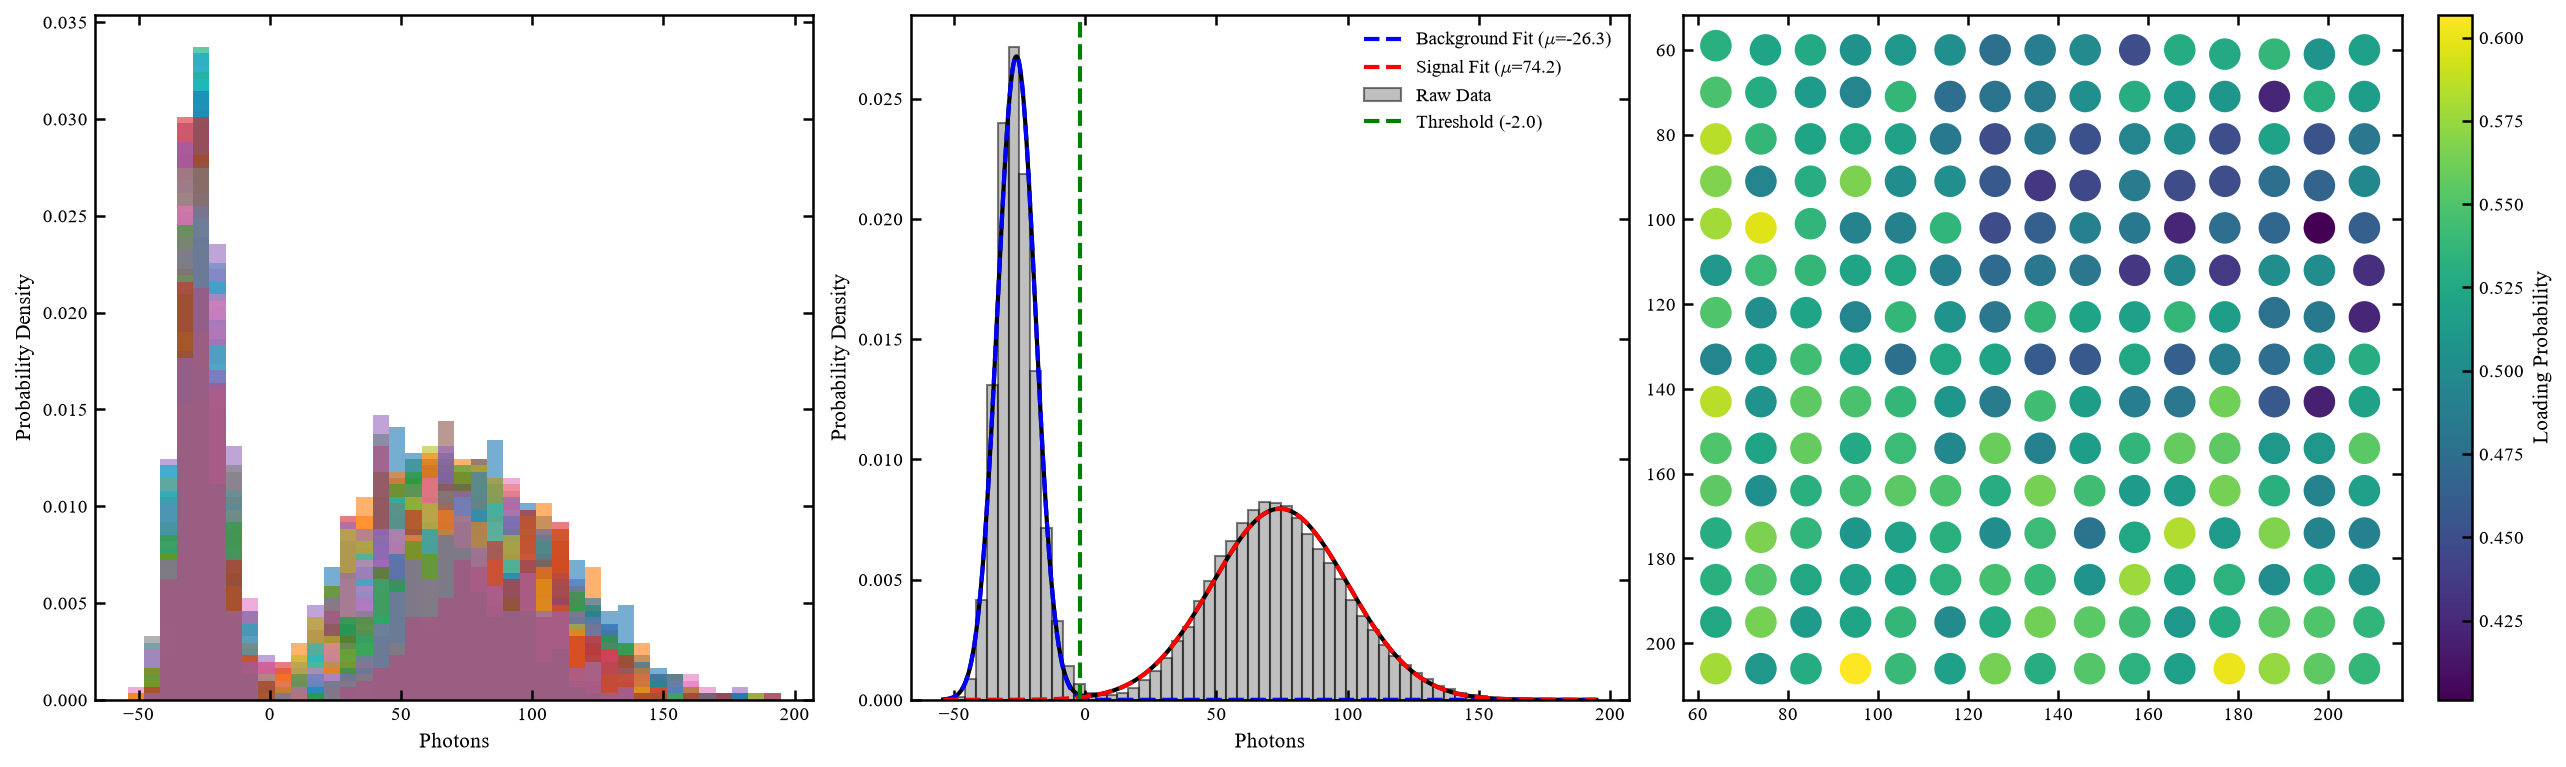

In [92]:
psf_window = 9

scorer = an.SiteScorer.from_images(imgs0, grid_positions_1, window_size=psf_window)
photons, loading_probabilities, threshold_1, fidelity = an.get_array_loading_statistics(imgs0, grid_positions_1, scorer=scorer, threshold_detection=True, binning=60)
scorer.threshold = threshold_1 * 1.0
print(f"PSF threshold {scorer.threshold:.2f} photons, detection fidelity {fidelity*100:.3f} %")

Looking for trap sites...
100 Atoms Detected.


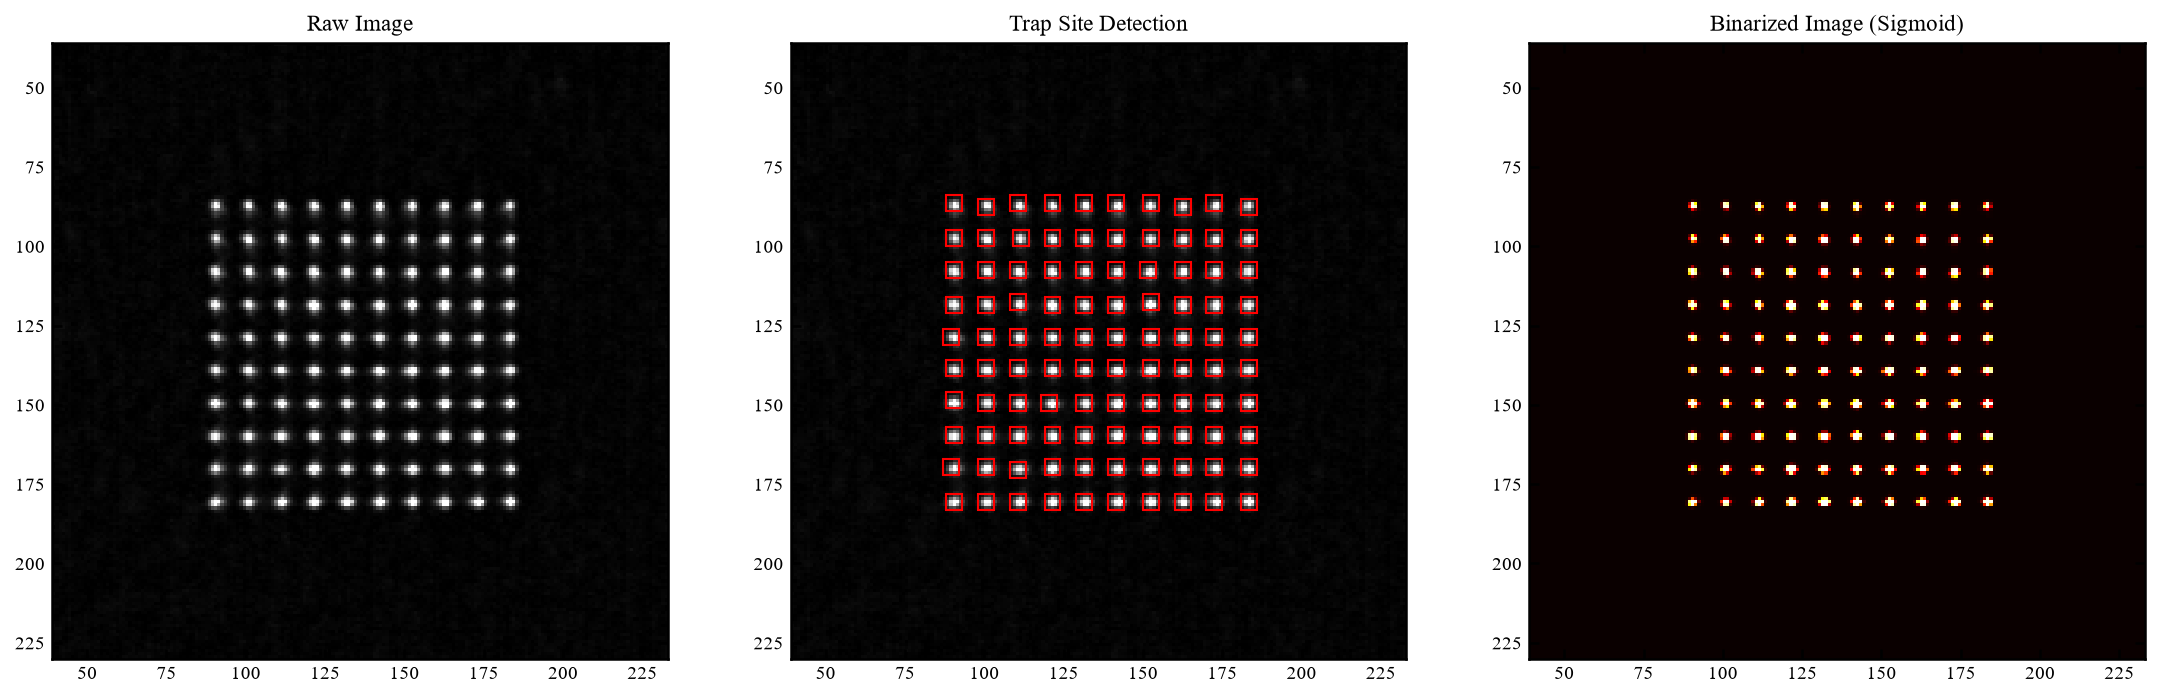

Trap (0) Loading Probability : 95.32 %
Trap (1) Loading Probability : 95.52 %
Trap (2) Loading Probability : 93.69 %
Trap (3) Loading Probability : 96.33 %
Trap (4) Loading Probability : 95.52 %
Trap (5) Loading Probability : 94.91 %
Trap (6) Loading Probability : 95.32 %
Trap (7) Loading Probability : 94.09 %
Trap (8) Loading Probability : 95.32 %
Trap (9) Loading Probability : 94.30 %
Trap (10) Loading Probability : 96.33 %
Trap (11) Loading Probability : 95.11 %
Trap (12) Loading Probability : 93.89 %
Trap (13) Loading Probability : 93.89 %
Trap (14) Loading Probability : 94.30 %
Trap (15) Loading Probability : 95.52 %
Trap (16) Loading Probability : 94.70 %
Trap (17) Loading Probability : 95.32 %
Trap (18) Loading Probability : 94.09 %
Trap (19) Loading Probability : 94.91 %
Trap (20) Loading Probability : 96.13 %
Trap (21) Loading Probability : 96.54 %
Trap (22) Loading Probability : 96.54 %
Trap (23) Loading Probability : 95.32 %
Trap (24) Loading Probability : 94.91 %
Trap (25) 

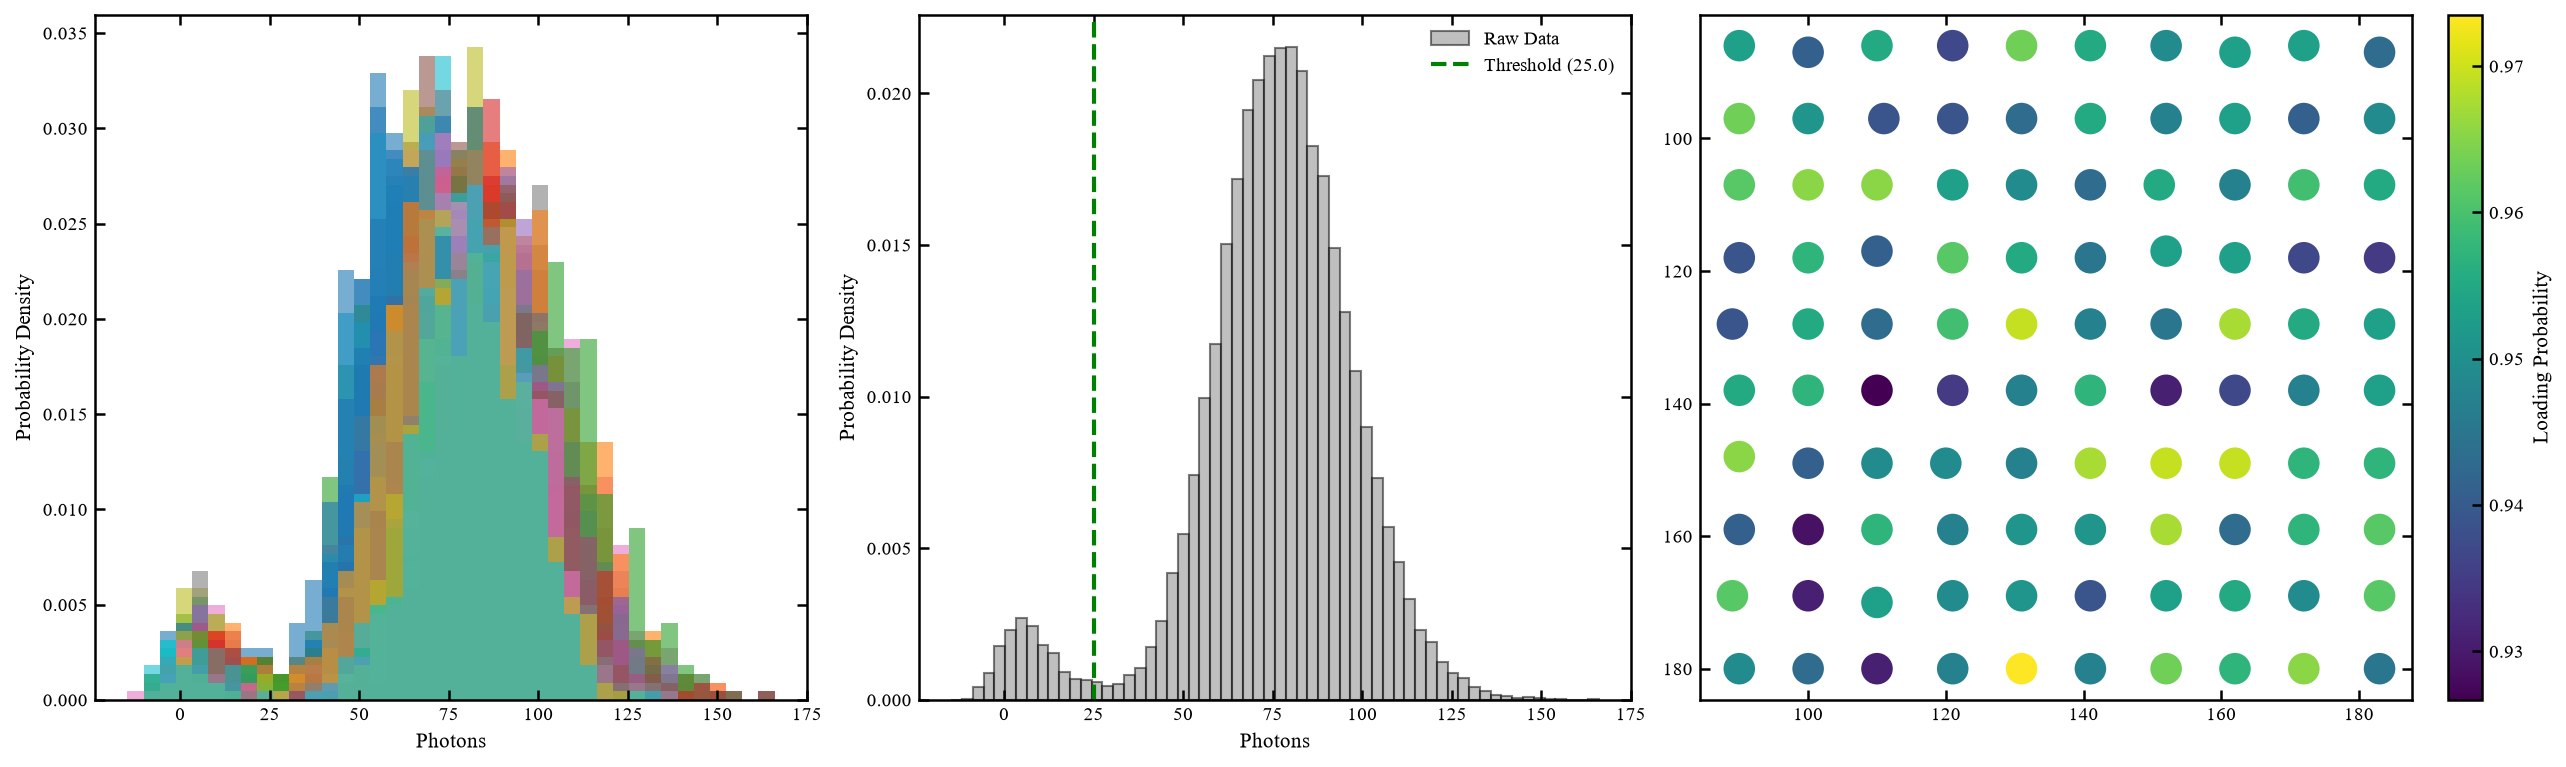

In [95]:
window, feature_size = 5, 10
n_atoms = 10*10
imgs_n_mean = imgs1.mean(axis=0)
imgs_n_mean_filtered = an.morphological_tophat_high_pass(imgs_n_mean, feature_size=feature_size)
grid_positions_2, detection_threshold = an.detect_trap_sites(imgs_n_mean_filtered, n_atoms, detection_step=50)
an.visualize_results(imgs_n_mean_filtered, grid_positions_2, margin=50, window_size=window, threshold=detection_threshold, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.7)
imgs_filtered = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
photon_rates_2, loading_probabilities, threshold_2, fidelity = an.get_array_loading_statistics(imgs_filtered, grid_positions_2, threshold_detection=False, threshold=25, window_size=window, binning=60)

Threshold detection failed: list index out of range. Trying default threshold of 1.00 kHz.
Trap (0) Loading Probability : 95.93 %
Trap (1) Loading Probability : 95.72 %
Trap (2) Loading Probability : 94.30 %
Trap (3) Loading Probability : 95.93 %
Trap (4) Loading Probability : 95.11 %
Trap (5) Loading Probability : 94.70 %
Trap (6) Loading Probability : 95.32 %
Trap (7) Loading Probability : 94.70 %
Trap (8) Loading Probability : 95.52 %
Trap (9) Loading Probability : 94.50 %
Trap (10) Loading Probability : 96.54 %
Trap (11) Loading Probability : 95.11 %
Trap (12) Loading Probability : 93.89 %
Trap (13) Loading Probability : 94.50 %
Trap (14) Loading Probability : 94.50 %
Trap (15) Loading Probability : 95.52 %
Trap (16) Loading Probability : 94.30 %
Trap (17) Loading Probability : 95.11 %
Trap (18) Loading Probability : 94.30 %
Trap (19) Loading Probability : 95.11 %
Trap (20) Loading Probability : 95.72 %
Trap (21) Loading Probability : 96.54 %
Trap (22) Loading Probability : 96.33 %

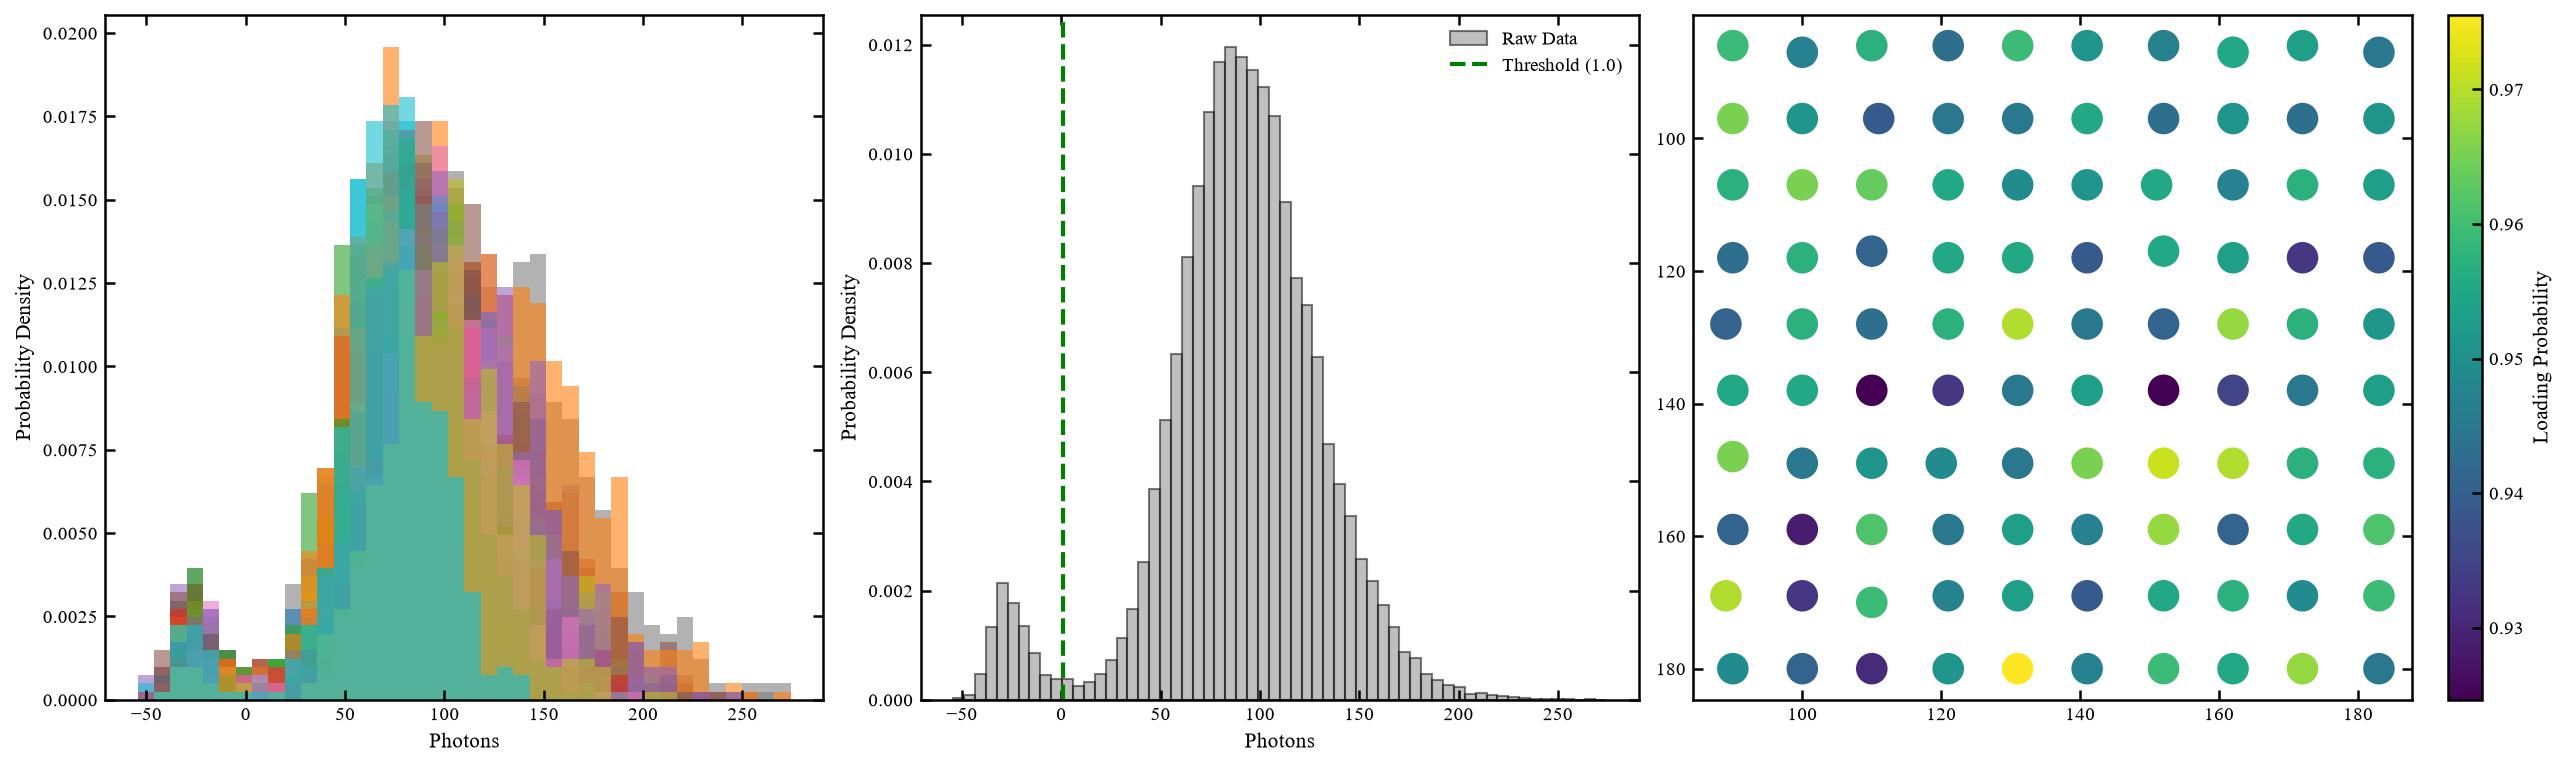

In [96]:
psf_window = 9

scorer = an.SiteScorer.from_images(imgs1, grid_positions_2, window_size=psf_window)
photons, loading_probabilities, threshold_1, fidelity = an.get_array_loading_statistics(imgs1, grid_positions_2, scorer=scorer, threshold_detection=True, binning=60)
scorer.threshold = threshold_1 * 1.0
print(f"PSF threshold {scorer.threshold:.2f} photons, detection fidelity {fidelity*100:.3f} %")

Text(0.5, 1.0, 'Initial Array Photon Statistics')

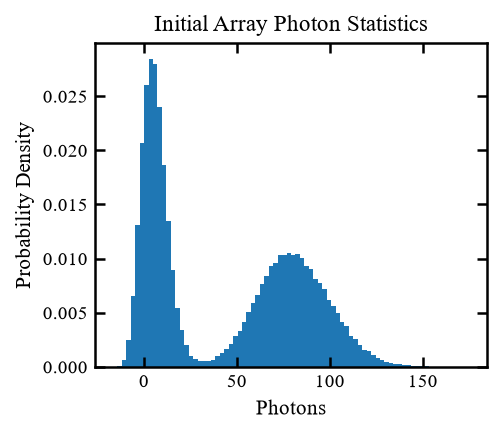

In [97]:
photons1 = photon_rates_1.flatten()

plt.hist(photons1, density=True, bins=80)
plt.xlabel('Photons')
plt.ylabel('Probability Density')
plt.title('Initial Array Photon Statistics')

Text(0.5, 1.0, 'Final Array Photon Statistics')

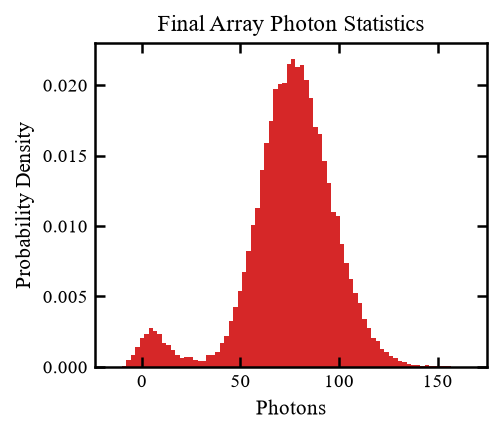

In [98]:
photons2 = photon_rates_2.flatten()

plt.hist(photons2, density=True, bins=80, color='C3')
plt.xlabel('Photons')
plt.ylabel('Probability Density')
plt.title('Final Array Photon Statistics')

---
## Rearrangement 12x12 -> 72Kagome

In [99]:
date = "21Aug26"
DataManager.list_datasets(date);
dataset = DataManager.load_dataset(date, "rearrangement_12x12square_72kagome")

Datasets found in C:\Users\tweez\Box\Working folder\caftweezers\Data\2026\Aug\21Aug26:
  - rearrangement_12x12square_72kagome/
  - rearrangement_15x15_10x10/
Loading dataset: rearrangement_12x12square_72kagome

--- Experimental Info ---

Dataset Title: rearrangement_12x12square_72kagome
Date: 2026-08-21 18:14:05

    50 ms time slot given for rearrangement.
    Rearrangement parameters: d0 = 0.5, threshold = 2322.5737 photons, profile = linear, window_size = 5, feature_size = 10.
    Occupancy extraction using the PSF method. Rearrangement from 12x12 square array to 72 site Kagome lattice. Using 50 ms images for final two, 5 ms images for initial.

----------------------------------------
Contents:
  Subdirectories:
    - 0_images/
    - 1_images/
    - 2_images/
  Files:
    - experiment_info.txt
    - timing_and_images.pkl
----------------------------------------


In [100]:
data_pkl = dataset.pickles.get('timing_and_images.pkl')
data_pkl.keys()
imgs0 = data_pkl['imgs0']
imgs1 = data_pkl['imgs1']

Looking for trap sites...
144 Atoms Detected.


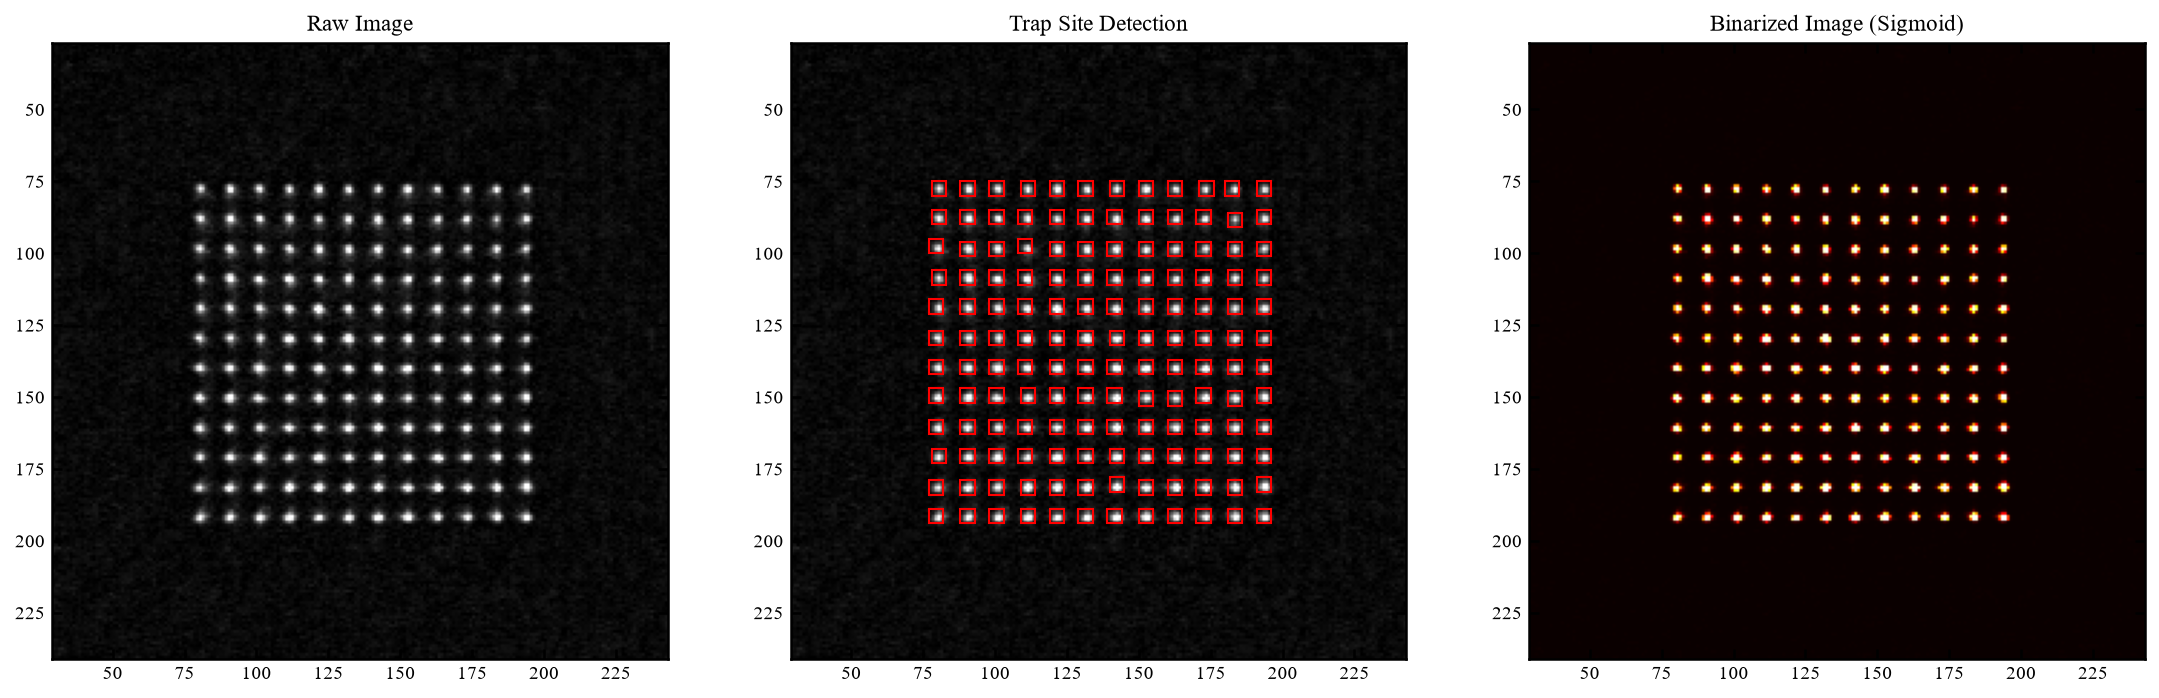

Trap (0) Loading Probability : 54.00 %
Trap (1) Loading Probability : 58.00 %
Trap (2) Loading Probability : 51.00 %
Trap (3) Loading Probability : 50.00 %
Trap (4) Loading Probability : 56.00 %
Trap (5) Loading Probability : 47.00 %
Trap (6) Loading Probability : 45.00 %
Trap (7) Loading Probability : 56.00 %
Trap (8) Loading Probability : 50.00 %
Trap (9) Loading Probability : 54.00 %
Trap (10) Loading Probability : 59.00 %
Trap (11) Loading Probability : 56.00 %
Trap (12) Loading Probability : 61.00 %
Trap (13) Loading Probability : 61.00 %
Trap (14) Loading Probability : 57.00 %
Trap (15) Loading Probability : 52.00 %
Trap (16) Loading Probability : 47.00 %
Trap (17) Loading Probability : 47.00 %
Trap (18) Loading Probability : 52.00 %
Trap (19) Loading Probability : 63.00 %
Trap (20) Loading Probability : 47.00 %
Trap (21) Loading Probability : 48.00 %
Trap (22) Loading Probability : 54.00 %
Trap (23) Loading Probability : 46.00 %
Trap (24) Loading Probability : 55.00 %
Trap (25) 

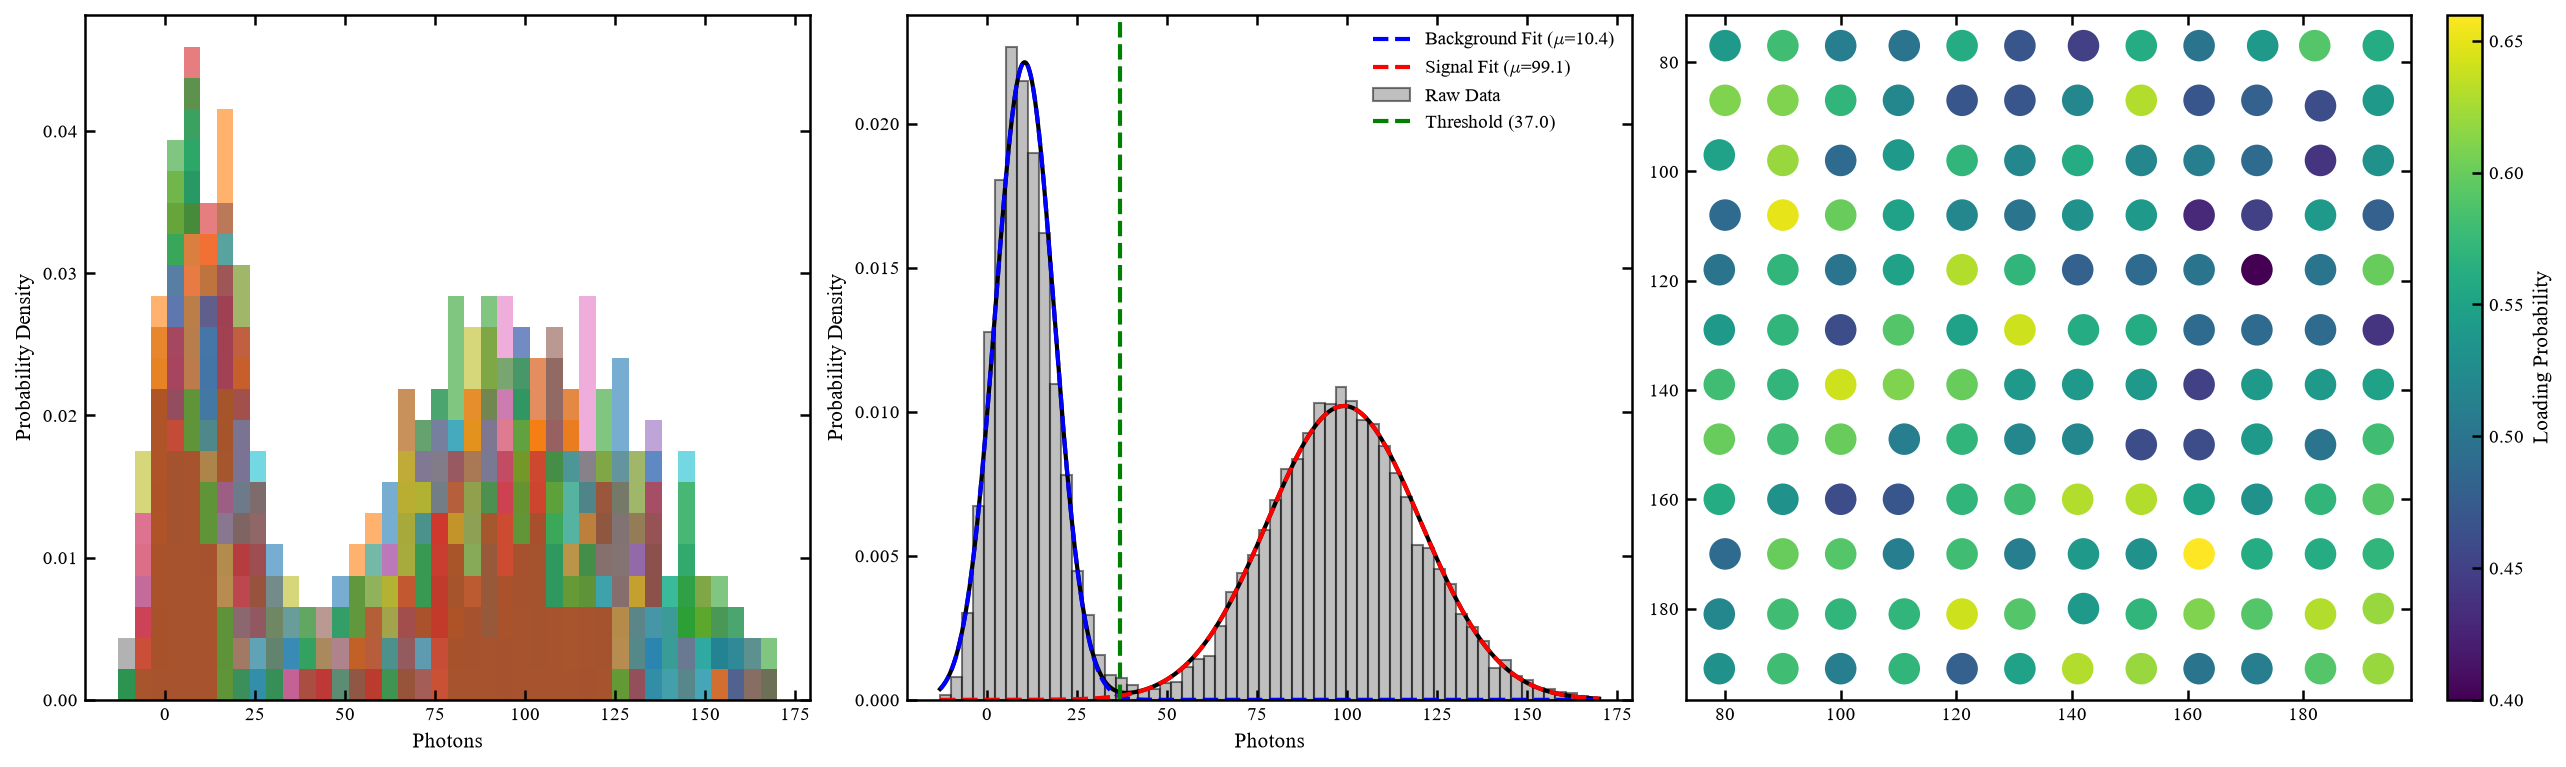

In [101]:
window, feature_size = 5, 10
n_atoms = 12*12
imgs_n_mean = imgs0.mean(axis=0)
imgs_n_mean_filtered = an.morphological_tophat_high_pass(imgs_n_mean, feature_size=feature_size)
grid_positions_1, detection_threshold = an.detect_trap_sites(imgs_n_mean_filtered, n_atoms, detection_step=50)
an.visualize_results(imgs_n_mean_filtered, grid_positions_1, margin=50, window_size=window, threshold=detection_threshold, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.7)
imgs_filtered = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs0]
photon_rates_1, loading_probabilities, threshold_2, fidelity = an.get_array_loading_statistics(imgs_filtered, grid_positions_1, threshold_detection=True, threshold=30, window_size=window, binning=60)

Trap (0) Loading Probability : 55.00 %
Trap (1) Loading Probability : 59.00 %
Trap (2) Loading Probability : 51.00 %
Trap (3) Loading Probability : 50.00 %
Trap (4) Loading Probability : 56.00 %
Trap (5) Loading Probability : 48.00 %
Trap (6) Loading Probability : 46.00 %
Trap (7) Loading Probability : 55.00 %
Trap (8) Loading Probability : 50.00 %
Trap (9) Loading Probability : 55.00 %
Trap (10) Loading Probability : 59.00 %
Trap (11) Loading Probability : 56.00 %
Trap (12) Loading Probability : 61.00 %
Trap (13) Loading Probability : 60.00 %
Trap (14) Loading Probability : 58.00 %
Trap (15) Loading Probability : 52.00 %
Trap (16) Loading Probability : 47.00 %
Trap (17) Loading Probability : 47.00 %
Trap (18) Loading Probability : 52.00 %
Trap (19) Loading Probability : 63.00 %
Trap (20) Loading Probability : 47.00 %
Trap (21) Loading Probability : 48.00 %
Trap (22) Loading Probability : 55.00 %
Trap (23) Loading Probability : 46.00 %
Trap (24) Loading Probability : 55.00 %
Trap (25) 

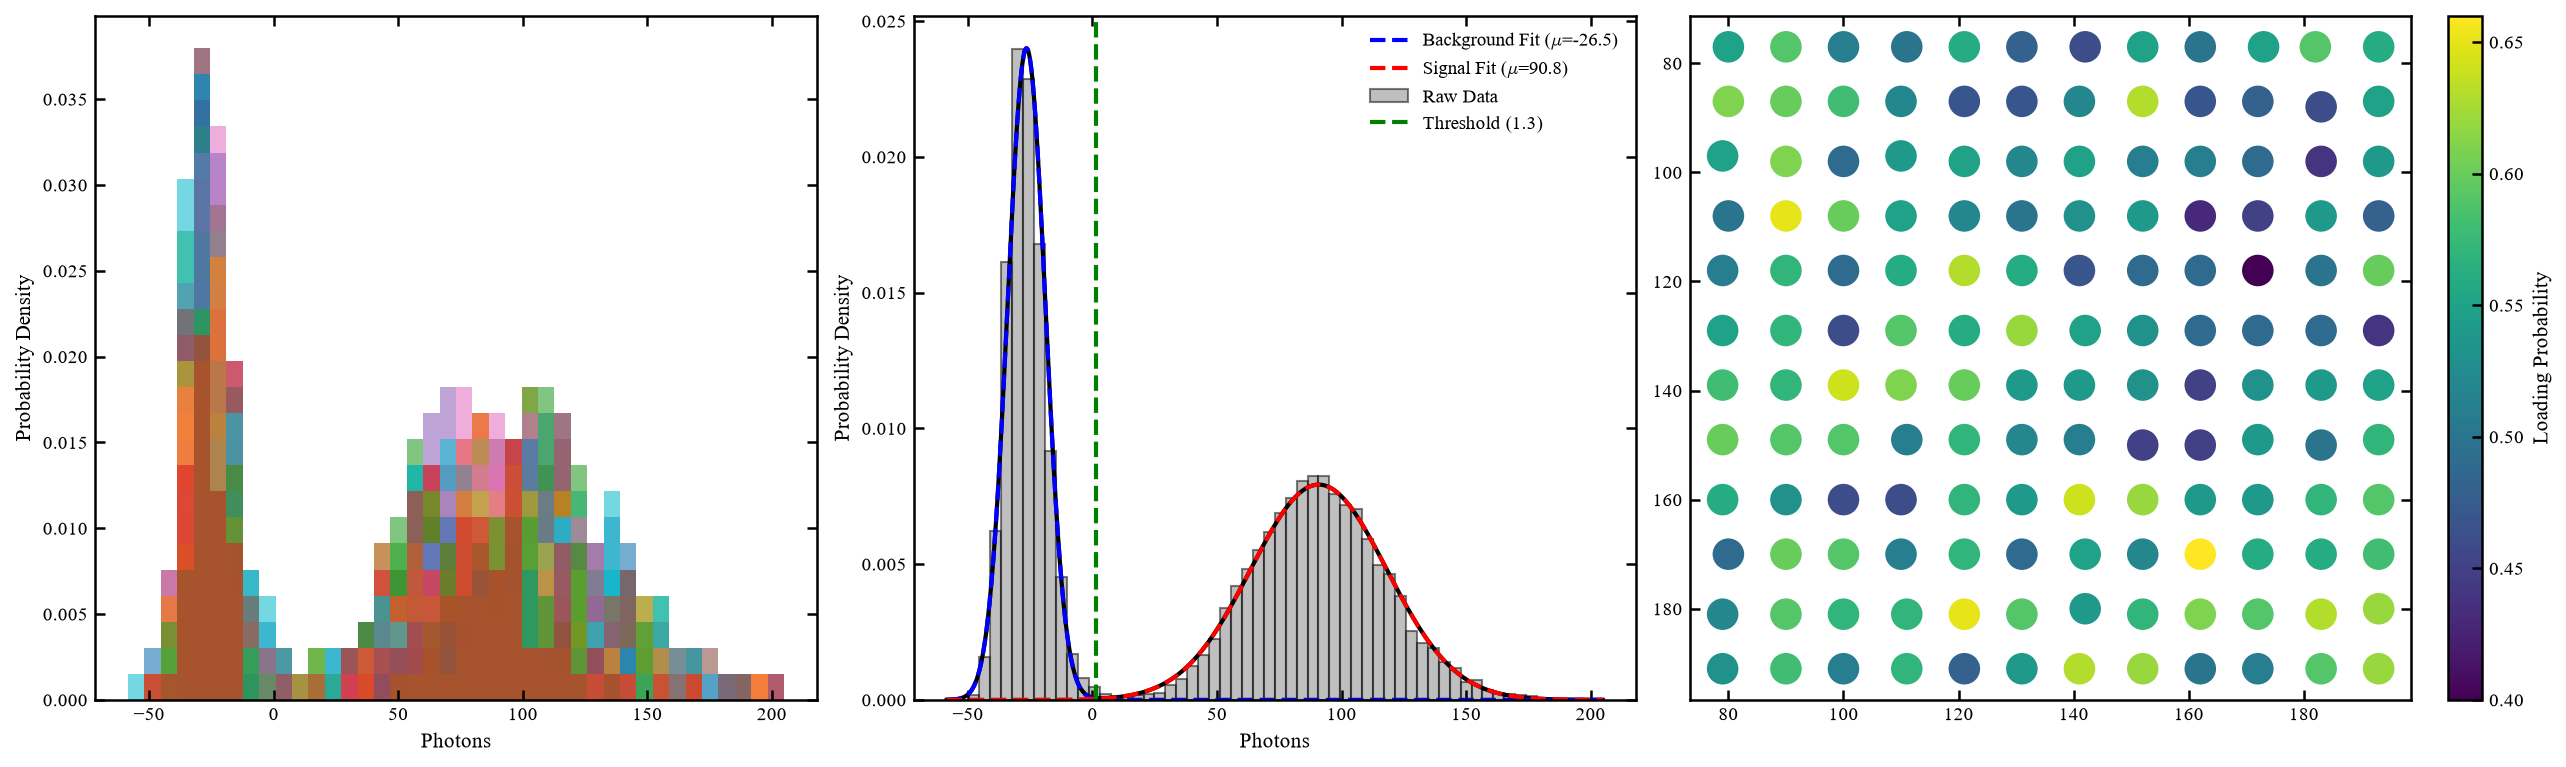

In [102]:
psf_window = 9

scorer = an.SiteScorer.from_images(imgs0, grid_positions_1, window_size=psf_window)
photons, loading_probabilities, threshold_1, fidelity = an.get_array_loading_statistics(imgs0, grid_positions_1, scorer=scorer, threshold_detection=True, binning=60)
scorer.threshold = threshold_1 * 1.0
print(f"PSF threshold {scorer.threshold:.2f} photons, detection fidelity {fidelity*100:.3f} %")

Looking for trap sites...
72 Atoms Detected.


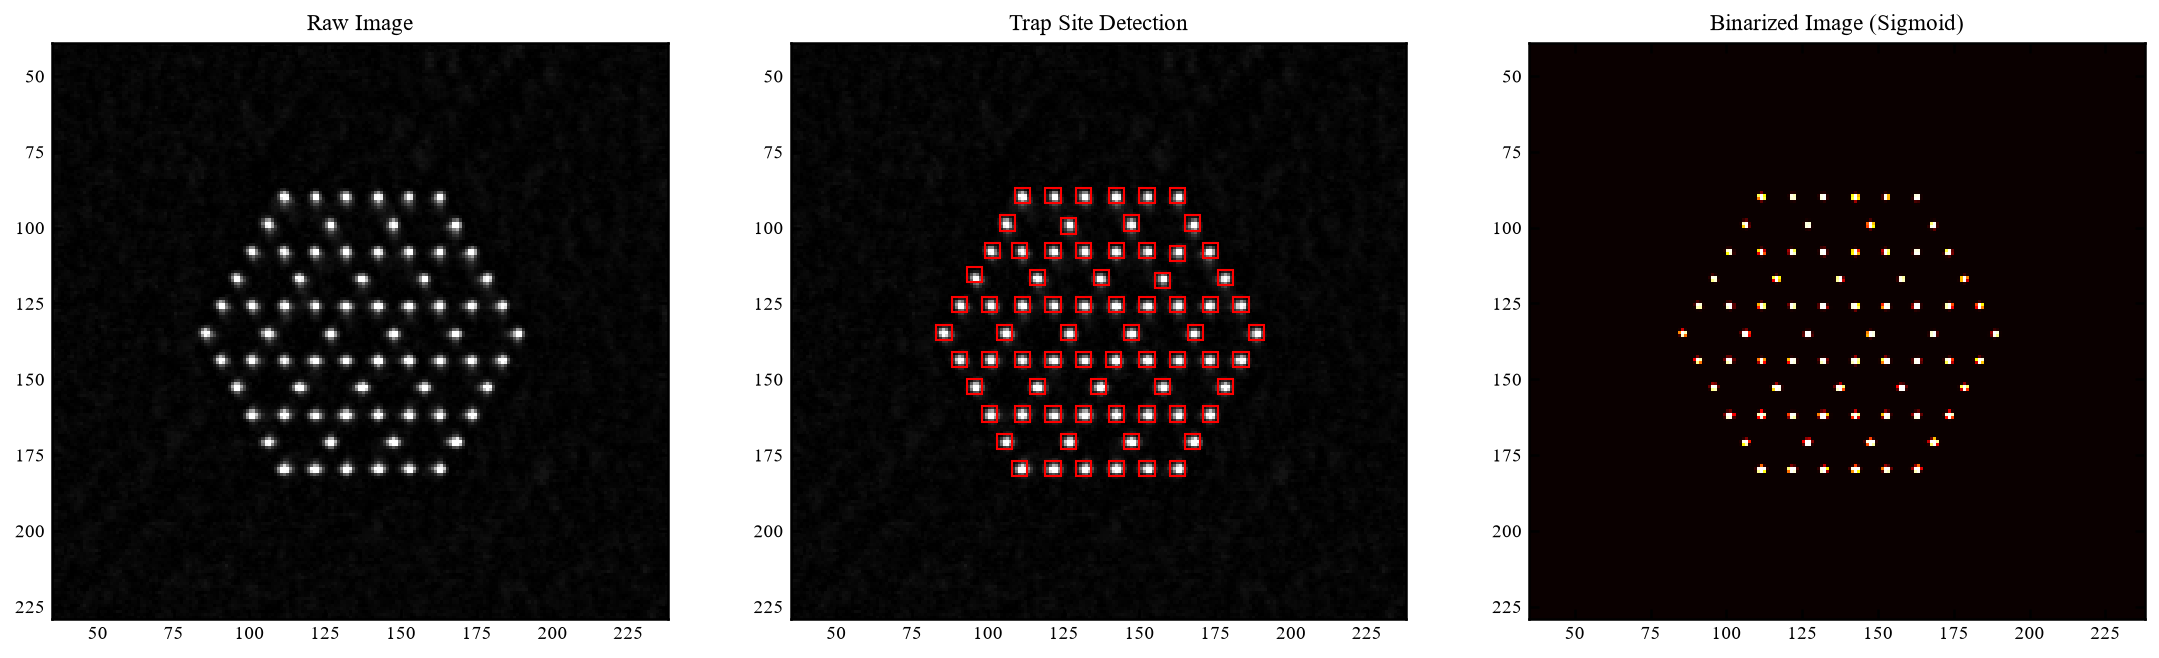

Trap (0) Loading Probability : 92.00 %
Trap (1) Loading Probability : 86.00 %
Trap (2) Loading Probability : 88.00 %
Trap (3) Loading Probability : 91.00 %
Trap (4) Loading Probability : 81.00 %
Trap (5) Loading Probability : 87.00 %
Trap (6) Loading Probability : 83.00 %
Trap (7) Loading Probability : 89.00 %
Trap (8) Loading Probability : 94.00 %
Trap (9) Loading Probability : 85.00 %
Trap (10) Loading Probability : 85.00 %
Trap (11) Loading Probability : 82.00 %
Trap (12) Loading Probability : 90.00 %
Trap (13) Loading Probability : 89.00 %
Trap (14) Loading Probability : 93.00 %
Trap (15) Loading Probability : 83.00 %
Trap (16) Loading Probability : 89.00 %
Trap (17) Loading Probability : 88.00 %
Trap (18) Loading Probability : 91.00 %
Trap (19) Loading Probability : 88.00 %
Trap (20) Loading Probability : 90.00 %
Trap (21) Loading Probability : 88.00 %
Trap (22) Loading Probability : 81.00 %
Trap (23) Loading Probability : 92.00 %
Trap (24) Loading Probability : 91.00 %
Trap (25) 

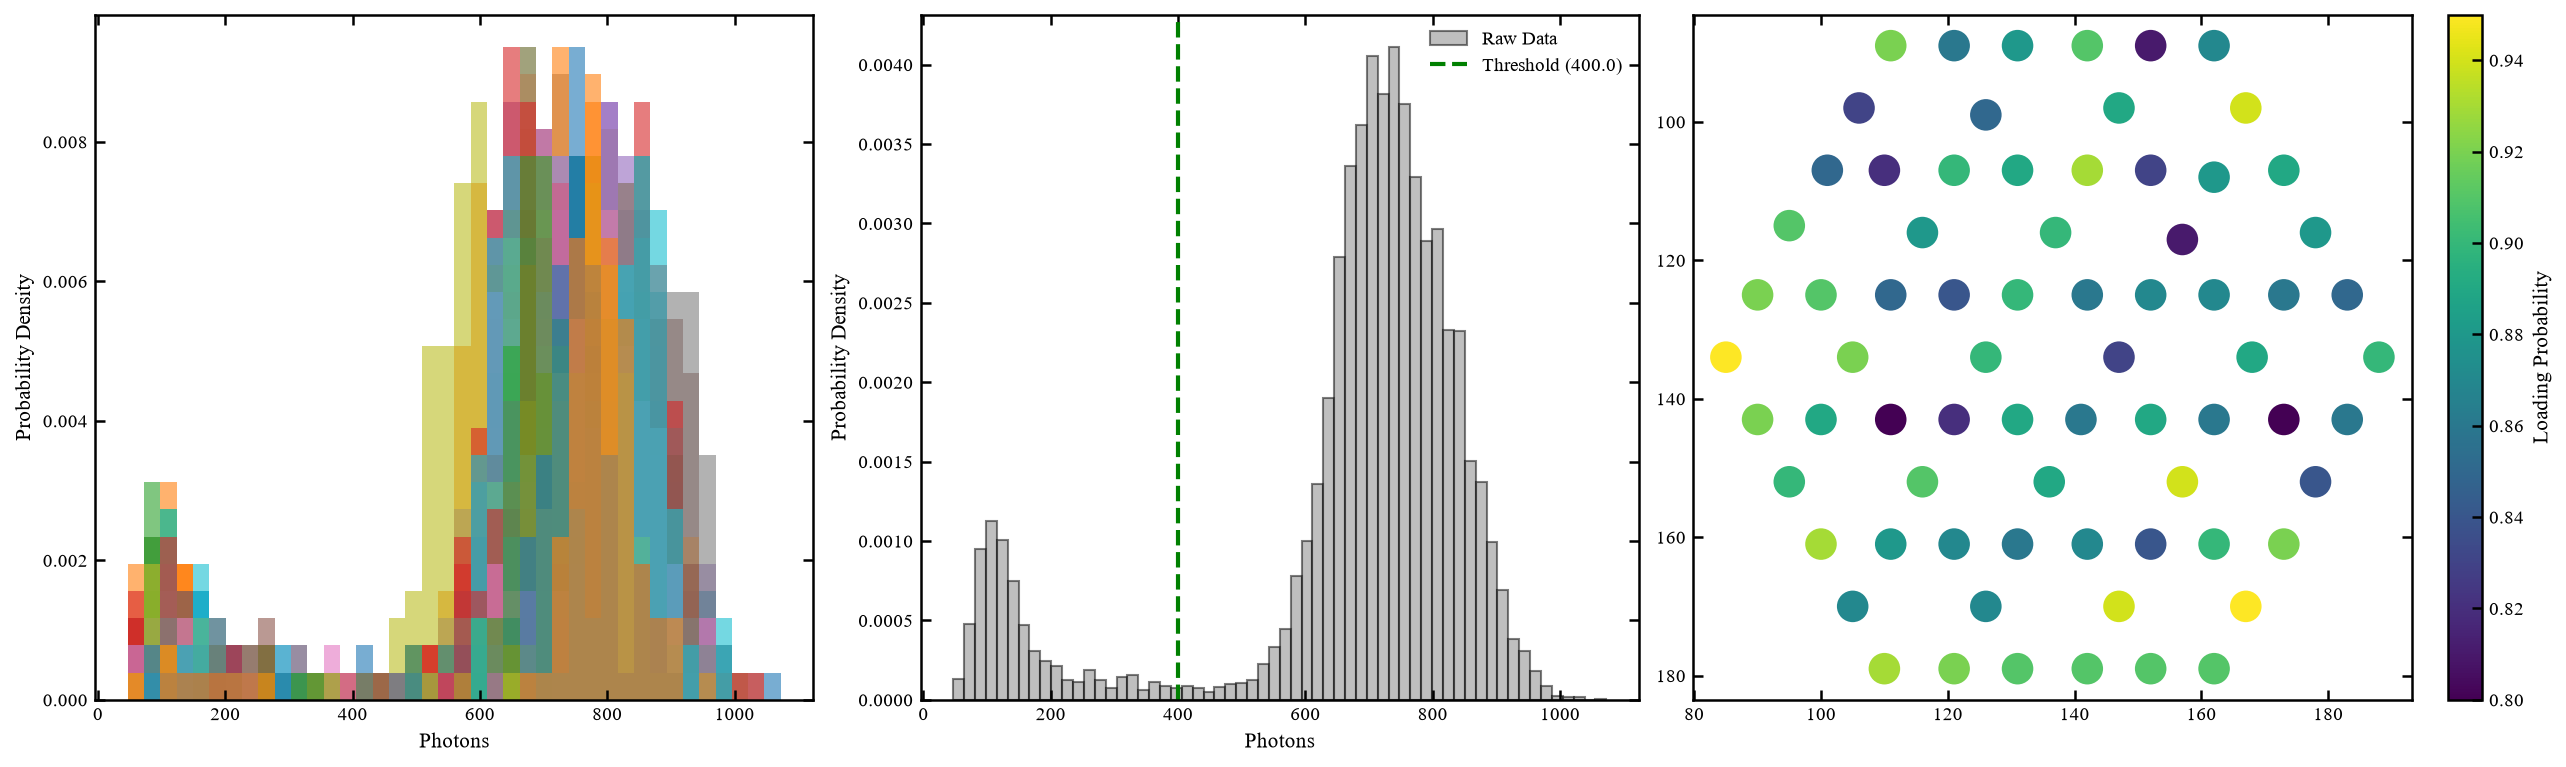

In [ ]:
window, feature_size = 5, 10
n_atoms = 72
imgs_n_mean = imgs1.mean(axis=0)
imgs_n_mean_filtered = an.morphological_tophat_high_pass(imgs_n_mean, feature_size=feature_size)
grid_positions_2, detection_threshold = an.detect_trap_sites(imgs_n_mean_filtered, n_atoms, detection_step=50)
an.visualize_results(imgs_n_mean_filtered, grid_positions_2, margin=50, window_size=window, threshold=detection_threshold, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.7)
imgs_filtered = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
photon_rates_2, loading_probabilities, threshold_2, fidelity = an.get_array_loading_statistics(imgs_filtered, grid_positions_2, threshold_detection=False, threshold=400, window_size=window, binning=60)

21 site(s) used the mean template: [0, 3, 8, 12, 14, 18, 23, 24, 33, 34, 39, 54, 61, 64, 65, 66, 67, 68, 69, 70, 71]
Trap (0) Loading Probability : 92.00 %
Trap (1) Loading Probability : 86.00 %
Trap (2) Loading Probability : 85.00 %
Trap (3) Loading Probability : 91.00 %
Trap (4) Loading Probability : 81.00 %
Trap (5) Loading Probability : 86.00 %
Trap (6) Loading Probability : 83.00 %
Trap (7) Loading Probability : 88.00 %
Trap (8) Loading Probability : 94.00 %
Trap (9) Loading Probability : 84.00 %
Trap (10) Loading Probability : 85.00 %
Trap (11) Loading Probability : 81.00 %
Trap (12) Loading Probability : 90.00 %
Trap (13) Loading Probability : 89.00 %
Trap (14) Loading Probability : 93.00 %
Trap (15) Loading Probability : 83.00 %
Trap (16) Loading Probability : 89.00 %
Trap (17) Loading Probability : 88.00 %
Trap (18) Loading Probability : 75.00 %
Trap (19) Loading Probability : 87.00 %
Trap (20) Loading Probability : 88.00 %
Trap (21) Loading Probability : 88.00 %
Trap (22) Loa

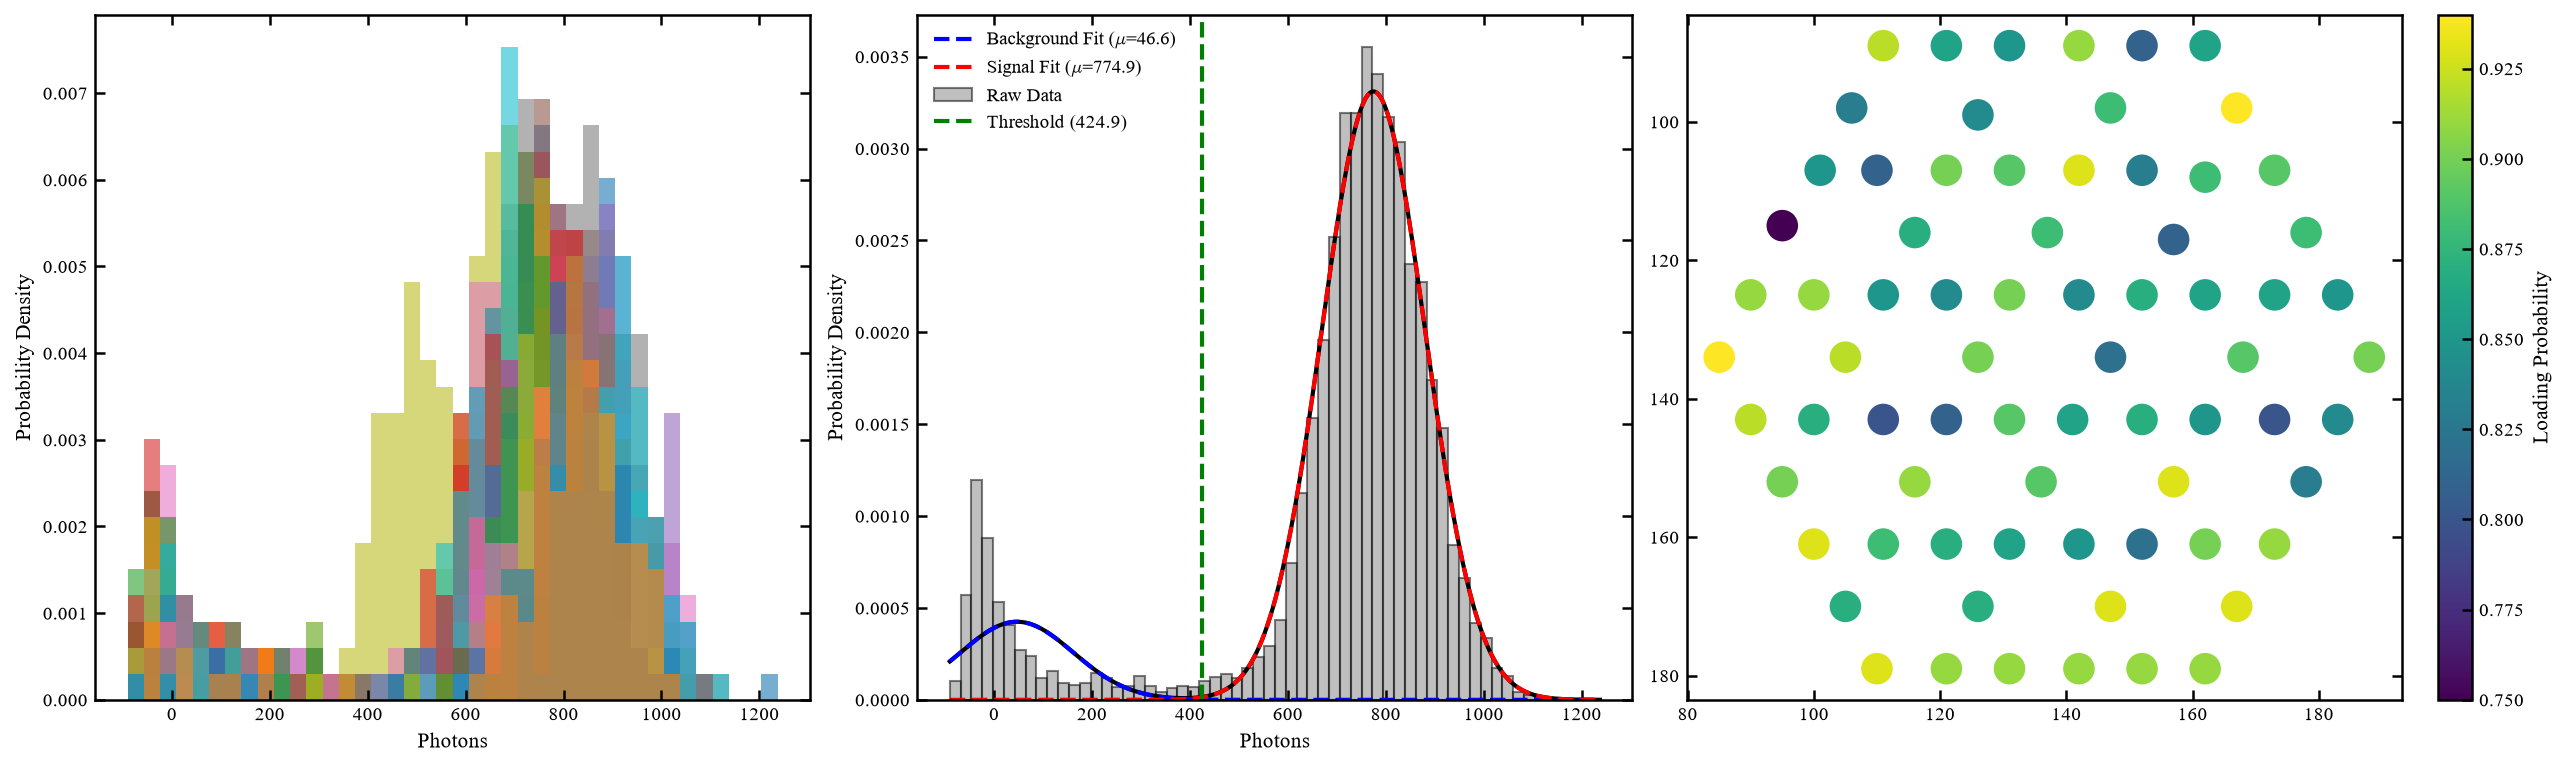

In [105]:
psf_window = 9

scorer = an.SiteScorer.from_images(imgs1, grid_positions_2, window_size=psf_window)
photons, loading_probabilities, threshold_1, fidelity = an.get_array_loading_statistics(imgs1, grid_positions_2, scorer=scorer, threshold_detection=True, binning=60)
scorer.threshold = threshold_1 * 1.0
print(f"PSF threshold {scorer.threshold:.2f} photons, detection fidelity {fidelity*100:.3f} %")

Text(0.5, 1.0, 'Initial Array Photon Statistics')

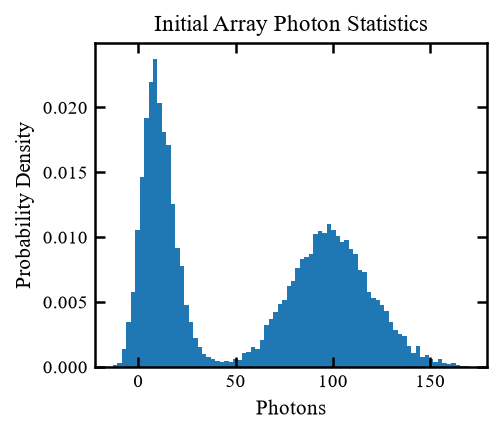

In [106]:
photons1 = photon_rates_1.flatten()

plt.hist(photons1, density=True, bins=80)
plt.xlabel('Photons')
plt.ylabel('Probability Density')
plt.title('Initial Array Photon Statistics')

Text(0.5, 1.0, 'Final Array Photon Statistics')

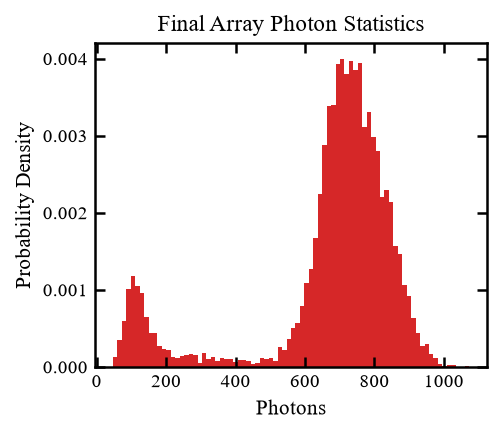

In [107]:
photons2 = photon_rates_2.flatten()

plt.hist(photons2, density=True, bins=80, color='C3')
plt.xlabel('Photons')
plt.ylabel('Probability Density')
plt.title('Final Array Photon Statistics')

---
## Trap Frequency Measurement

In [356]:
date = "20Aug26"
DataManager.list_datasets(date);

Datasets found in C:\Users\tweez\Box\Working folder\caftweezers\Data\2026\Aug\20Aug26:
  - final_7x7_array_temperature_measurement/
  - final_7x7_array_trap_frequency_measurement/
  - initial_10x10_array_temperature_measurement/
  - initial_10x10_array_trap_frequency_measurement/


In [357]:
dataset = DataManager.load_dataset(date, "final_7x7_array_trap_frequency_measurement")

Loading dataset: final_7x7_array_trap_frequency_measurement

--- Experimental Info ---

Dataset Title: final_7x7_array_trap_frequency_measurement
Date: 2026-08-20 18:23:04

    Trap frequency measurement of the final 7x7 array after rearrangement, scanning a modulation frequency range from 10 kHz to 300 kHz. Modulation duration used is 20ms.

----------------------------------------
Contents:
  Files:
    - experiment_info.txt
    - trap_frequency_data.pkl
----------------------------------------


In [358]:
data = dataset.pickles.get('trap_frequency_data.pkl')
data.keys()

dict_keys(['surv_array', 'modflist'])

In [359]:
surv_array = data['surv_array']
modflist = data['modflist']


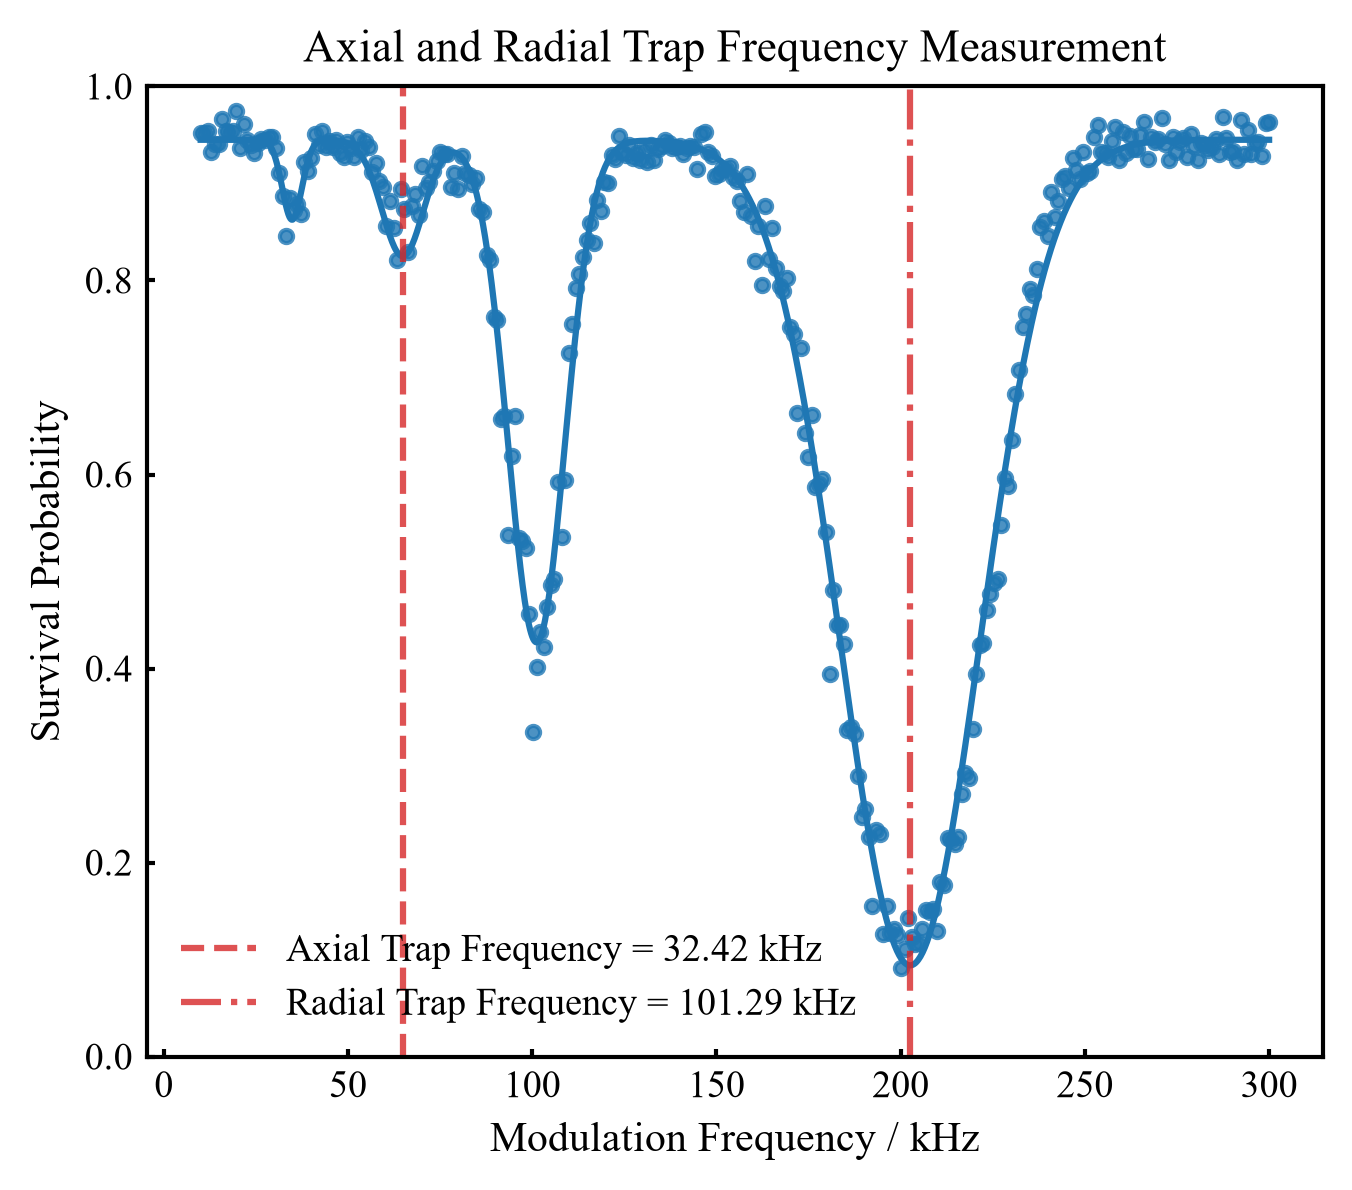

In [363]:


# Fit 4 gaussian dips to this data to extract the trap frequency
def single_dip_gaussian(x, A, mu, sigma, offset):
    return A * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2)) + offset

def four_dip_gaussian(x, A1, mu1, sigma1, A2, mu2, sigma2, A3, mu3, sigma3, A4, mu4, sigma4, offset):
    return (single_dip_gaussian(x, A1, mu1, sigma1, 0) +
            single_dip_gaussian(x, A2, mu2, sigma2, 0) +
            single_dip_gaussian(x, A3, mu3, sigma3, 0) +
            single_dip_gaussian(x, A4, mu4, sigma4, 0) + offset)

popt, pcov = curve_fit(four_dip_gaussian, modflist, surv_array, p0=[-0.1, 30, 10, -0.2, 60, 10, -0.6, 100, 10, -0.8, 200, 50, 0.5])

popt[0]=-0.12
xfit = np.linspace(modflist.min(), modflist.max(), 1000)
yfit = four_dip_gaussian(xfit, *popt)

plt.scatter(modflist, surv_array, color="C0", alpha=0.8, s=10)
plt.plot(xfit, yfit, color='C0')
plt.xlabel("Modulation Frequency / kHz")
plt.ylabel("Survival Probability")
plt.title("Axial and Radial Trap Frequency Measurement")


plt.vlines([popt[1]], 0, 1, linestyle='--', color='C3', alpha=0.8, label='Axial Trap Frequency = 32.42 kHz')
plt.vlines([popt[10]], 0, 1, linestyle='-.', color='C3', alpha=0.8, label='Radial Trap Frequency = 101.29 kHz')
plt.legend()
plt.ylim(0.0, 1.0)
popt[10]/2

plt.savefig("Images\\trap_freq.png", bbox_inches='tight')

## Temperature Measurement

In [350]:
date = "20Aug26"
DataManager.list_datasets(date);

Datasets found in C:\Users\tweez\Box\Working folder\caftweezers\Data\2026\Aug\20Aug26:
  - final_7x7_array_temperature_measurement/
  - final_7x7_array_trap_frequency_measurement/
  - initial_10x10_array_temperature_measurement/
  - initial_10x10_array_trap_frequency_measurement/


In [351]:
init_dataset = DataManager.load_dataset(date, "initial_10x10_array_temperature_measurement")
final_dataset = DataManager.load_dataset(date, "final_7x7_array_temperature_measurement")

Loading dataset: initial_10x10_array_temperature_measurement

--- Experimental Info ---

Dataset Title: initial_10x10_array_temperature_measurement
Date: 2026-08-20 19:06:43

    Temperature measurement of the initial 10x10 array after rearrangement, scanning a drop duration range from 10 us to 200 us. The extracted temperature is 9.24 uK.
    The trap frequency measurement was used to calibrate the trap depth for the temperature extraction. The recapture probability was fitted to a Maxwell-Boltzmann distribution to extract the temperature.

----------------------------------------
Contents:
  Files:
    - experiment_info.txt
    - temperature_data.pkl
----------------------------------------
Loading dataset: final_7x7_array_temperature_measurement

--- Experimental Info ---

Dataset Title: final_7x7_array_temperature_measurement
Date: 2026-08-20 18:42:05

    Temperature measurement of the final 7x7 array after rearrangement, scanning a drop duration range from 10 us to 200 us. The ex

In [352]:
init_data = init_dataset.pickles.get('temperature_data.pkl')
final_data = final_dataset.pickles.get('temperature_data.pkl')

x1, y1 = init_data['drop_durations'], init_data['surv_array']
x2, y2 = final_data['drop_durations'], final_data['surv_array']

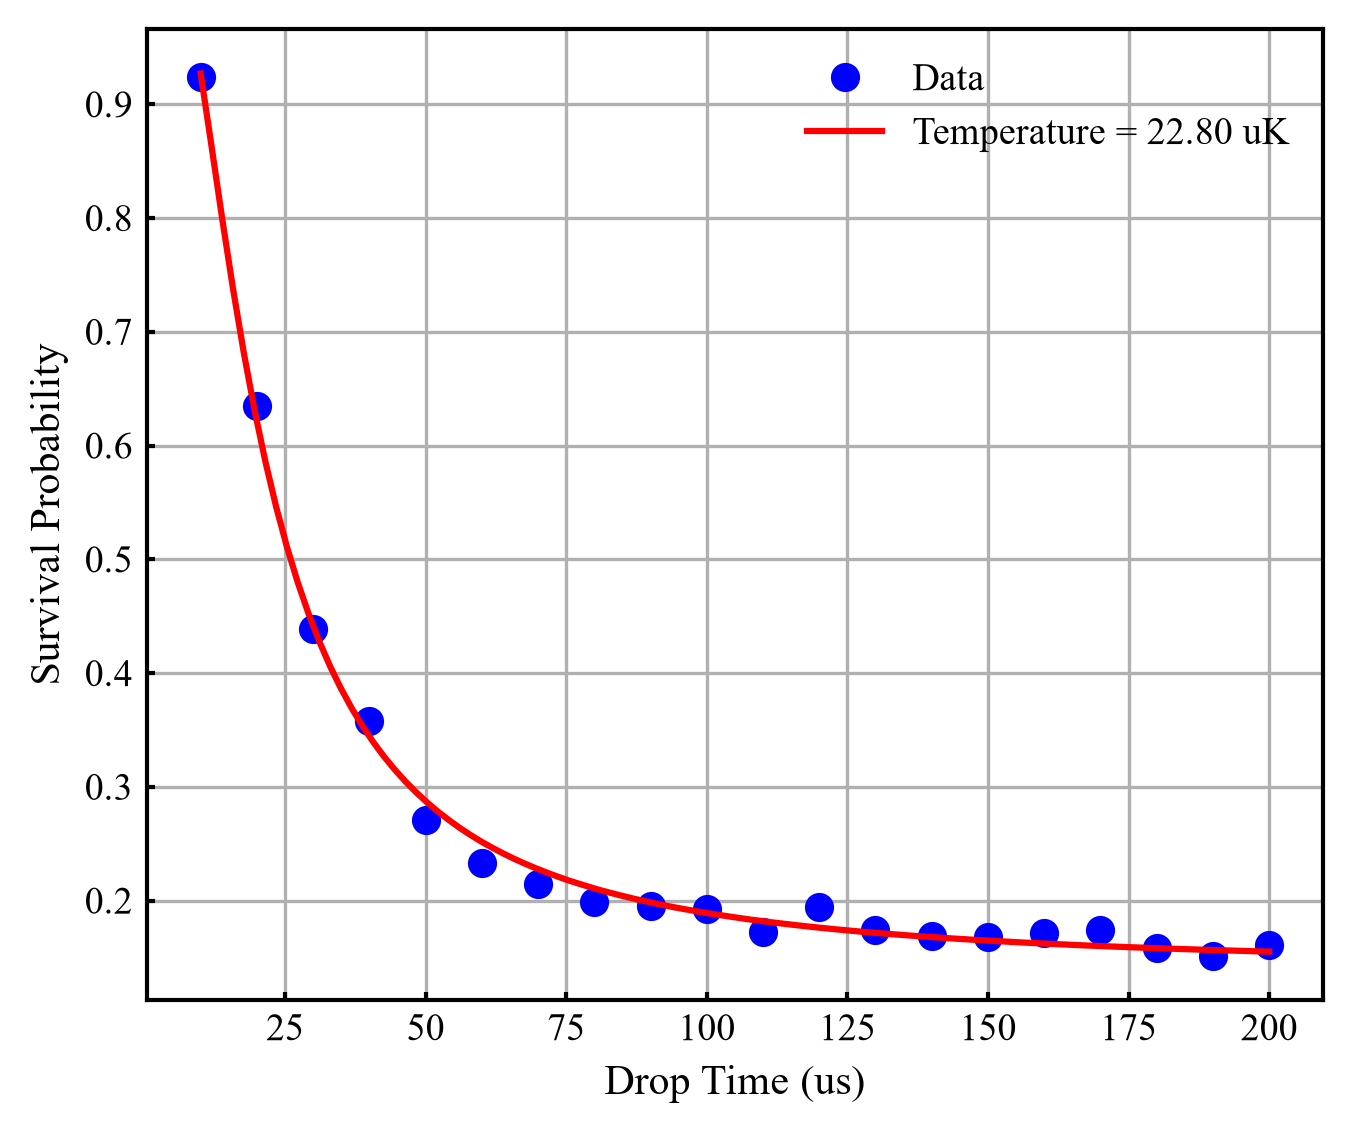

Extracted Temperature = 22.80 uK


In [353]:
from scipy import integrate

kB = 1.38e-23
hbar = 1.05e-34
mRb = 1.443e-25

wr = 2 * np.pi * 68e3
w0 = 0.922e-6
U0 = 1/4 * wr**2 * mRb * w0**2

def recapture_prob_fit(tarray, T, a, b):
    probs = []
    for t in tarray:
        escape_v_ineq = lambda ve, t: 0.5 * mRb * ve**2 - U0 * np.exp(- 2 * ve**2 * t**2 / w0**2)
        maxwell_p = lambda v, T: (mRb*v)/(kB*T) * np.exp(-mRb*v**2 / (2*kB*T))
        xx = np.linspace(0, 1, 100000)
        y = escape_v_ineq(xx, t)
        ve = xx[np.argmin(np.abs(y))]
        prob = integrate.quad(maxwell_p, 0, ve, args=(T))[0]
        probs.append(prob)
    return a * np.array(probs) + b

dropt = x1*10*1e-6
survival_prob_list = y1
survival_prob_list = survival_prob_list[~np.isnan(survival_prob_list)]
dropt = dropt[~np.isnan(survival_prob_list)]

params, pcov = curve_fit(recapture_prob_fit, dropt, survival_prob_list, p0 = [10e-6, 1.5, 0.1])
temperature = params[0] * 1e6

xfit1 = np.linspace(dropt.min(), dropt.max(), 100)
yfit1 = recapture_prob_fit(xfit1, temperature*1e-6, params[1], params[2])
plt.figure()
plt.plot(dropt*1e6, survival_prob_list, 'o', label='Data', color='blue')
plt.plot(xfit1*1e6, yfit1, '-', color='red', label=f'Temperature = {temperature:.2f} uK')
plt.grid()
plt.xlabel('Drop Time (us)')
plt.ylabel('Survival Probability')
plt.legend()
plt.show()

print(f"Extracted Temperature = {temperature:.2f} uK")

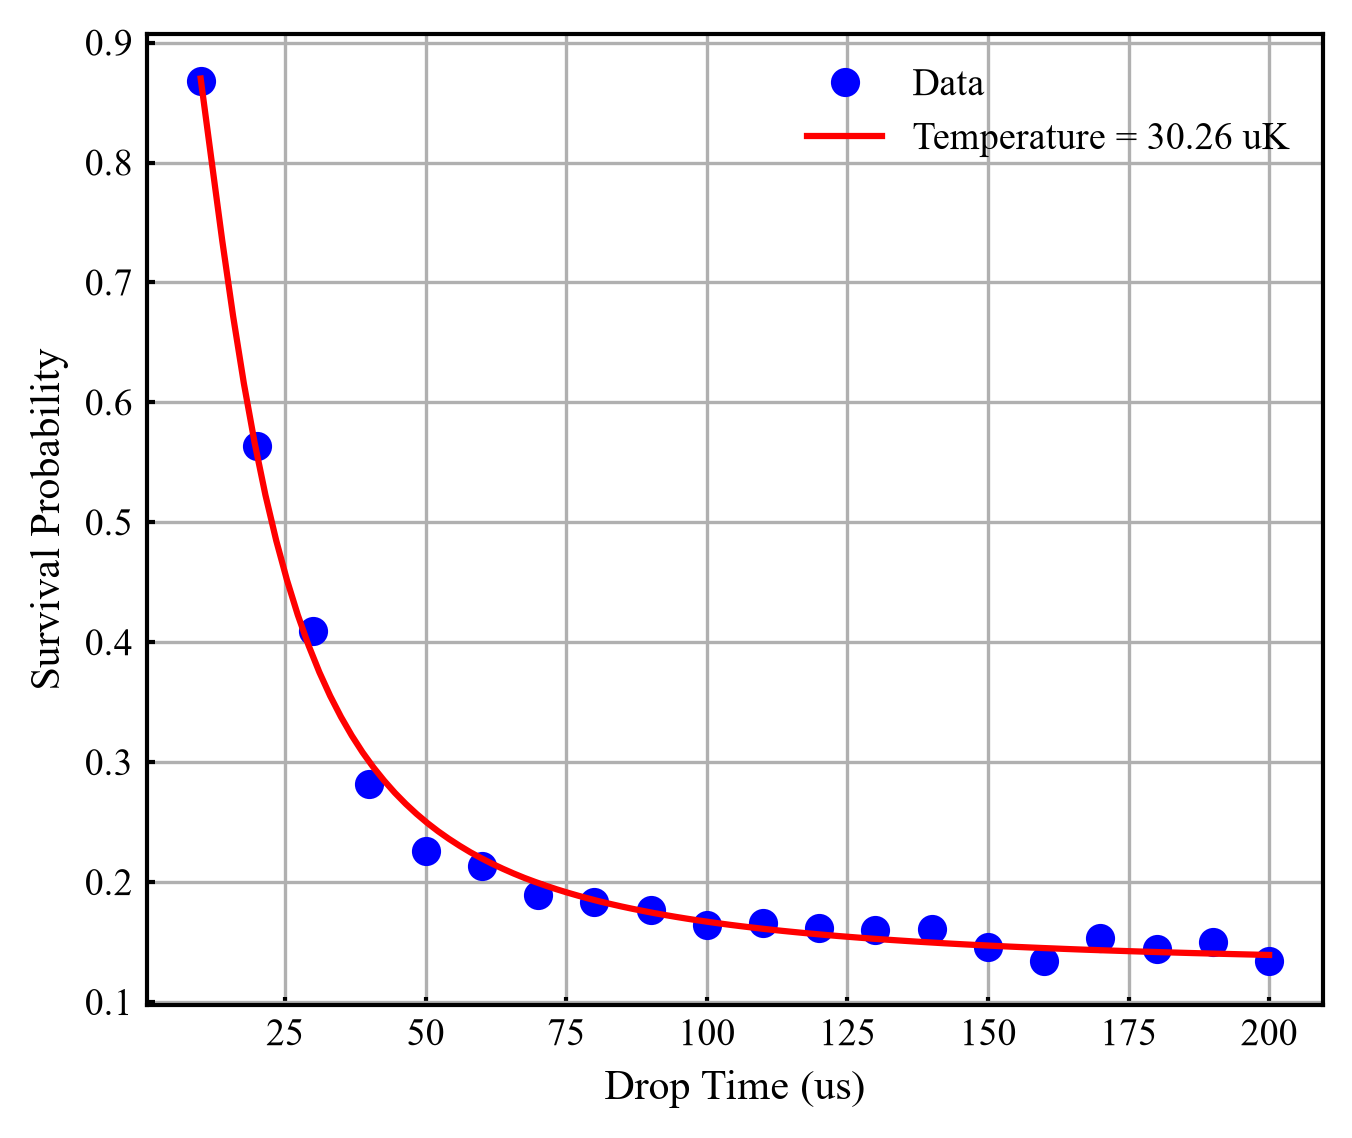

Extracted Temperature = 30.26 uK


In [354]:
from scipy import integrate

kB = 1.38e-23
hbar = 1.05e-34
mRb = 1.443e-25

wr = 2 * np.pi * 101.285e3
w0 = 0.922e-6
U0 = 1/4 * wr**2 * mRb * w0**2

def recapture_prob_fit(tarray, T, a, b):
    probs = []
    for t in tarray:
        escape_v_ineq = lambda ve, t: 0.5 * mRb * ve**2 - U0 * np.exp(- 2 * ve**2 * t**2 / w0**2)
        maxwell_p = lambda v, T: (mRb*v)/(kB*T) * np.exp(-mRb*v**2 / (2*kB*T))
        xx = np.linspace(0, 1, 100000)
        y = escape_v_ineq(xx, t)
        ve = xx[np.argmin(np.abs(y))]
        prob = integrate.quad(maxwell_p, 0, ve, args=(T))[0]
        probs.append(prob)
    return a * np.array(probs) + b

dropt = x2*10*1e-6
survival_prob_list = y2
survival_prob_list = survival_prob_list[~np.isnan(survival_prob_list)]
dropt = dropt[~np.isnan(survival_prob_list)]

params, pcov = curve_fit(recapture_prob_fit, dropt, survival_prob_list, p0 = [10e-6, 1.5, 0.1])
temperature = params[0] * 1e6

xfit2 = np.linspace(dropt.min(), dropt.max(), 100)
yfit2 = recapture_prob_fit(xfit2, temperature*1e-6, params[1], params[2])
plt.figure()
plt.plot(dropt*1e6, survival_prob_list, 'o', label='Data', color='blue')
plt.plot(xfit2*1e6, yfit2, '-', color='red', label=f'Temperature = {temperature:.2f} uK')
plt.grid()
plt.xlabel('Drop Time (us)')
plt.ylabel('Survival Probability')
plt.legend()
plt.show()

print(f"Extracted Temperature = {temperature:.2f} uK")

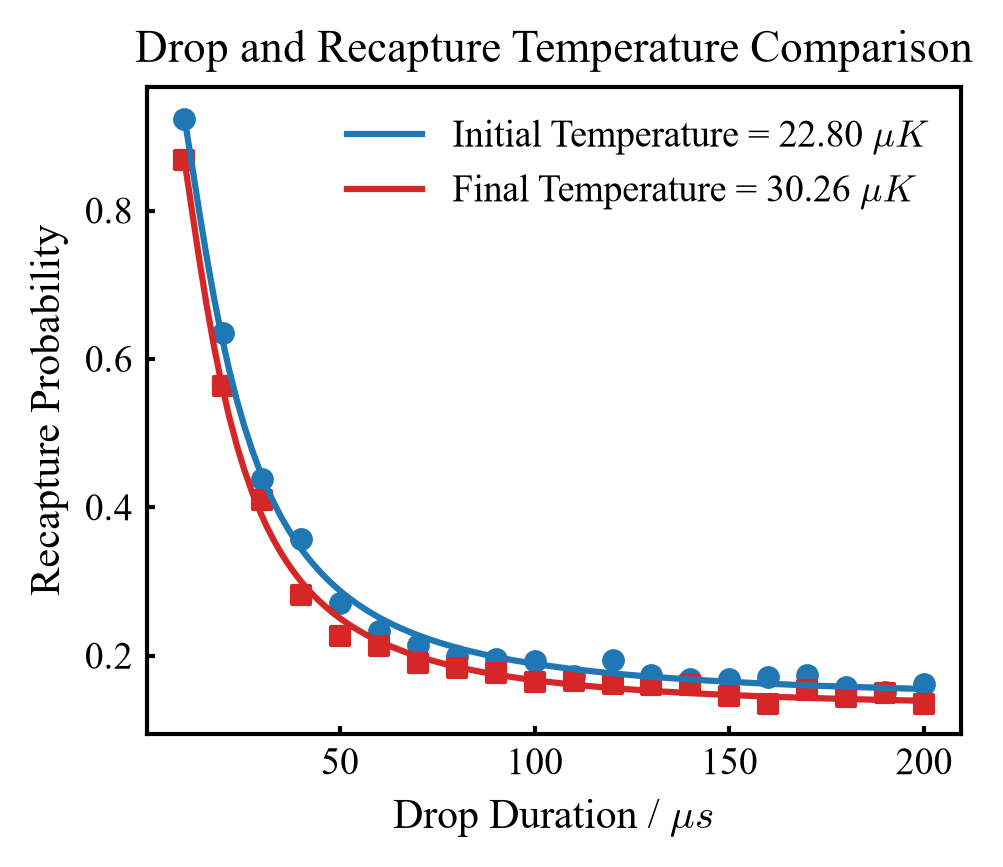

In [355]:
plt.figure(figsize=(3.5, 2.8))

plt.scatter(x1*10, y1, color='C0', s=20)
plt.plot(xfit1*1e6, yfit1, color='C0', label=f"Initial Temperature = 22.80 $\mu K$")

plt.scatter(x2*10, y2, color='C3', s=20, marker='s')
plt.plot(xfit2*1e6, yfit2, color='C3', label=f"Final Temperature = 30.26 $\mu K$")

plt.legend()
plt.xlabel('Drop Duration / $\mu s$')
plt.ylabel('Recapture Probability')
plt.title("Drop and Recapture Temperature Comparison")
plt.savefig("Images\\heating.png", bbox_inches='tight')

---
## Scaling

In [318]:
date = "12Aug26"
DataManager.list_datasets(date);
dataset = DataManager.load_dataset(date, "rearrangement_step_size_scans")

Datasets found in C:\Users\tweez\Box\Working folder\caftweezers\Data\2026\Aug\12Aug26:
  - imaging_survival_40ms/
  - imaging_survival_50ms/
  - rearrangement_10x10_7x7/
  - rearrangement_step_size_scans/
Loading dataset: rearrangement_step_size_scans
Contents:
  Subdirectories:
    - rearrangement_d0_0.50/
    - rearrangement_d0_0.67/
    - rearrangement_d0_0.83/
    - rearrangement_d0_1.00/
    - rearrangement_d0_1.17/
    - rearrangement_d0_1.33/
    - rearrangement_d0_1.50/
    - rearrangement_d0_1.67/
    - rearrangement_d0_1.83/
    - rearrangement_d0_2.00/
----------------------------------------


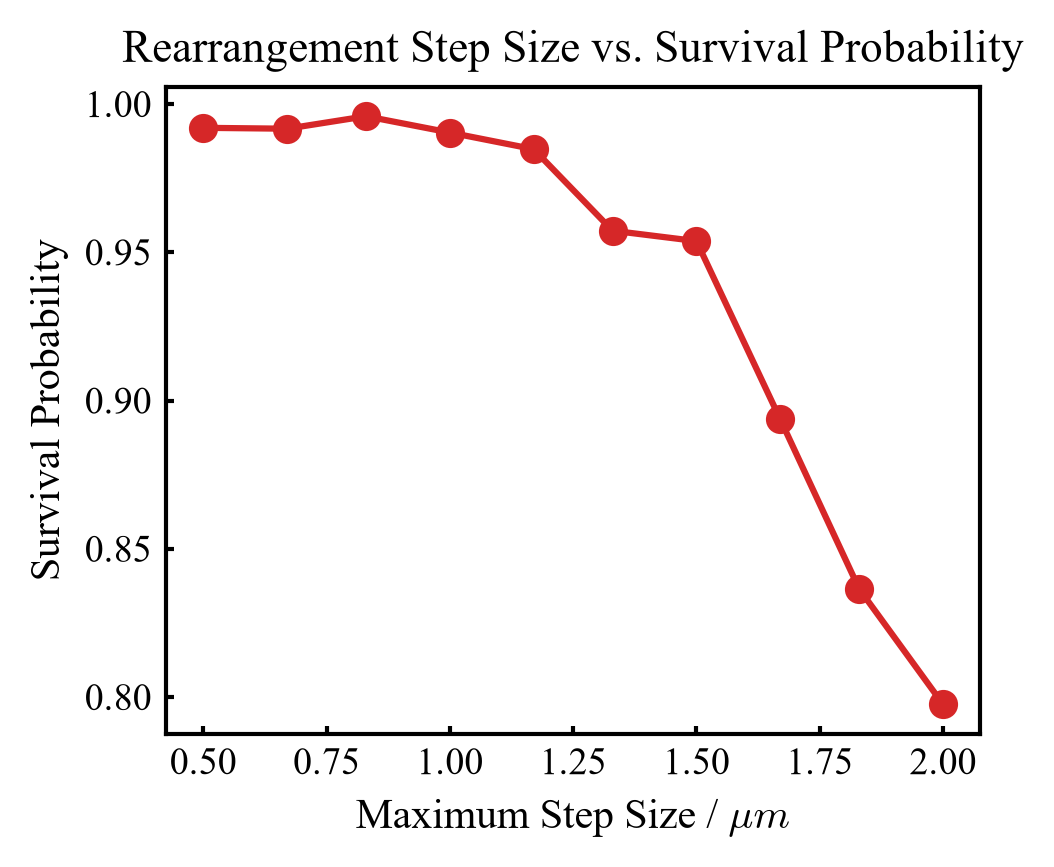

In [319]:
d0 = np.array([
    0.50, 0.67, 0.83, 1.00, 1.17, 
    1.33, 1.50, 1.67, 1.83, 2.00
])

filling_fraction = np.array([
    0.9619, 0.9616, 0.9657, 0.9604, 0.9550, 
    0.9283, 0.9249, 0.8666, 0.8111, 0.7735
])

rearrangement_efficiency = np.array([
    0.9920, 0.9917, 0.9959, 0.9904, 0.9848, 
    0.9573, 0.9538, 0.8937, 0.8365, 0.7976
])

plt.figure(figsize=(3.5, 2.8))
plt.plot(d0, rearrangement_efficiency, color='C3', marker='o')
plt.xlabel("Maximum Step Size / $\mu m$")
plt.ylabel("Survival Probability")
plt.title("Rearrangement Step Size vs. Survival Probability")

plt.savefig("Images\\step_size.png", bbox_inches='tight')

In [269]:
dx, dy = 8.0, 12.0
PM = pm.OptimisationBasedPhasemaskGeneratorGPU(
                 wavelength_um=0.852,
                 focal_length_mm=17.3,
                 slm_pitch_um=17,
                 slm_res=(1024,1024),
                 input_beam_waist_mm=16,
                 fresnel_f_mm=1072,
                 blaze_dx_dy_um=(40+dx, -8+dy),
                 zernike_coeff_dict={5:1.195, 6:0.725, 7:0.970, 8:0.478, 9:-1.091, 10:0.303, 11:0.021, 12:0.072, 13:0.049})

gauss2d = lambda x, y, A, x0, y0, sx, sy, offset: (A * np.exp(-(((x - x0) ** 2) / (2 * sx ** 2) + ((y - y0) ** 2) / (2 * sy ** 2)))) + offset
A, x0, y0, sx, sy, offset = [-2.14197604e+03, -1.11443850e+01 - dx, 2.09919600e+00 - dy, 2.95002910e+03, 2.64281503e+03, 2.14239505e+03]

--- System Configuration ---
SLM Plane Width: 17.41 mm
SLM Plane Height: 17.41 mm
Focal Plane Resolution x (pixel size): 0.8467 um
Focal Plane Resolution y (pixel size): 0.8467 um
Focal Plane Width: 867.04 um
Focal Plane Height: 867.04 um
Fresnel Lens Focal Length: 1072.00 mm
Blazed Grating Displacement (dx, dy): (48.0, 4.0) um


In [ ]:
W1 = np.ones((12,12))
spacing_um = 5.0

w_n, theta_n, x_n, y_n, array_shape = PM.generate_weighted_array(W1, spacing_um, init_phase_randomness=1.0, angle_deg=2.5)
w_n = (W1 * gauss2d(x_n.reshape(array_shape), y_n.reshape(array_shape), A, x0, y0, sx, sy, offset)).flatten()

terms1 = [w_n, theta_n, x_n, y_n, array_shape]
pm_array1, terms1, _ = PM.superposition_optimization(terms1, max_iter=2000, damping=0.5, verbose=True)

In [ ]:
n_traps = 100000
n_it = 10
taus = []
for _ in range(n_it):
    terms = [np.random.uniform(0, 1, n_traps), np.random.uniform(-np.pi, np.pi, n_traps), np.random.uniform(-(np.sqrt(n_traps)-1)*5.0/2, (np.sqrt(n_traps)-1)*5.0/2, n_traps), np.random.uniform(-(np.sqrt(n_traps)-1)*5.0/2, (np.sqrt(n_traps)-1)*5.0/2, n_traps)]
    t0 = time.perf_counter()
    out = PM.generate_phasemask(terms)
    t1 = time.perf_counter()
    tau = t1 - t0
    taus.append(tau)
mean_tau = np.mean(taus) * 1000
print(f"Time taken: {mean_tau:.4f} ms")

Time taken: 0.4278 ms


In [274]:
N_traps = np.geomspace(10, 1E5, 100).astype('i')
n_it = 1000
times = []
for n_traps in N_traps:
    taus = []
    for _ in range(n_it):
        terms = [np.random.uniform(0, 1, n_traps), np.random.uniform(-np.pi, np.pi, n_traps), np.random.uniform(-(np.sqrt(n_traps)-1)*5.0/2, (np.sqrt(n_traps)-1)*5.0/2, n_traps), np.random.uniform(-(np.sqrt(n_traps)-1)*5.0/2, (np.sqrt(n_traps)-1)*5.0/2, n_traps)]
        t0 = time.perf_counter()
        out = PM.generate_phasemask(terms)
        t1 = time.perf_counter()
        tau = t1 - t0
        taus.append(tau)
    mean_tau = np.mean(taus) * 1000
    times.append(mean_tau)
    print(f"No. traps: {n_traps} | Time: {mean_tau:.4f} ms")

No. traps: 10 | Time: 0.1993 ms
No. traps: 10 | Time: 0.1860 ms
No. traps: 12 | Time: 0.1964 ms
No. traps: 13 | Time: 0.2047 ms
No. traps: 14 | Time: 0.1884 ms
No. traps: 15 | Time: 0.1863 ms
No. traps: 17 | Time: 0.1915 ms
No. traps: 19 | Time: 0.1842 ms
No. traps: 21 | Time: 0.1850 ms
No. traps: 23 | Time: 0.1857 ms
No. traps: 25 | Time: 0.1862 ms
No. traps: 27 | Time: 0.1859 ms
No. traps: 30 | Time: 0.1844 ms
No. traps: 33 | Time: 0.1888 ms
No. traps: 36 | Time: 0.1890 ms
No. traps: 40 | Time: 0.1878 ms
No. traps: 44 | Time: 0.1890 ms
No. traps: 48 | Time: 0.1908 ms
No. traps: 53 | Time: 0.1850 ms
No. traps: 58 | Time: 0.1896 ms
No. traps: 64 | Time: 0.1864 ms
No. traps: 70 | Time: 0.1857 ms
No. traps: 77 | Time: 0.1899 ms
No. traps: 84 | Time: 0.1835 ms
No. traps: 93 | Time: 0.1902 ms
No. traps: 102 | Time: 0.1855 ms
No. traps: 112 | Time: 0.1847 ms
No. traps: 123 | Time: 0.1815 ms
No. traps: 135 | Time: 0.1832 ms
No. traps: 148 | Time: 0.1818 ms
No. traps: 162 | Time: 0.1807 ms
No

In [287]:
crit_trap = N_traps[np.argmin(np.abs((np.array(times) - 0.705)))]
crit_trap

np.int32(2205)

C:\Users\tweez\AppData\Local\Temp\ipykernel_29156\164381280.py:17: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 40)


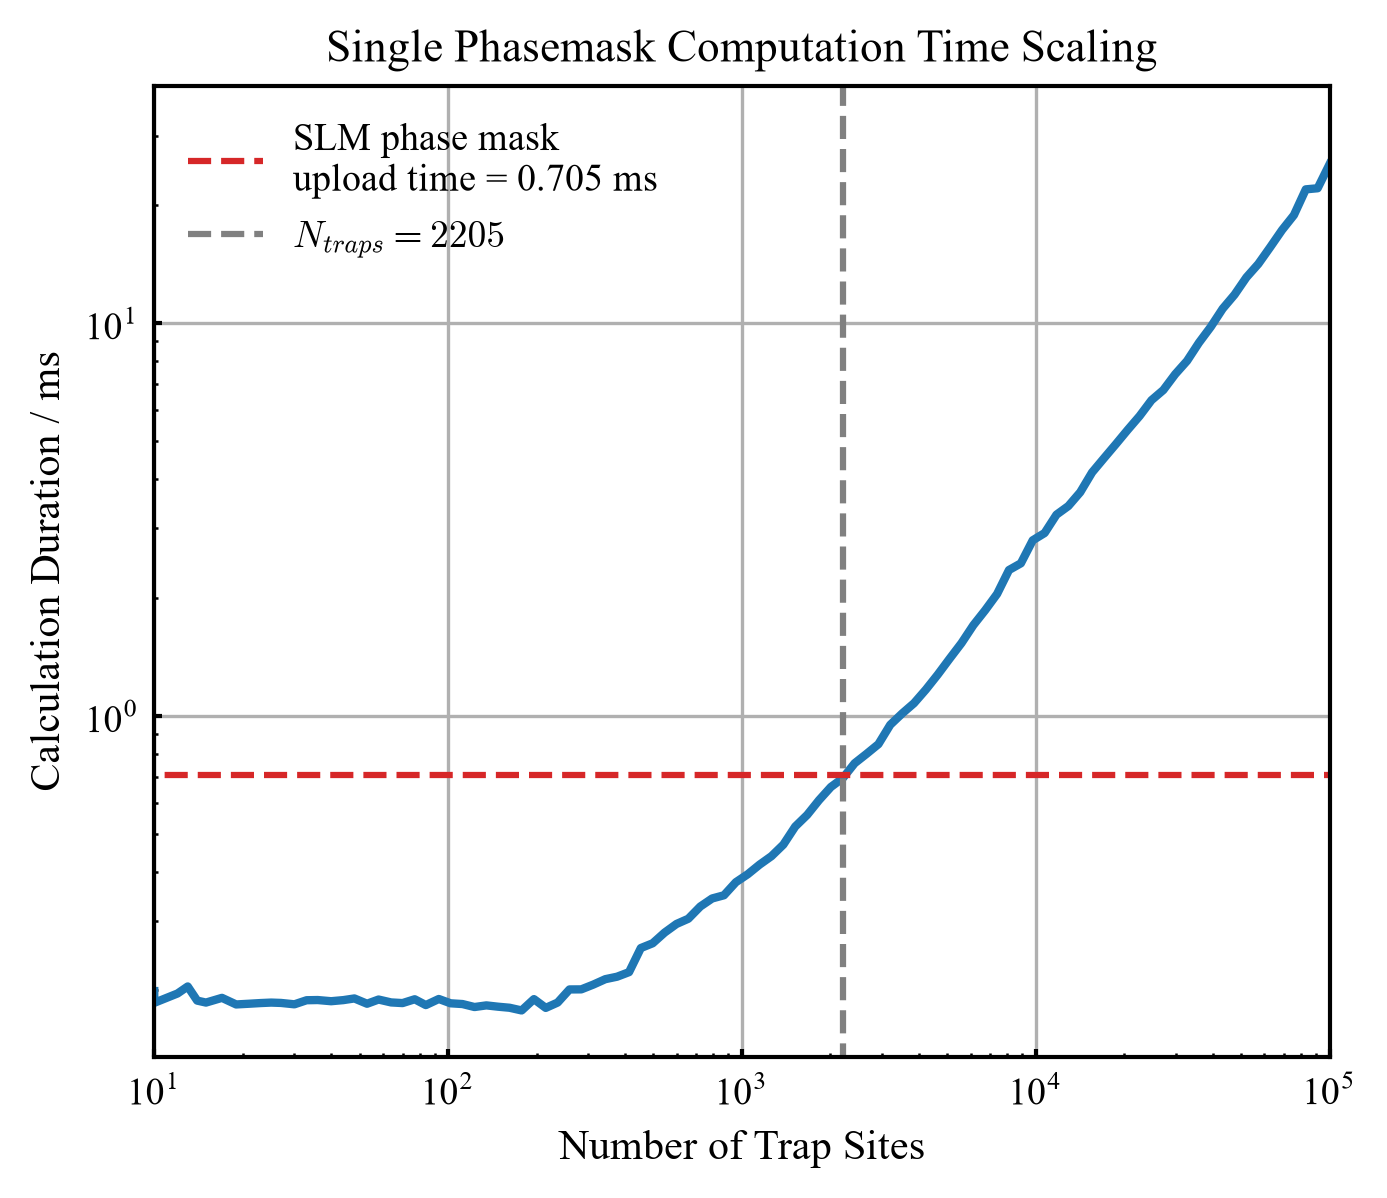

In [304]:
fig, ax = plt.subplots(figsize=(3.37*1.5, 2.8*1.5))
ax.plot(N_traps, times, color='C0', linewidth=2.0)
ax.set_xscale('log')
ax.set_yscale('log')
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=5))
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=50))
ax.xaxis.set_minor_formatter(NullFormatter()) # Hides minor tick text

# Format axes
ax.set_xlabel("Number of Trap Sites")
ax.set_ylabel("Calculation Duration / ms")
ax.set_title('Single Phasemask Computation Time Scaling')

ax.hlines([0.705], 0, 2E5, linestyle='--', color='C3', label="SLM phase mask\nupload time = 0.705 ms")
ax.vlines([2205], 0, 40, linestyle='--', color='gray', label="$N_{{traps}} = 2205$")
ax.set_xlim(10, 1E5)
ax.set_ylim(0, 40)
ax.grid()
ax.legend()

plt.savefig("Images\\single_phasemask_calc_scaling.png", bbox_inches='tight')

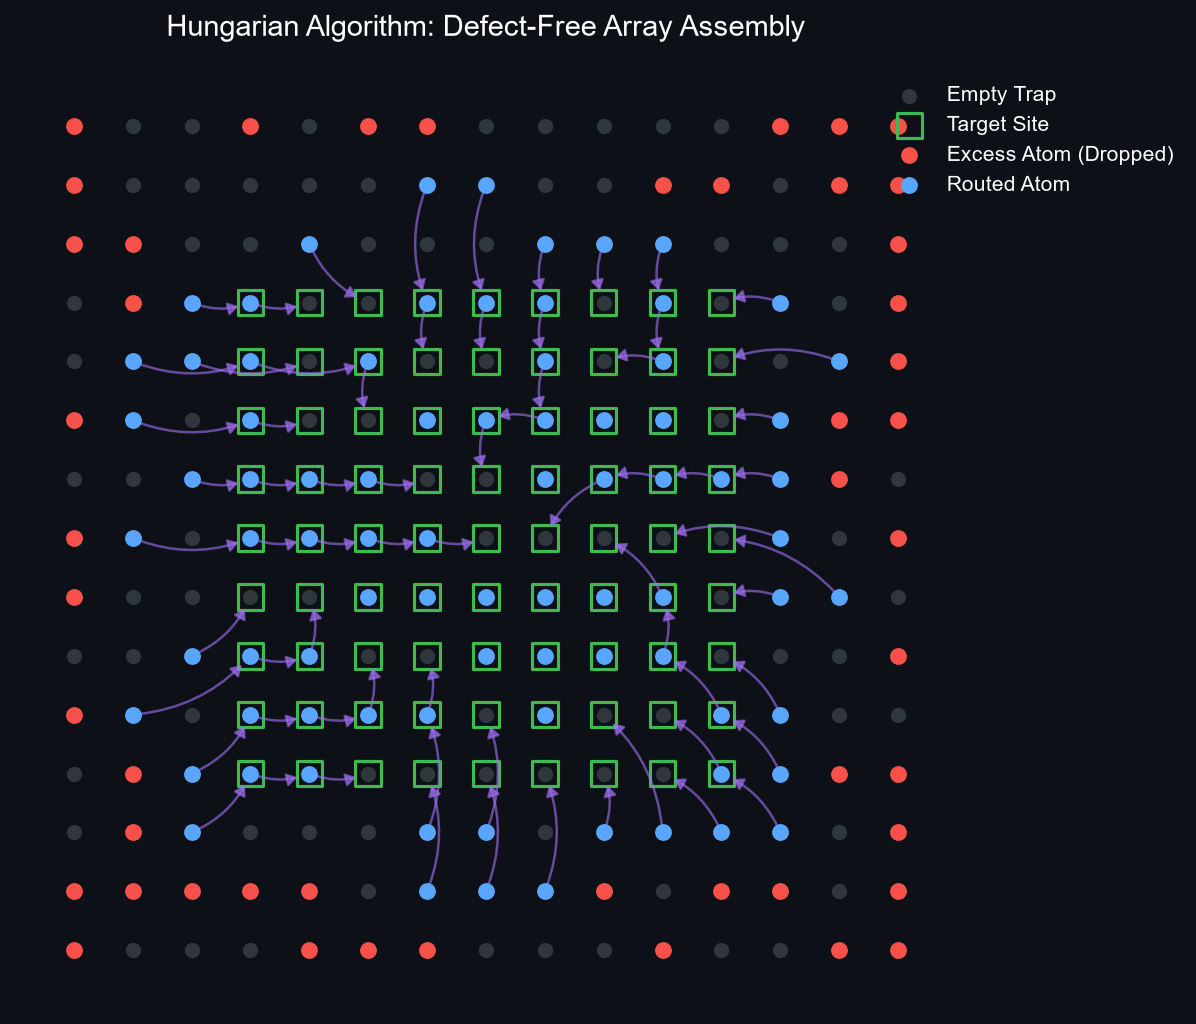

In [364]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

# ==============================================================================
# 1. STYLE SETTINGS (Dark Mode Quantum Aesthetic)
# ==============================================================================
plt.style.use('dark_background')
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "figure.facecolor": "#0d1117", # Deep space GitHub dark
    "axes.facecolor": "#0d1117",
    "axes.edgecolor": "#30363d",
    "grid.color": "#21262d",
})

# Colors
COLOR_EMPTY = "#30363d"      # Faint grey for empty tweezers
COLOR_ATOM = "#58a6ff"       # Neon blue for loaded atoms
COLOR_TARGET = "#3fb950"     # Neon green for target sites
COLOR_DROPPED = "#f85149"    # Red for excess atoms that get dumped
COLOR_PATH = "#a371f7"       # Purple for the Hungarian routing paths

# ==============================================================================
# 2. GENERATE THE HARDWARE ARRAY & STOCHASTIC LOADING
# ==============================================================================
np.random.seed(42) # Fixed seed for reproducible "cool" pattern

# Create a 15x15 master tweezer array
grid_size = 15
x, y = np.meshgrid(np.arange(grid_size), np.arange(grid_size))
all_traps = np.column_stack([x.ravel(), y.ravel()])

# Simulate ~55% stochastic loading
fill_probability = 0.55
is_loaded = np.random.rand(len(all_traps)) < fill_probability
initial_atoms = all_traps[is_loaded]

# ==============================================================================
# 3. DEFINE THE TARGET GEOMETRY
# ==============================================================================
# Let's define a dense 9x9 square target array in the center
target_mask = (all_traps[:, 0] >= 3) & (all_traps[:, 0] <= 11) & \
              (all_traps[:, 1] >= 3) & (all_traps[:, 1] <= 11)
target_sites = all_traps[target_mask]

# Ensure we have enough atoms to fill the target!
if len(initial_atoms) < len(target_sites):
    raise ValueError("Not enough atoms loaded to fill the target array!")

# ==============================================================================
# 4. THE HUNGARIAN ALGORITHM
# ==============================================================================
# Calculate the cost matrix. 
# We use Squared Euclidean distance (L2^2) because in physics, minimizing the 
# squared distance aggressively penalizes long-distance moves, preventing atom loss.
cost_matrix = cdist(initial_atoms, target_sites, metric='sqeuclidean')

# Run the Jonker-Volgenant / Hungarian algorithm
# row_ind: indices of the initial atoms that will move
# col_ind: indices of the target sites they will move to
row_ind, col_ind = linear_sum_assignment(cost_matrix)

# Separate the atoms into "Movers" and "Excess (Dropped)"
moving_atoms = initial_atoms[row_ind]
target_destinations = target_sites[col_ind]

# Any atom not in row_ind is excess and will be turned off
excess_mask = np.ones(len(initial_atoms), dtype=bool)
excess_mask[row_ind] = False
excess_atoms = initial_atoms[excess_mask]

# ==============================================================================
# 5. RENDER THE VISUALIZATION
# ==============================================================================
fig, ax = plt.subplots(figsize=(8, 8), dpi=150)

# 1. Plot background array (Empty tweezers)
ax.scatter(all_traps[:, 0], all_traps[:, 1], s=40, color=COLOR_EMPTY, marker='o', label="Empty Trap")

# 2. Plot target geometry (Hollow glowing squares)
ax.scatter(target_sites[:, 0], target_sites[:, 1], s=150, facecolors='none', 
           edgecolors=COLOR_TARGET, linewidth=1.5, marker='s', label="Target Site")

# 3. Plot excess atoms (Will be dropped)
ax.scatter(excess_atoms[:, 0], excess_atoms[:, 1], s=50, color=COLOR_DROPPED, 
           zorder=3, label="Excess Atom (Dropped)")

# 4. Draw the Hungarian optimal routing paths
# We use curved arrows (arc3) so paths don't perfectly overlap, creating a fluid network look
for i in range(len(moving_atoms)):
    start = moving_atoms[i]
    end = target_destinations[i]
    
    # If the atom is already in its target site, don't draw an arrow
    if np.array_equal(start, end):
        continue
        
    arrow = FancyArrowPatch(
        posA=start, posB=end,
        connectionstyle="arc3,rad=0.2", # Curve the arrows
        color=COLOR_PATH,
        alpha=0.6,
        linewidth=1.2,
        arrowstyle="-|>,head_length=4,head_width=2.5",
        zorder=2,
        shrinkA=3, shrinkB=6 # Leave a gap before hitting the target
    )
    ax.add_patch(arrow)

# 5. Plot moving atoms on top of the paths
ax.scatter(moving_atoms[:, 0], moving_atoms[:, 1], s=50, color=COLOR_ATOM, 
           zorder=4, label="Routed Atom")

# ==============================================================================
# 6. FORMATTING
# ==============================================================================
ax.set_title("Hungarian Algorithm: Defect-Free Array Assembly", fontsize=14, pad=15, color="white")
ax.set_aspect('equal')
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.3)
ax.set_xlim(-1, grid_size)
ax.set_ylim(-1, grid_size)
ax.axis('off') # Hide axes for a clean "floating" look

# Custom legend
leg = ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1), frameon=False, fontsize=10, labelcolor="white")

plt.tight_layout()
plt.savefig("hungarian_rearrangement.png", bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()